In [1]:
# --- Project root setup (run first) ---
from pathlib import Path
import os, sys # noqa

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "requirements.txt").exists():
    project_root = project_root.parent

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root = {project_root}")

Project root = C:\Users\aurel\Desktop\M2\Stage ecoseas-csm\CSM\bcw-paper-2025


## Setup

Project root detection, imports, and global display/style settings.

### Imports and Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import sys
import json
import warnings

from colorama import Fore, Style
from matplotlib.ticker import LogLocator, ScalarFormatter
from matplotlib.colors import ListedColormap, to_hex
from adjustText import adjust_text

from src.utils import ratio_computer
from src.config import (
    CMOL, ISO_MAP1, CONTINENT_MAP1, ISO_OVERRIDES1, DATA_DIR,
    OUTPUT_DIR, SUMMARY_DIR, WLD_SHP, USA_SPLIT_CSV, EEZ_SHP,
    MAPPING_JSON,
)
from src.visualization import (
    complete_iso_and_continent, pretty_report, blue_carbon_report,
    build_world_geodataframe, build_country_data,
    format_log_axis_plain, categorize_bcw_pcap,
    circle_area_plot, regplotter, regplotter_log_axes, # noqa
    mapper_bc, map_and_barplot, wind_rose, stats_for_group,
    plot_eez_choropleth, 
    CONTINENT_PAL, BCE_COLORMAP, BCP_COLORMAP, GROUPS_COLORMAP,
    MAP_FIN, 
)

In [3]:
warnings.filterwarnings("ignore")
pd.set_option('display.float_format', '{:,.4f}'.format)
pd.options.display.max_rows = 500
pd.options.display.max_columns = 40
sns.set_style("whitegrid")

blueprint  = Fore.BLUE
redprint   = Fore.RED
greenprint = Fore.GREEN
reset      = Style.RESET_ALL


## Data Loading

Load the GSCC distribution draws, the main BCW country-level dataset, and the world boundaries shapefile.

### GSCC Distribution

In [4]:
npz = np.load(OUTPUT_DIR / "draws.npz", allow_pickle=True)
print(npz.files)

['country_name', 'ISO', 'gscc_draws', 'bcw_draws', 'bce_saltmarshes_draws', 'bce_seagrasses_draws', 'bce_mangroves_draws', 'bce_total_draws', 'bce_rates_draws']


In [5]:
gscc_dist = npz['gscc_draws']
gscc_value = np.mean(gscc_dist) if len(gscc_dist) > 0 else np.nan

print(f"{greenprint}Global Social Cost of Carbon (GSCC): {gscc_value:.2f} US$/tCO2{reset}")

Global Social Cost of Carbon (GSCC): 559.57 US$/tCO2


In [6]:
mapping = json.load(open(MAPPING_JSON, encoding='utf8'))

### unadjusted BCW Dataset for plots

In [7]:
bcw = pd.read_csv(SUMMARY_DIR / 'unadjusted_bcw_data.csv')
bcw.head()

,country_name,TERRITORY1,ISO,SOVEREIGN1,Continent,Groups,Population,Area_EEZ_KM2,GDP,CO2_emissions_2023,Debt (2015 US$),saltmarshes_area_km2,seagrasses_area_km2,mangroves_area_km2,uptake_salt_mean,uptake_salt_se,uptake_seag_mean,uptake_seag_se,uptake_mang_mean,uptake_mang_se,uptake_total_mean,uptake_total_se,BCP Seq (tC),cBCW,cBCW_se,oBCW,oBCW_se,Total BCseq,Total BCseq_se,Total BCW,Total BCW_se,Area_EEZ_KM2_per_capita,GDP_per_capita,CO2_emissions_2023_per_capita,Debt (2015 US$)_per_capita,Total BCW_per_capita
0,"Abu musa, Greater and Lesser Tunb","Abu musa, Greater and Lesser Tunb",NaN,United Arab Emirates,NaN,NaN,NaN,"6,199.3060",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,Afghanistan,AFG,Afghanistan,Asia,LDCs,"41,454,761.0000","641,860.3931","15,325,233,810.1388","11,020,218.0000","2,588,228,316.5025",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0155,369.6857,0.2658,62.4350,NaN
2,Alaska,Alaska,NaN,United States,NaN,NaN,NaN,"5,193,058.2890",NaN,NaN,NaN,"1,620.9524",150.5065,NaN,"272,320.0000",0.0000,"32,925.2109",208.3725,NaN,NaN,"305,245.2500",208.3725,NaN,"626,366,528.0000","2,179,778.5556",NaN,NaN,"305,245.2500",208.3725,"626,366,528.0000","2,179,778.5556",NaN,NaN,NaN,NaN,NaN
3,Albania,Albania,ALB,Albania,Europe,Developed economies,"2,811,655.0000","40,953.5448","14,812,273,860.7720","5,144,279.0000","8,579,785,823.0375",46.5780,44.0193,NaN,"7,825.1090",0.0000,"9,629.7744",60.9436,NaN,NaN,"17,454.8828",60.9436,"77,900.0000","35,835,124.0000","183,495.8601","159,832,690.0000","542,488.9824","95,354.8828",60.9436,"195,667,792.0000","678,937.5363",0.0146,"5,268.1691",1.8296,"3,051.5073",69.5917
4,Algeria,Algeria,DZA,Algeria,Africa,Developing economies,"46,164,219.0000","2,444,283.5600","215,143,978,140.2140","178,132,770.0000","5,523,025,799.7245",NaN,40.4832,NaN,NaN,NaN,"8,856.2158",56.0480,NaN,NaN,"8,856.2158",56.0480,"3,000,000.0000","18,190,912.0000","140,324.9332","6,155,302,400.0000","20,891,743.4064","3,008,856.0000",56.0480,"6,173,492,736.0000","20,954,733.3811",0.0529,"4,660.4055",3.8587,119.6387,133.7290


### Data Quality Check

In [8]:
# Cleaning checks
print("Duplicates: ", bcw.duplicated().sum())
print("\nMissing data:")
bcw.isna().sum()

Duplicates:  0

Missing data:


country_name                       0
TERRITORY1                         3
ISO                               36
SOVEREIGN1                         3
Continent                         38
Groups                            38
Population                        59
Area_EEZ_KM2                       0
GDP                               92
CO2_emissions_2023                80
Debt (2015 US$)                  177
saltmarshes_area_km2             246
seagrasses_area_km2              165
mangroves_area_km2               172
uptake_salt_mean                 246
uptake_salt_se                   246
uptake_seag_mean                 165
uptake_seag_se                   165
uptake_mang_mean                 172
uptake_mang_se                   172
uptake_total_mean                116
uptake_total_se                  116
BCP Seq (tC)                     169
cBCW                             116
cBCW_se                          116
oBCW                             169
oBCW_se                          169
T

## Palettes and Color Mappings

Color palettes used throughout the notebook for continents, economic groups, and choropleth maps.

In [9]:
pal        = CONTINENT_PAL
color_map2 = BCE_COLORMAP
color_map3 = BCP_COLORMAP


## Data Preparation

Complete missing ISO codes and continent assignments. Compute derived per-capita and ratio columns.

### ISO and Continent Completion for map visualization

In [10]:
plot_data = complete_iso_and_continent(
    bcw,
    iso_map=ISO_MAP1,
    continent_map=CONTINENT_MAP1,
    overrides=ISO_OVERRIDES1,
)
plot_data.head(3)

,country_name,TERRITORY1,ISO,SOVEREIGN1,Continent,Groups,Population,Area_EEZ_KM2,GDP,CO2_emissions_2023,Debt (2015 US$),saltmarshes_area_km2,seagrasses_area_km2,mangroves_area_km2,uptake_salt_mean,uptake_salt_se,uptake_seag_mean,uptake_seag_se,uptake_mang_mean,uptake_mang_se,uptake_total_mean,uptake_total_se,BCP Seq (tC),cBCW,cBCW_se,oBCW,oBCW_se,Total BCseq,Total BCseq_se,Total BCW,Total BCW_se,Area_EEZ_KM2_per_capita,GDP_per_capita,CO2_emissions_2023_per_capita,Debt (2015 US$)_per_capita,Total BCW_per_capita
0,"Abu musa, Greater and Lesser Tunb","Abu musa, Greater and Lesser Tunb",NaN,United Arab Emirates,Asia,NaN,NaN,"6,199.3060",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,Afghanistan,AFG,Afghanistan,Asia,LDCs,"41,454,761.0000","641,860.3931","15,325,233,810.1388","11,020,218.0000","2,588,228,316.5025",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0155,369.6857,0.2658,62.4350,NaN
2,Alaska,Alaska,NaN,United States,Americas,NaN,NaN,"5,193,058.2890",NaN,NaN,NaN,"1,620.9524",150.5065,NaN,"272,320.0000",0.0000,"32,925.2109",208.3725,NaN,NaN,"305,245.2500",208.3725,NaN,"626,366,528.0000","2,179,778.5556",NaN,NaN,"305,245.2500",208.3725,"626,366,528.0000","2,179,778.5556",NaN,NaN,NaN,NaN,NaN


### (Adjusted) Data for BCW analysis

In [11]:
data = pd.read_csv(OUTPUT_DIR / 'country_level_bcw.csv')
data.head()

,country_name,TERRITORY1,ISO,SOVEREIGN1,Continent,Groups,Population,Area_EEZ_KM2,GDP,CO2_emissions_2023,Debt (2015 US$),saltmarshes_area_km2,seagrasses_area_km2,mangroves_area_km2,uptake_salt_mean,uptake_salt_se,uptake_seag_mean,uptake_seag_se,uptake_mang_mean,uptake_mang_se,uptake_total_mean,uptake_total_se,BCP Seq (tC),cBCW,cBCW_se,oBCW,oBCW_se,Total BCseq,Total BCseq_se,Total BCW,Total BCW_se,Area_EEZ_KM2_per_capita,GDP_per_capita,CO2_emissions_2023_per_capita,Debt (2015 US$)_per_capita,Total BCW_per_capita
0,"Abu musa, Greater and Lesser Tunb","Abu musa, Greater and Lesser Tunb",AE,United Arab Emirates,Asia,NaN,NaN,"6,199.3060",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,Afghanistan,AFG,Afghanistan,Asia,LDCs,"41,454,761.0000","641,860.3931","15,325,233,810.1388","11,020,218.0000","2,588,228,316.5025",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0155,369.6857,0.2658,62.4350,NaN
2,Alaska,Alaska,US-AK,United States,Americas,NaN,NaN,"5,193,058.2890",NaN,NaN,NaN,"1,620.9524",150.5065,NaN,"272,320.0000",0.0000,"32,925.2109",208.3725,NaN,NaN,"305,245.2500",208.3725,NaN,"626,366,528.0000","2,179,778.5556",NaN,NaN,"305,245.2500",208.3725,"626,366,528.0000","2,179,778.5556",NaN,NaN,NaN,NaN,NaN
3,Albania,Albania,ALB,Albania,Europe,Developed economies,"2,811,655.0000","40,953.5448","14,812,273,860.7720","5,144,279.0000","8,579,785,823.0375",46.5780,44.0193,NaN,"7,825.1090",0.0000,"9,629.7744",60.9436,NaN,NaN,"17,454.8828",60.9436,"77,900.0000","35,835,124.0000","183,495.8601","159,832,690.0000","542,488.9824","95,354.8828",60.9436,"195,667,792.0000","678,937.5363",0.0146,"5,268.1691",1.8296,"3,051.5073",69.5917
4,Algeria,Algeria,DZA,Algeria,Africa,Developing economies,"46,164,219.0000","2,444,283.5600","215,143,978,140.2140","178,132,770.0000","5,523,025,799.7245",NaN,40.4832,NaN,NaN,NaN,"8,856.2158",56.0480,NaN,NaN,"8,856.2158",56.0480,"3,000,000.0000","18,190,912.0000","140,324.9332","6,155,302,400.0000","20,891,743.4064","3,008,856.0000",56.0480,"6,173,492,736.0000","20,954,733.3811",0.0529,"4,660.4055",3.8587,119.6387,133.7290


In [12]:
data['Groups'].value_counts().sort_values(ascending=False)

Groups
Developing economies    94
Developed economies     69
SIDS                    58
LDCs                    37
Name: count, dtype: int64

## Descriptive Statistics

Basic summaries of the environmental, uptake, value, and sequestration dimensions.

### Environment (EEZ, Population, CO₂)

In [13]:
display(data.describe())
print("\nAverage population by group:")
data.groupby('Groups')['Population'].mean().round(2)

,Population,Area_EEZ_KM2,GDP,CO2_emissions_2023,Debt (2015 US$),saltmarshes_area_km2,seagrasses_area_km2,mangroves_area_km2,uptake_salt_mean,uptake_salt_se,uptake_seag_mean,uptake_seag_se,uptake_mang_mean,uptake_mang_se,uptake_total_mean,uptake_total_se,BCP Seq (tC),cBCW,cBCW_se,oBCW,oBCW_se,Total BCseq,Total BCseq_se,Total BCW,Total BCW_se,Area_EEZ_KM2_per_capita,GDP_per_capita,CO2_emissions_2023_per_capita,Debt (2015 US$)_per_capita,Total BCW_per_capita
count,237.0000,296.0000,204.0000,216.0000,119.0000,50.0000,131.0000,124.0000,50.0000,50.0000,131.0000,131.0000,124.0000,124.0000,180.0000,180.0000,127.0000,180.0000,180.0000,127.0000,127.0000,190.0000,190.0000,190.0000,190.0000,237.0000,204.0000,215.0000,119.0000,177.0000
mean,"34,185,079.1392","972,263.1533","449,077,585,521.1537","169,950,743.7190","56,055,372,346.9629","1,090.8937","2,845.6177",902.2520,"183,270.1386",0.0001,"622,515.2127","3,939.6875","167,156.9051","1,466.2653","619,113.6556","3,451.0631","8,009,065.6542","1,270,124,772.1342","8,940,570.7072","16,432,739,333.4760","55,774,451.5005","5,939,956.7799","3,269.4285","12,187,264,833.1658","44,064,532.9926",4.5107,"17,238.7566",4.5260,"1,933.0831","23,238.5828"
std,"136,962,527.7345","2,411,770.6146","2,013,857,049,467.3083","910,476,014.5910","185,978,059,985.3255","3,203.6851","8,426.7031","2,008.2093","538,219.0733",0.0003,"1,843,448.9021","11,666.5625","372,053.5262","3,263.5756","1,822,298.8507","10,343.6950","13,449,172.3380","3,740,790,052.0192","26,463,513.3708","27,594,572,894.6777","93,658,892.8108","12,198,910.1566","10,095.9421","25,029,200,952.8661","86,935,845.1264",20.2011,"25,400.8859",5.3342,"2,169.4106","94,682.6524"
min,496.0000,0.5662,"46,855,113.8353",0.0000,"148,322,391.4430",0.0012,0.0380,0.0103,0.2077,0.0000,8.3227,0.0527,1.9085,0.0167,0.2717,0.0000,0.0000,557.4694,1.8921,0.0000,0.0000,0.2717,0.0000,557.4694,1.8921,0.0002,253.5307,0.0304,57.5137,0.0071
25%,"387,558.0000","70,655.5972","6,865,038,890.6000","1,180,341.2500","2,568,255,658.8088",4.8828,66.0742,2.0068,820.3087,0.0000,"14,454.5806",91.4781,371.7877,3.2612,"9,275.5110",31.0431,"587,889.5000","18,959,916.0000","141,875.3640","1,206,212,450.0000","4,094,012.3508","51,016.9980",11.0753,"104,754,848.0000","729,356.5434",0.0137,"2,324.6676",0.8909,352.1744,58.6256
50%,"5,518,055.0000","342,118.2368","27,993,532,940.7241","10,026,816.0000","9,679,534,332.2475",56.2734,548.7794,71.4030,"9,453.9265",0.0000,"120,052.4922",759.7715,"13,228.5760",116.0383,"109,988.3789",599.3739,"2,600,795.0000","225,697,232.0000","1,619,614.7917","5,336,227,000.0000","18,111,715.3825","1,016,823.0000",457.1089,"2,086,368,128.0000","9,867,517.8608",0.0451,"6,539.9533",3.2590,"1,079.6419",480.9253
75%,"23,025,776.0000","818,653.0601","215,424,961,024.5606","57,012,591.5000","32,711,132,646.3883",298.9310,"1,763.7976",613.4431,"50,220.4210",0.0000,"385,853.2656","2,441.9342","113,650.3475",996.9170,"377,220.8203","2,400.0636","10,288,126.0000","774,377,424.0000","6,438,781.7325","21,108,841,500.0000","71,645,633.5120","5,326,514.0000","2,154.9267","10,920,756,224.0000","49,874,713.6651",0.2453,"21,006.9140",5.6081,"2,811.5011","2,714.5092"
max,"1,438,069,596.0000","24,610,608.9200","21,776,284,673,936.1992","11,902,503,000.0000","1,827,259,180,805.1423","17,161.8447","79,757.0000","11,375.5504","2,883,189.8000",0.0018,"17,447,862.0000","110,421.5973","2,107,506.2000","18,486.6042","17,725,378.0000","110,443.4279","79,645,600.0000","36,404,948,992.0000","277,407,132.8220","163,414,250,000.0000","554,645,204.3544","82,954,896.0000","110,443.4216","170,199,777,280.0000","577,686,525.7954",175.2379,"214,069.4869",38.8414,"11,413.0438","686,217.7382"



Average population by group:


Groups
Developed economies    23,191,126.3100
Developing economies   66,733,570.7500
LDCs                   30,915,051.7000
SIDS                    1,283,504.6700
Name: Population, dtype: float64

In [14]:
countr = data[[
    'Population', 'Area_EEZ_KM2', 'Area_EEZ_KM2_per_capita', 
    'CO2_emissions_2023', 'CO2_emissions_2023_per_capita'
    ]].copy()
countr.describe()

,Population,Area_EEZ_KM2,Area_EEZ_KM2_per_capita,CO2_emissions_2023,CO2_emissions_2023_per_capita
count,237.0000,296.0000,237.0000,216.0000,215.0000
mean,"34,185,079.1392","972,263.1533",4.5107,"169,950,743.7190",4.5260
std,"136,962,527.7345","2,411,770.6146",20.2011,"910,476,014.5910",5.3342
min,496.0000,0.5662,0.0002,0.0000,0.0304
25%,"387,558.0000","70,655.5972",0.0137,"1,180,341.2500",0.8909
50%,"5,518,055.0000","342,118.2368",0.0451,"10,026,816.0000",3.2590
75%,"23,025,776.0000","818,653.0601",0.2453,"57,012,591.5000",5.6081
max,"1,438,069,596.0000","24,610,608.9200",175.2379,"11,902,503,000.0000",38.8414


### BCE Areas and Uptakes

In [15]:
uptakes = data[[
    "uptake_salt_mean", "uptake_seag_mean", "uptake_mang_mean",
    "uptake_total_mean", "BCP Seq (tC)", "Total BCseq",
]].copy()
uptakes.rename(columns={
    'uptake_total_mean': 'BCE Seq (tC)'}, inplace=True)
uptakes.describe()

,uptake_salt_mean,uptake_seag_mean,uptake_mang_mean,BCE Seq (tC),BCP Seq (tC),Total BCseq
count,50.0000,131.0000,124.0000,180.0000,127.0000,190.0000
mean,"183,270.1386","622,515.2127","167,156.9051","619,113.6556","8,009,065.6542","5,939,956.7799"
std,"538,219.0733","1,843,448.9021","372,053.5262","1,822,298.8507","13,449,172.3380","12,198,910.1566"
min,0.2077,8.3227,1.9085,0.2717,0.0000,0.2717
25%,820.3087,"14,454.5806",371.7877,"9,275.5110","587,889.5000","51,016.9980"
50%,"9,453.9265","120,052.4922","13,228.5760","109,988.3789","2,600,795.0000","1,016,823.0000"
75%,"50,220.4210","385,853.2656","113,650.3475","377,220.8203","10,288,126.0000","5,326,514.0000"
max,"2,883,189.8000","17,447,862.0000","2,107,506.2000","17,725,378.0000","79,645,600.0000","82,954,896.0000"


In [16]:
# supl1
uptakes = data[[
    "uptake_salt_mean", "uptake_seag_mean", "uptake_mang_mean",
    "uptake_total_mean", "BCP Seq (tC)", "Total BCseq", "Continent"
]].copy()

mg_up = (
    uptakes
    .groupby("Continent")
    .sum()
    .sort_values(by='Total BCseq', ascending=False)
    .reset_index()
)

# convert tC to MtC and GtC where appropriate, and rename columns for clarity
mg_up.iloc[:, 1:] = mg_up.iloc[:, 1:] / 1e6
mg_up.columns = [
    "Continent", "Saltmarshes (MtC)", "Seagrasses (MtC)", "Mangroves (MtC)",
    "Total BCEs (MtC)", "BCP (MtC)", "Total Seq (MtC)"
]

mg_up = mg_up.round(2)

save_path = SUMMARY_DIR / 'continental_uptakes.csv'
mg_up.to_csv(save_path, index=False)
mg_up

,Continent,Saltmarshes (MtC),Seagrasses (MtC),Mangroves (MtC),Total BCEs (MtC),BCP (MtC),Total Seq (MtC)
0,Americas,4.0600,5.9800,6.8400,16.8800,328.6100,345.4900
1,Europe,1.8500,3.3500,0.0000,5.2000,194.5400,199.7400
2,Oceania,2.2400,14.5900,3.0300,19.8600,176.8600,196.7200
3,Asia,0.9700,20.0000,5.2600,26.2300,153.5400,179.7700
4,Africa,0.0200,15.8300,5.1600,21.0200,157.5200,178.5400
5,Caribbean,0.0100,21.8000,0.4400,22.2500,6.0800,28.3300


In [17]:
total_bce_up = data['uptake_total_mean'].sum()
std_bce_up = np.std(data['uptake_total_mean'].dropna(), ddof=1)
se_bce_up = np.sqrt(np.sum(data['uptake_total_se'].dropna() ** 2))

median_bce_up = data['uptake_total_mean'].median()
mean_bce_up = data['uptake_total_mean'].mean()
print(f"""The total Blue Carbon Ecosystems (BCEs) sequestration is: {greenprint}{total_bce_up/1e6:.2f} ± {se_bce_up/1e6:.2f} MtC (std = {std_bce_up/1e6:.3f}){reset}""")
print(f"""The avg. BCEs sequestration is: {greenprint}{mean_bce_up/1e6:.2f} MtC{reset}, the median is: {greenprint}{median_bce_up/1e6:.2f} MtC{reset}""")

The total Blue Carbon Ecosystems (BCEs) sequestration is: 111.44 ± 0.15 MtC (std = 1.822)
The avg. BCEs sequestration is: 0.62 MtC, the median is: 0.11 MtC


In [18]:
# supl1
uptakes = data[[
    "uptake_salt_mean", "uptake_seag_mean", "uptake_mang_mean",
    "uptake_total_mean", "BCP Seq (tC)", "Total BCseq", "Groups"
]].copy()

mg_up = (
    uptakes
    .groupby('Groups')
    .sum()
    .sort_values(by='Total BCseq', ascending=False)
    .reset_index()
)

mg_up.iloc[:, 1:] = mg_up.iloc[:, 1:] / 1e6
mg_up.columns = [
    "Groups", "Saltmarshes (MtC)", "Seagrasses (MtC)", "Mangroves (MtC)",
    "Total BCEs (MtC)", "BCP (MtC)", "Total Seq MtC)"
]

mg_up = mg_up.round(2)
# mg_up['BCEs(%)'] = (mg_up['Total BCEs (MtC)'] / mg_up['Total BCEs (MtC)'].sum()).round(2) * 100
mg_up.to_csv(SUMMARY_DIR / 'grouping_uptakes.csv', index=False)
mg_up


,Groups,Saltmarshes (MtC),Seagrasses (MtC),Mangroves (MtC),Total BCEs (MtC),BCP (MtC),Total Seq MtC)
0,Developing economies,1.7000,26.4800,11.7700,39.9500,403.6400,443.5900
1,Developed economies,7.1700,12.6100,2.3400,22.1100,407.3400,429.4600
2,SIDS,0.0100,32.5300,2.3500,34.8900,146.3300,181.2200
3,LDCs,0.0100,8.9600,4.1600,13.1300,52.3200,65.4500


In [19]:
are = data[[
    'ISO', 'Groups', 'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
]].copy()
are['BCE Areas'] = are[[
    'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
]].sum(axis=1).round(2).replace(0, np.nan)
are.dropna(subset=['BCE Areas'], inplace=True)

are = are.groupby('Groups').agg(
    **{'BCE Areas (total)': ('BCE Areas', 'sum'),
       'Mean': ('BCE Areas', 'mean'),
       'Std': ('BCE Areas', 'std'),
       'Count': ('BCE Areas', 'count')}
).sort_values('BCE Areas (total)', ascending=False).reset_index()
are['SE (mean)'] = are['Std'] / np.sqrt(are['Count'])

are.columns = ['Groups', 'BCE Areas (total km²)', 'Mean Area (km²)', 'Std Area (km²)', 'N', 'SE (mean)']
are = are[[
    'Groups', 'N', 'BCE Areas (total km²)', 'Mean Area (km²)', 'SE (mean)', 'Std Area (km²)'
]]
are

,Groups,N,BCE Areas (total km²),Mean Area (km²),SE (mean),Std Area (km²)
0,Developing economies,59,"194,671.4300","3,299.5158",727.8690,"5,590.8678"
1,SIDS,54,"161,452.0900","2,989.8535","1,552.4877","11,408.4078"
2,Developed economies,37,"112,920.8700","3,051.9154","1,795.3294","10,920.5627"
3,LDCs,21,"63,457.3300","3,021.7776",846.2117,"3,877.8290"


In [20]:
are = data[[
    'ISO', 'Continent', 'saltmarshes_area_km2', 'seagrasses_area_km2', 
    'mangroves_area_km2', 'Area_EEZ_KM2'
]].copy()
are['BCE Areas'] = are[[
    'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
]].sum(axis=1).round(2).replace(0, np.nan)
are.dropna(subset=['BCE Areas'], inplace=True)

are = are.groupby('Continent').agg(
    **{
       'N': ('BCE Areas', 'count'),
       'BCE Areas (km²)': ('BCE Areas', 'sum'),
       'Mean BCE': ('BCE Areas', 'mean'),
       'Std BCE': ('BCE Areas', 'std'),
       'EEZ (km²)': ('Area_EEZ_KM2', 'sum'),
       'Avg. EEZ (km²)': ('Area_EEZ_KM2', 'mean')
       }
).sort_values('BCE Areas (km²)', ascending=False).reset_index()
are['SE (mean)'] = are['Std BCE'] / np.sqrt(are['N'])
are = are[[
    'Continent', 'N', 'BCE Areas (km²)', 'Mean BCE', 'SE (mean)', 'Std BCE', 'EEZ (km²)', 'Avg. EEZ (km²)'
]]
are['BCEs Areas by EEZ (%)'] = (are['BCE Areas (km²)'] / are['EEZ (km²)']) * 100
save_path = SUMMARY_DIR / 'continent_bce_areas_stats.csv'
are.to_csv(save_path, index=False)
are

,Continent,N,BCE Areas (km²),Mean BCE,SE (mean),Std BCE,EEZ (km²),Avg. EEZ (km²),BCEs Areas by EEZ (%)
0,Asia,34,"125,615.5700","3,694.5756",962.4717,"5,612.1263","45,958,440.8480","1,351,718.8485",0.2733
1,Caribbean,30,"102,095.0400","3,403.1680","2,723.5194","14,917.3301","3,210,387.3738","107,012.9125",3.1801
2,Africa,39,"100,379.6000","2,573.8359",730.5665,"4,562.3866","31,097,615.4143","797,374.7542",0.3228
3,Oceania,22,"96,372.5200","4,380.5691","2,917.4703","13,684.1488","48,101,849.0335","2,186,447.6833",0.2004
4,Americas,25,"88,427.3000","3,537.0920","1,179.5700","5,897.8499","65,631,941.5607","2,625,277.6624",0.1347
5,Europe,28,"26,307.6300",939.5582,361.3494,"1,912.0814","35,652,178.0362","1,273,292.0727",0.0738


In [21]:
dbt = data.copy()
dbt['uptake_rate'] = dbt['uptake_total_mean'] / dbt['uptake_total_mean'].sum() * 100

res = dbt.nlargest(100, 'uptake_total_mean')[['country_name', 'Groups', 'uptake_total_mean', 'uptake_rate']].rename(columns={
    'uptake_total_mean': 'Total BCE uptake (tC)',
    'uptake_rate': 'Pct. BCE uptake (%)'
})
res['rank'] = res['Total BCE uptake (tC)'].rank(ascending=False, method='min').astype(int)
res = res[['rank', 'country_name', 'Groups', 'Total BCE uptake (tC)', 'Pct. BCE uptake (%)']]
print("Top 15 countries by total BCE uptake:")
res.reset_index(drop=True).head(15)

Top 15 countries by total BCE uptake:


,rank,country_name,Groups,Total BCE uptake (tC),Pct. BCE uptake (%)
0,1,Bahamas,SIDS,"17,725,378.0000",15.9057
1,2,Australia,Developed economies,"13,058,535.0000",11.7179
2,3,Saudi Arabia,Developing economies,"4,603,089.0000",4.1305
3,4,Mexico,Developing economies,"4,428,818.0000",3.9742
4,5,Indonesia,Developing economies,"3,849,586.2500",3.4544
5,6,Guinea-Bissau,SIDS,"3,846,934.0000",3.4520
6,7,Philippines,Developing economies,"3,792,128.5000",3.4028
7,8,Nigeria,Developing economies,"3,486,373.5000",3.1285
8,9,United States,Developed economies,"3,309,292.0000",2.9696
9,10,Guinea,LDCs,"3,206,665.5000",2.8775


### BCW Values

In [22]:
data['cBCW_per_capita'] = data['cBCW'] / data['Population']
data['oBCW_per_capita'] = data['oBCW'] / data['Population']

In [23]:
values = data[['cBCW', 'cBCW_per_capita', 'oBCW', 'oBCW_per_capita', 'Total BCW', 'Total BCW_per_capita',
              'GDP', 'GDP_per_capita', 'Debt (2015 US$)', 'Debt (2015 US$)_per_capita']].copy()
values.describe()

,cBCW,cBCW_per_capita,oBCW,oBCW_per_capita,Total BCW,Total BCW_per_capita,GDP,GDP_per_capita,Debt (2015 US$),Debt (2015 US$)_per_capita
count,180.0000,168.0000,127.0000,126.0000,190.0000,177.0000,204.0000,204.0000,119.0000,119.0000
mean,"1,270,124,772.1342","1,197.9397","16,432,739,333.4760","31,047.4235","12,187,264,833.1658","23,238.5828","449,077,585,521.1537","17,238.7566","56,055,372,346.9629","1,933.0831"
std,"3,740,790,052.0192","7,345.4014","27,594,572,894.6777","110,265.0062","25,029,200,952.8661","94,682.6524","2,013,857,049,467.3083","25,400.8859","185,978,059,985.3255","2,169.4106"
min,557.4694,0.0123,0.0000,0.0000,557.4694,0.0071,"46,855,113.8353",253.5307,"148,322,391.4430",57.5137
25%,"18,959,916.0000",5.0230,"1,206,212,450.0000",116.0637,"104,754,848.0000",58.6256,"6,865,038,890.6000","2,324.6676","2,568,255,658.8088",352.1744
50%,"225,697,232.0000",30.7583,"5,336,227,000.0000",630.6360,"2,086,368,128.0000",480.9253,"27,993,532,940.7241","6,539.9533","9,679,534,332.2475","1,079.6419"
75%,"774,377,424.0000",270.1584,"21,108,841,500.0000","3,906.4774","10,920,756,224.0000","2,714.5092","215,424,961,024.5606","21,006.9140","32,711,132,646.3883","2,811.5011"
max,"36,404,948,992.0000","91,139.9684","163,414,250,000.0000","686,216.9175","170,199,777,280.0000","686,217.7382","21,776,284,673,936.1992","214,069.4869","1,827,259,180,805.1423","11,413.0438"


In [24]:
data[['Continent', 'Groups']].value_counts(dropna=False).sort_index()

Continent  Groups              
Africa     Developing economies    29
           LDCs                    30
           SIDS                     6
           NaN                     12
Americas   Developed economies      4
           Developing economies    22
           SIDS                     5
           NaN                      4
Asia       Developed economies      4
           Developing economies    35
           LDCs                     7
           SIDS                     3
           NaN                      5
Caribbean  Developing economies     5
           SIDS                    25
           NaN                      5
Europe     Developed economies     50
           NaN                      2
Oceania    Developed economies     11
           Developing economies     3
           SIDS                    19
           NaN                      5
NaN        NaN                      5
Name: count, dtype: int64

In [25]:
top_5_area_eez = data[['country_name', 'ISO', 'Area_EEZ_KM2_per_capita']].nlargest(5, 'Area_EEZ_KM2_per_capita')
print('Top 5 EEZ Areas per capita:')
top_5_area_eez

Top 5 EEZ Areas per capita:


,country_name,ISO,Area_EEZ_KM2_per_capita
193,Niue,NIU,175.2379
65,Cook Islands,COK,138.5047
267,Tokelau,TKL,133.8155
225,Saint Helena,SHN-2,84.9597
17,Ascension,SHN-1,84.3458


In [26]:
rates = data[[
    'country_name', 'ISO','uptake_total_mean', 'BCP Seq (tC)', 
    'Total BCseq', 'cBCW', 'oBCW', 'Total BCW'
]].copy()

rates['cBCW_rate'] = (rates['cBCW'] / rates['cBCW'].sum())
rates['oBCW_rate'] = (rates['oBCW'] / rates['oBCW'].sum())
rates['Total BCW_rate'] = (rates['Total BCW'] / rates['Total BCW'].sum())
rates.rename(columns={'uptake_total_mean': 'BCE Seq (tC)'}, inplace=True)
print("Top 20 countries by Total BCW rate:")
rates.sort_values(by='Total BCW_rate', ascending=False).head(20).reset_index(drop=True)

Top 20 countries by Total BCW rate:


,country_name,ISO,BCE Seq (tC),BCP Seq (tC),Total BCseq,cBCW,oBCW,Total BCW,cBCW_rate,oBCW_rate,Total BCW_rate
0,United States,USA,"3,309,292.0000","79,645,600.0000","82,954,896.0000","6,785,544,192.0000","163,414,250,000.0000","170,199,777,280.0000",0.0297,0.0783,0.0735
1,Australia,AUS,"13,058,535.0000","55,272,322.0000","68,330,856.0000","26,794,385,408.0000","113,405,950,000.0000","140,200,329,216.0000",0.1172,0.0543,0.0605
2,Chile,CHL-1,"1,547.4912","63,103,556.0000","63,105,088.0000","3,175,091.5000","129,473,815,000.0000","129,476,993,024.0000",0.0000,0.0620,0.0559
3,Russia,RUS,"1,332,141.8750","46,459,217.0000","47,791,356.0000","2,733,581,312.0000","95,323,500,000.0000","98,057,084,928.0000",0.0120,0.0457,0.0423
4,Peru,PER,"57,527.2070","45,278,430.0000","45,335,956.0000","117,929,912.0000","92,900,810,000.0000","93,018,734,592.0000",0.0005,0.0445,0.0402
5,France,FRA,"373,970.1562","44,719,481.0000","45,093,452.0000","767,840,832.0000","91,753,960,000.0000","92,521,807,872.0000",0.0034,0.0440,0.0400
6,New Zealand,NZL,"79,618.5703","35,752,087.0000","35,831,708.0000","162,834,096.0000","73,354,970,000.0000","73,517,801,472.0000",0.0007,0.0351,0.0317
7,Ecuador,ECU,"271,610.1875","34,946,708.0000","35,218,320.0000","554,506,368.0000","71,702,520,000.0000","72,257,019,904.0000",0.0024,0.0344,0.0312
8,Mexico,MEX,"4,428,818.0000","30,789,336.0000","35,218,156.0000","9,072,950,272.0000","63,172,555,000.0000","72,245,501,952.0000",0.0397,0.0303,0.0312
9,Indonesia,IDN,"3,849,586.2500","30,885,166.0000","34,734,756.0000","7,907,156,480.0000","63,369,167,000.0000","71,276,331,008.0000",0.0346,0.0304,0.0308


In [27]:
data[[
    'country_name', 'ISO', 'Groups', 'Continent', 'cBCW', 'cBCW_se'
]].sort_values(by='cBCW', ascending=False).reset_index(drop=True).head(20)

,country_name,ISO,Groups,Continent,cBCW,cBCW_se
0,Bahamas,BHS,SIDS,Caribbean,"36,404,948,992.0000","277,407,132.8220"
1,Australia,AUS,Developed economies,Oceania,"26,794,385,408.0000","161,252,474.6769"
2,Saudi Arabia,SAU,Developing economies,Asia,"9,454,710,784.0000","72,773,114.4111"
3,Mexico,MEX,Developing economies,Americas,"9,072,950,272.0000","56,082,332.7509"
4,Indonesia,IDN,Developing economies,Asia,"7,907,156,480.0000","60,995,908.6353"
5,Guinea-Bissau,GNB,SIDS,Africa,"7,895,523,840.0000","55,604,527.5816"
6,Philippines,PHL,Developing economies,Asia,"7,782,616,576.0000","54,520,125.0186"
7,Nigeria,NGA,Developing economies,Africa,"7,141,710,336.0000","47,494,558.5723"
8,United States,USA,Developed economies,Americas,"6,785,544,192.0000","24,410,029.4550"
9,Guinea,GIN,LDCs,Africa,"6,581,529,600.0000","46,424,538.8730"


In [28]:
data[[
    'country_name', 'ISO', 'Groups', 'Continent', 'Total BCW_per_capita'
]].sort_values(by='Total BCW_per_capita', ascending=False).reset_index(drop=True).head(20)

,country_name,ISO,Groups,Continent,Total BCW_per_capita
0,Cook Islands,COK,SIDS,Oceania,"686,217.7382"
1,Niue,NIU,SIDS,Oceania,"581,490.2631"
2,Tuvalu,TUV,SIDS,Oceania,"490,671.7783"
3,Marshall Islands,MHL,SIDS,Oceania,"473,496.1547"
4,Nauru,NRU,SIDS,Oceania,"347,838.2484"
5,Palau,PLW,SIDS,Oceania,"312,392.0907"
6,Seychelles,SYC,SIDS,Africa,"272,616.0408"
7,Micronesia,FSM,SIDS,Oceania,"261,640.8462"
8,Kiribati,KIR,SIDS,Oceania,"133,874.6781"
9,Bahamas,BHS,SIDS,Caribbean,"96,354.9648"


### Summary Report

In [29]:
rep_dta = data.copy()
rep_dta["total_bce_area"] = rep_dta[[
    'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
]].sum(axis=1).round(4).replace(0, np.nan)
pretty_report(rep_dta, dec=3, use_color=True)


                             Blue Carbon Summary                              
──────────────────────────────────────────────────────────────────────────────
                                               std:           2,411,770.61
Total EEZ Area (km²)                          mean:             972,263.15
                                             median:             342,118.24
                                             total:        287,789,893.384
──────────────────────────────────────────────────────────────────────────────
                                               std:               8,640.53
Coastal BCEs Area (km²)                       mean:               2,995.55
                                             median:                 516.99
                                             total:            539,199.858
──────────────────────────────────────────────────────────────────────────────
                                               std:                   1.82
Coasta

In [30]:
pop_sum = data['Population'].sum()

# cBCW
cBCW_sum = data['cBCW'].sum()
cBCW_se_sum = np.sqrt((data['cBCW_se']**2).sum())
cBCW_percap = cBCW_sum / pop_sum
cBCW_percap_se = cBCW_se_sum / pop_sum

# total BCW
totalBCW_sum = data['Total BCW'].sum()
totalBCW_se_sum = np.sqrt((data['Total BCW_se']**2).sum())
totalBCW_percap = totalBCW_sum / pop_sum
totalBCW_percap_se = totalBCW_se_sum / pop_sum

print(f"""
    - Coastal Blue Carbon Wealth per capita : {cBCW_percap:.2f} US$ ± {cBCW_percap_se:.2f}
    - Carbon Pump Wealth per capita         : {data['oBCW'].sum() / pop_sum:.2f} US$
    - Total Blue carbon wealth per capita   : {totalBCW_percap:.2f} US$ ± {totalBCW_percap_se:.2f}
""")



    - Coastal Blue Carbon Wealth per capita : 28.22 US$ ± 0.05
    - Carbon Pump Wealth per capita         : 257.59 US$
    - Total Blue carbon wealth per capita   : 285.81 US$ ± 0.17



## Sequestration Analysis

Aggregate sequestration by continent and economic group. Print the blue carbon report.

### By Continent, Groups...

In [31]:
sdf = data.copy()
sdf['total_BCEs(km²)'] = sdf[[
    'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
]].sum(axis=1, skipna=True)
sdf.loc[
    sdf[[
        'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
    ]].isna().all(axis=1), 'total_BCEs(km²)'
] = pd.NA

sdf = sdf[[
    'country_name','ISO', 'Continent', 'Groups', 
    'Area_EEZ_KM2','saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2', 'total_BCEs(km²)',
    'uptake_salt_mean', 'uptake_salt_se','uptake_seag_mean', 'uptake_seag_se',
    'uptake_mang_mean', 'uptake_mang_se', 'uptake_total_mean', 'uptake_total_se',
    'BCP Seq (tC)', 'Total BCseq', 'Total BCseq_se'
]].copy()

sdf = sdf.rename(columns={
    'Area_EEZ_KM2': 'EEZ Area (km²)',
    'saltmarshes_area_km2': 'Saltmarshes Area (km²)',
    'seagrasses_area_km2': 'Seagrasses Area (km²)',
    'mangroves_area_km2': 'Mangroves Area (km²)',
    'total_BCEs(km²)': 'Total BCEs Area (km²)',
    'uptake_salt_mean': 'Saltmarshes Sequestration (tC)',
    'uptake_salt_se': 'Saltmarshes SE',
    'uptake_seag_mean': 'Seagrasses Sequestration (tC)',
    'uptake_seag_se': 'Seagrasses SE',
    'uptake_mang_mean': 'Mangroves Sequestration (tC)',
    'uptake_mang_se': 'Mangroves SE',
    'uptake_total_mean': 'Total BCEs Sequestration (tC)',
    'uptake_total_se': 'Total BCEs SE (tC)',
    'BCP Seq (tC)': 'BCP Sequestration (tC)',
    'Total BCseq': 'Total Blue Carbon Sequestration (tC)',
    'Total BCseq_se': 'Total Blue Carbon Sequestration SE',
})

sdf.drop(columns=['country_name'], inplace=True)
save_path = SUMMARY_DIR / 'blue_carbon_areas_and_uptakes.csv'
sdf.to_csv(save_path, index=False)

In [32]:
print('Total BCEs area is', f"{blueprint}{sdf['Total BCEs Area (km²)'].sum():.2f} km²{reset}")

Total BCEs area is 539199.86 km²


In [33]:
sdf.nlargest(5, 'Total BCEs Area (km²)')

,ISO,Continent,Groups,EEZ Area (km²),Saltmarshes Area (km²),Seagrasses Area (km²),Mangroves Area (km²),Total BCEs Area (km²),Saltmarshes Sequestration (tC),Saltmarshes SE,Seagrasses Sequestration (tC),Seagrasses SE,Mangroves Sequestration (tC),Mangroves SE,Total BCEs Sequestration (tC),Total BCEs SE (tC),BCP Sequestration (tC),Total Blue Carbon Sequestration (tC),Total Blue Carbon Sequestration SE
22,BHS,Caribbean,SIDS,"633,060.0463",NaN,"79,757.0000","1,497.9221","81,254.9221",NaN,NaN,"17,447,862.0000","110,421.5973","277,514.5000","2,434.2990","17,725,378.0000","110,443.4279","1,015,260.0000","18,740,638.0000","110,443.4216"
18,AUS,Oceania,Developed economies,"14,559,566.3100","13,186.5856","41,065.9087","10,036.8835","64,289.3778","2,215,346.2000",0.0018,"8,983,692.0000","56,854.7381","1,859,496.4000","16,311.1129","13,058,535.0000","59,115.9845","55,272,322.0000","68,330,856.0000","59,115.9845"
173,MEX,Americas,Developing economies,"5,138,716.7240","2,714.0569","9,758.3781","9,921.3205","22,393.7555","455,961.5600",0.0000,"2,134,769.7500","13,510.2333","1,838,086.4000","16,123.3087","4,428,818.0000","21,014.0804","30,789,336.0000","35,218,156.0000","21,014.0804"
235,SAU,Asia,Developing economies,"2,149,313.3610",NaN,"20,982.6977",69.3923,"21,052.0901",NaN,NaN,"4,590,233.0000","29,050.0268","12,856.0590",112.7707,"4,603,089.0000","29,050.0135",NaN,"4,603,089.0000","29,050.0135"
282,USA,Americas,Developed economies,"10,392,443.1100","17,161.8447",NaN,"2,299.9444","19,461.7891","2,883,189.8000",0.0000,NaN,NaN,"426,102.2200","3,737.6792","3,309,292.0000","3,737.6792","79,645,600.0000","82,954,896.0000","3,737.6791"


In [34]:
ares = sdf.groupby('Groups')['Total BCEs Area (km²)'].sum().sort_values(ascending=False).reset_index()
ares['Pct %'] = ares['Total BCEs Area (km²)'] / ares['Total BCEs Area (km²)'].sum() * 100
ares

,Groups,Total BCEs Area (km²),Pct %
0,Developing economies,"194,671.4435",36.5579
1,SIDS,"161,452.1027",30.3195
2,Developed economies,"112,920.8651",21.2057
3,LDCs,"63,457.3206",11.9168


In [35]:
shr = sdf.groupby('Groups')['BCP Sequestration (tC)'].sum().sort_values(ascending=False).reset_index()
shr['Pct %'] = (shr['BCP Sequestration (tC)'] / shr['BCP Sequestration (tC)'].sum()) * 100
shr

,Groups,BCP Sequestration (tC),Pct %
0,Developed economies,"407,343,416.0000",40.3459
1,Developing economies,"403,640,384.0000",39.9791
2,SIDS,"146,325,699.0799",14.4930
3,LDCs,"52,318,961.0000",5.1820


In [36]:
shr = sdf.groupby('Groups')['Total Blue Carbon Sequestration (tC)'].sum().sort_values(ascending=False).reset_index()
shr['Pct %'] = (shr['Total Blue Carbon Sequestration (tC)'] / shr['Total Blue Carbon Sequestration (tC)'].sum()) * 100
shr

,Groups,Total Blue Carbon Sequestration (tC),Pct %
0,Developing economies,"443,585,841.3298",39.6163
1,Developed economies,"429,457,697.0169",38.3545
2,SIDS,"181,217,680.3921",16.1844
3,LDCs,"65,445,571.5475",5.8449


### Ratio Analysis (BCW/GDP, BCW/Debt)

In [37]:
data = ratio_computer(
    data, 'Total BCW_per_capita', 'GDP_per_capita', 'BCW_GDP_ratio'
)
data = ratio_computer(
    data, 'Total BCW_per_capita', 'Debt (2015 US$)_per_capita', 'BCW_Debt_ratio'
)

qot = data[data['Groups'] == 'SIDS']
qot = qot[['country_name', 'ISO', 'BCW_GDP_ratio']]
print('Top 10 SIDS by BCW to GDP ratio:')
qot.nlargest(10, 'BCW_GDP_ratio')

Top 10 SIDS by BCW to GDP ratio:


,country_name,ISO,BCW_GDP_ratio
277,Tuvalu,TUV,102.7942
174,Micronesia,FSM,87.6144
167,Marshall Islands,MHL,80.6335
146,Kiribati,KIR,66.7333
184,Nauru,NRU,41.1851
202,Palau,PLW,24.5714
233,Sao Tome and Principe,STP,19.4963
241,Seychelles,SYC,17.4230
49,Cape Verde,CPV,11.1163
268,Tonga,TON,9.6269


In [38]:
cont = data.groupby('Continent')[['Total BCW', 'GDP']].sum().reset_index()
cont['Total BCW (%)'] = round((cont['Total BCW'] / cont['Total BCW'].sum()), 5)
cont['Total BCW to GDP ratio'] = round((cont['Total BCW'] / cont['GDP']), 5)
cont.sort_values(by='Total BCW', ascending=False)

,Continent,Total BCW,GDP,Total BCW (%),Total BCW to GDP ratio
1,Americas,"708,802,367,980.0703","29,155,219,990,178.9570",0.3061,0.0243
4,Europe,"409,829,716,252.8398","21,590,221,724,226.1641",0.1770,0.0190
5,Oceania,"403,619,904,623.1569","1,901,413,826,307.7393",0.1743,0.2123
2,Asia,"368,845,993,287.3750","35,675,573,943,483.7500",0.1593,0.0103
0,Africa,"366,308,127,572.0469","2,914,779,734,251.0293",0.1582,0.1257
3,Caribbean,"58,173,234,921.6406","374,618,227,867.7291",0.0251,0.1553


In [39]:
ddc = data.groupby(['country_name'])[['BCW_GDP_ratio']].sum().reset_index()
print('Top 10 countries by Total BCW to GDP ratio:')
ddc.sort_values(by='BCW_GDP_ratio', ascending=False).head(10).reset_index(drop=True)

Top 10 countries by Total BCW to GDP ratio:


,country_name,BCW_GDP_ratio
0,Tuvalu,102.7942
1,Micronesia,87.6144
2,Marshall Islands,80.6335
3,Kiribati,66.7333
4,Nauru,41.1851
5,Palau,24.5714
6,Sao Tome and Principe,19.4963
7,Seychelles,17.4230
8,Cape Verde,11.1163
9,Tonga,9.6269


In [40]:
ar = data.sort_values(by='uptake_total_mean', ascending=False).head(10)
ar['Total BCEs Area (km²)'] = ar[[
  'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
]].sum(axis=1, skipna=True)
ar.loc[
  ar[[
    'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
  ]].isna().all(axis=1), 'Total BCEs Area (km²)'
] = pd.NA

ar = ar[[
  'ISO', 'Groups', 'Population', 'Area_EEZ_KM2', 'Area_EEZ_KM2_per_capita', 'Total BCEs Area (km²)',
  'uptake_total_mean', 'BCP Seq (tC)', 'Total BCseq', 'cBCW', 'oBCW', 'Total BCW', 
  'Total BCW_per_capita'
]].copy()
ar.rename(columns={'Area_EEZ_KM2':'EEZ (km²)'}, inplace=True)
ar.sort_values(by='Total BCEs Area (km²)', ascending=False).dropna().reset_index(drop=True)
ar['Population'] = ar['Population'].astype(int)
save_path = SUMMARY_DIR / 'bcw-bce-eez-pop-of-top_bce_uptakers.csv'
ar.to_csv(save_path, index=False)
print("Top 10 countries by total BCE uptake with area and population details:")
ar

Top 10 countries by total BCE uptake with area and population details:


,ISO,Groups,Population,EEZ (km²),Area_EEZ_KM2_per_capita,Total BCEs Area (km²),uptake_total_mean,BCP Seq (tC),Total BCseq,cBCW,oBCW,Total BCW,Total BCW_per_capita
22,BHS,SIDS,399440,"633,060.0463",1.5849,"81,254.9221","17,725,378.0000","1,015,260.0000","18,740,638.0000","36,404,948,992.0000","2,083,077,100.0000","38,488,027,136.0000","96,354.9648"
18,AUS,Developed economies,26451124,"14,559,566.3100",0.5504,"64,289.3778","13,058,535.0000","55,272,322.0000","68,330,856.0000","26,794,385,408.0000","113,405,950,000.0000","140,200,329,216.0000","5,300.3543"
235,SAU,Developing economies,33264292,"2,149,313.3610",0.0646,"21,052.0901","4,603,089.0000",NaN,"4,603,089.0000","9,454,710,784.0000",NaN,"9,454,710,784.0000",284.2300
173,MEX,Developing economies,129739759,"5,138,716.7240",0.0396,"22,393.7555","4,428,818.0000","30,789,336.0000","35,218,156.0000","9,072,950,272.0000","63,172,555,000.0000","72,245,501,952.0000",556.8494
125,IDN,Developing economies,281190067,"7,906,619.3810",0.0281,"17,597.0824","3,849,586.2500","30,885,166.0000","34,734,756.0000","7,907,156,480.0000","63,369,167,000.0000","71,276,331,008.0000",253.4810
114,GNB,SIDS,2153339,"140,611.5600",0.0653,"17,994.6265","3,846,934.0000","1,000,000.0000","4,846,934.0000","7,895,523,840.0000","2,051,767,300.0000","9,947,291,648.0000","4,619.4731"
211,PHL,Developing economies,114891199,"2,260,600.7590",0.0197,"17,766.2622","3,792,128.5000","5,609,099.0000","9,401,226.0000","7,782,616,576.0000","11,508,565,000.0000","19,291,183,104.0000",167.9083
192,NGA,Developing economies,227882945,"1,087,016.4270",0.0048,"17,221.8215","3,486,373.5000","2,000,000.0000","5,486,374.0000","7,141,710,336.0000","4,103,534,600.0000","11,245,244,416.0000",49.3466
282,USA,Developed economies,343477335,"10,392,443.1100",0.0303,"19,461.7891","3,309,292.0000","79,645,600.0000","82,954,896.0000","6,785,544,192.0000","163,414,250,000.0000","170,199,777,280.0000",495.5197
113,GIN,LDCs,14405468,"346,871.3948",0.0241,"14,992.6840","3,206,665.5000","1,000,000.0000","4,206,665.5000","6,581,529,600.0000","2,051,767,300.0000","8,633,296,896.0000",599.3069


In [41]:
sum_salt = data['uptake_salt_mean'].sum()
sum_seag = data['uptake_seag_mean'].sum()
sum_mang = data['uptake_mang_mean'].sum()
sum_plank = data['BCP Seq (tC)'].sum()
total = sum_salt + sum_seag + sum_mang + sum_plank

bce_share_salt = sum_salt / data['uptake_total_mean'].sum() * 100
bce_share_seag = sum_seag / data['uptake_total_mean'].sum() * 100
bce_share_mang = sum_mang / data['uptake_total_mean'].sum() * 100

glob_share_plank = sum_plank / total * 100
glob_share_salt  = sum_salt  / total * 100
glob_share_seag  = sum_seag  / total * 100
glob_share_mang  = sum_mang  / total * 100

SE = np.sqrt(data['uptake_salt_se'].sum() ** 2 + data['uptake_seag_se'].sum() ** 2 + data['uptake_mang_se'].sum() ** 2)

blue_carbon_report(
    sum_salt, sum_seag, sum_mang, sum_plank,
    glob_share_salt, glob_share_seag, glob_share_mang, glob_share_plank,
    bce_share_salt, bce_share_seag, bce_share_mang,
    total, SE, CMOL, gscc_value
)


BLUE CARBON SEQUESTRATION REPORT
--------------------------------
******************************
COASTAL BLUE CARBON ECOSYSTEMS
******************************

Salt marshes :
  9.16 MtC yr⁻¹
  0.8% of global blue carbon (8.2% of BCEs)
  ≈ 18.80 billion US$ yr⁻¹

Seagrasses :
  81.55 MtC yr⁻¹
  7.2% of global blue carbon (73.2% of BCEs)
  ≈ 167.32 billion US$ yr⁻¹

Mangroves :
  20.73 MtC yr⁻¹
  1.8% of global blue carbon (18.6% of BCEs)
  ≈ 42.53 billion US$ yr⁻¹

Combined coastal ecosystems :
  111.44 MtC yr⁻¹
  10% of global blue carbon
  ≈ 228.65 billion US$ yr⁻¹

******************************
BIOLOGICAL CARBON PUMP
******************************

Phytoplankton export :
  1.02 GtC yr⁻¹
  90% of global blue carbon
  ≈ 2086.96 billion US$ yr⁻¹

******************************
TOTAL BLUE CARBON
******************************

Total sequestration :
  1.129 ± 0.001 GtC yr⁻¹

Estimated global value :
  ≈ 2315.61 billion US$ yr⁻¹



In [42]:
sum_by_groups = sdf.groupby('Groups')['Total BCEs Area (km²)'].sum().sort_values(ascending=False)
std_by_groups = sdf.groupby('Groups')['Total BCEs Area (km²)'].std().sort_values(ascending=False)
# Display the result
print('TOTAL BCE AREA :')
print("-" * 20)
print(sum_by_groups,"\n",'\nSTD :',std_by_groups)
print('\n', "-" * 20)
print('Avg BCE Areas by country:', f"{sdf['Total BCEs Area (km²)'].mean():.2f} km²")

TOTAL BCE AREA :
--------------------
Groups
Developing economies   194,671.4435
SIDS                   161,452.1027
Developed economies    112,920.8651
LDCs                    63,457.3206
Name: Total BCEs Area (km²), dtype: float64 
 
STD : Groups
SIDS                   11,309.4689
Developed economies    10,920.5623
Developing economies    5,590.8674
LDCs                    3,877.8307
Name: Total BCEs Area (km²), dtype: float64

 --------------------
Avg BCE Areas by country: 2995.55 km²


In [43]:
sum_by_groups = sdf.groupby('Groups')['EEZ Area (km²)'].sum().sort_values(ascending=False)
std_by_groups = sdf.groupby('Groups')['EEZ Area (km²)'].std().sort_values(ascending=False)
# Display the result
print('TOTAL EEZ AREA :')
print("-" * 20)
print(sum_by_groups,"\n",'\nSTD :',std_by_groups)
print('\n', "-" * 20)
print('Avg EEZ area by country:', f"{sdf['EEZ Area (km²)'].mean():.2f} km²")

TOTAL EEZ AREA :
--------------------
Groups
Developing economies   100,776,819.0292
Developed economies     96,031,200.5156
SIDS                    36,229,950.1484
LDCs                    25,953,368.4551
Name: EEZ Area (km²), dtype: float64 
 
STD : Groups
Developed economies    4,036,454.1445
Developing economies   1,921,439.1930
SIDS                     957,187.0136
LDCs                     640,214.4470
Name: EEZ Area (km²), dtype: float64

 --------------------
Avg EEZ area by country: 972263.15 km²


In [44]:
tsq = sdf['Total Blue Carbon Sequestration (tC)'].dropna()
ses = sdf['Total Blue Carbon Sequestration SE'].dropna()

# Somme
total = tsq.sum()
se_total = np.sqrt(np.sum(ses**2))

# Moyenne
N = len(tsq)
mean = tsq.mean()
se_mean = se_total / N


print(f"""
The estimated global blue natural carbon sequestration amounts to 
{total/1e9:.2f} ± {se_total/1e9:.3f} GtC yr⁻¹.

This corresponds to a propagated uncertainty interval of 
[{(total - 1.96*se_total)/1e9:.2f}, {(total + 1.96*se_total)/1e9:.2f}] GtC yr⁻¹.

For reference, the mean contribution per observation in the dataset is 
{mean/1e6:.2f} ± {se_mean/1e6:.3f} MtC yr⁻¹.
""")


The estimated global blue natural carbon sequestration amounts to 
1.13 ± 0.000 GtC yr⁻¹.

This corresponds to a propagated uncertainty interval of 
[1.13, 1.13] GtC yr⁻¹.

For reference, the mean contribution per observation in the dataset is 
5.94 ± 0.001 MtC yr⁻¹.



## Visualizations — Sequestration

Maps and charts showing the distribution of blue carbon sequestration across the world.

### Distribution Histograms

In [45]:
sum_cols = [
    'Total BCEs Area (km²)',
    'Saltmarshes Sequestration (tC)',
    'Seagrasses Sequestration (tC)',
    'Mangroves Sequestration (tC)',
    'Total BCEs Sequestration (tC)',
    'Total BCEs SE (tC)',         # if this is an SE column, remove from sum_cols and add below
    'BCP Sequestration (tC)',
    'Total Blue Carbon Sequestration (tC)',
]

se_cols = [
    'Total BCEs SE (tC)',
]

sum_cols = [c for c in sum_cols if c not in se_cols]
agg_sum = sdf.groupby('Continent')[sum_cols].sum()
agg_var = sdf.groupby('Continent')[se_cols].apply(lambda df: (df.fillna(0)**2).sum())
agg_se = np.sqrt(agg_var)

if isinstance(agg_se, pd.Series):
    agg_se = agg_se.to_frame()

bd = pd.concat([agg_sum, agg_se], axis=1).reset_index()

bd['BCEs Seq (%)'] = (bd['Total BCEs Sequestration (tC)'] / bd['Total BCEs Sequestration (tC)'].sum()) * 100
bd = bd.sort_values(by='Total Blue Carbon Sequestration (tC)', ascending=False)
bd = bd.rename(columns={
    'Total BCEs SE (tC)': 'SE'
})
save_path = SUMMARY_DIR / 'continent_bce_areas_and_uptakes.csv'
bd.to_csv(save_path, index=False)
bd

,Continent,Total BCEs Area (km²),Saltmarshes Sequestration (tC),Seagrasses Sequestration (tC),Mangroves Sequestration (tC),Total BCEs Sequestration (tC),BCP Sequestration (tC),Total Blue Carbon Sequestration (tC),SE,BCEs Seq (%)
1,Americas,"88,427.3057","4,061,330.1250","5,984,199.7333","6,835,951.7710","16,881,482.4195","328,605,394.0000","345,486,871.4181","31,363.0326",15.1485
4,Europe,"26,307.6387","1,850,268.5216","3,345,787.3590",0.0000,"5,196,055.8403","194,544,997.0000","199,741,048.1438","10,191.7370",4.6626
5,Oceania,"96,372.5283","2,243,929.7834","14,586,587.4570","3,026,909.3756","19,857,427.1364","176,859,742.0000","196,717,167.1118","61,368.4084",17.8189
2,Asia,"125,615.5569","974,072.1971","19,999,146.8999","5,261,225.1770","26,234,443.6511","153,539,615.0799","179,774,058.6129","49,237.3995",23.5413
0,Africa,"100,379.6124","23,876.2600","15,830,089.1128","5,164,408.5273","21,018,373.7443","157,522,878.0000","178,541,255.8475","37,966.2298",18.8607
3,Caribbean,"102,095.0483","10,030.0444","21,803,208.2743","438,961.3773","22,252,201.1984","6,078,712.0000","28,330,913.0191","112,142.7407",19.9679


In [46]:
data[data['Continent'] == 'Europe']['uptake_total_mean'].mean()

np.float64(185573.42286627632)

Pie chart of Total Blue Carbon Sequestration by Continent:


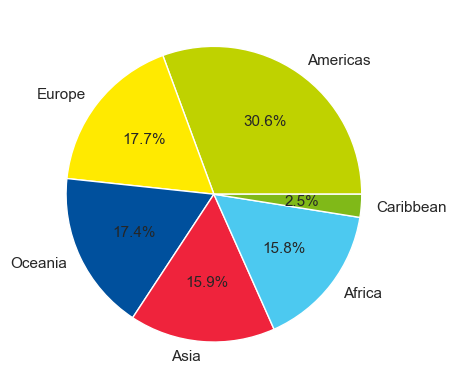

Pie chart of Total BCEs Sequestration by Continent:


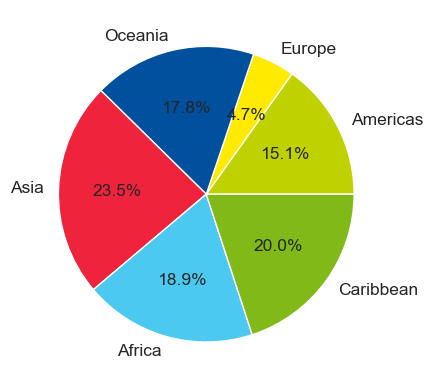

In [47]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        # paper2
colors = [pal[continent] for continent in bd['Continent']]
print("Pie chart of Total Blue Carbon Sequestration by Continent:")
plt.pie(bd['Total Blue Carbon Sequestration (tC)'], colors=colors, labels=bd['Continent'], 
        autopct='%1.1f%%', textprops={'fontsize': 11})
plt.show()

colors = [pal[continent] for continent in bd['Continent']]
print("Pie chart of Total BCEs Sequestration by Continent:")
plt.pie(bd['Total BCEs Sequestration (tC)'], colors=colors, labels=bd['Continent'], 
        autopct='%1.1f%%', textprops={'fontsize': 12.5})
plt.show()

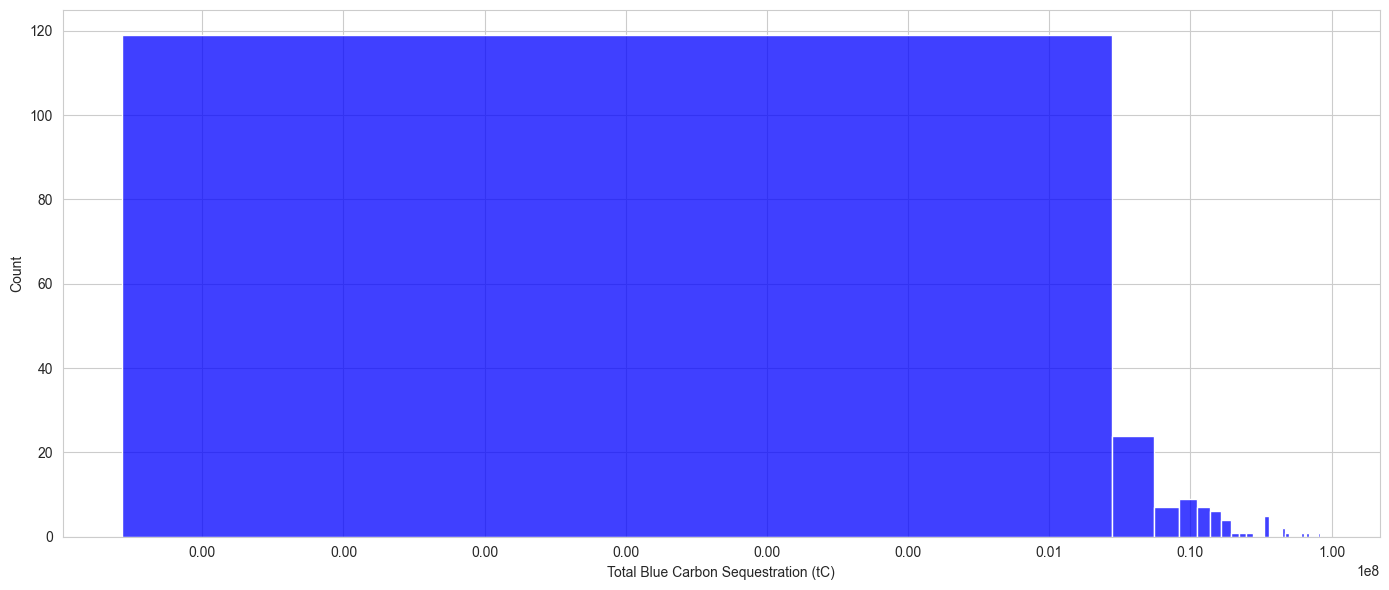

In [48]:
plt.figure(figsize=(14, 6))
sns.histplot(data=sdf, x='Total Blue Carbon Sequestration (tC)', bins=30, color='blue')
plt.xscale('log')
plt.gca().xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.tight_layout()
plt.show()

In [49]:
# Build world geometries (USA split + ISO fixes)
world = build_world_geodataframe(WLD_SHP, USA_SPLIT_CSV)
wld   = world   # alias used by map cells and mapper_bce / map_and_barplot

# Join with plot_data and compute category labels for BCE totals
country_data_bce = build_country_data(
    world=world,
    plot_data=plot_data,
    mapping=mapping,
    var='uptake_total_mean',
    which='BCE',
)

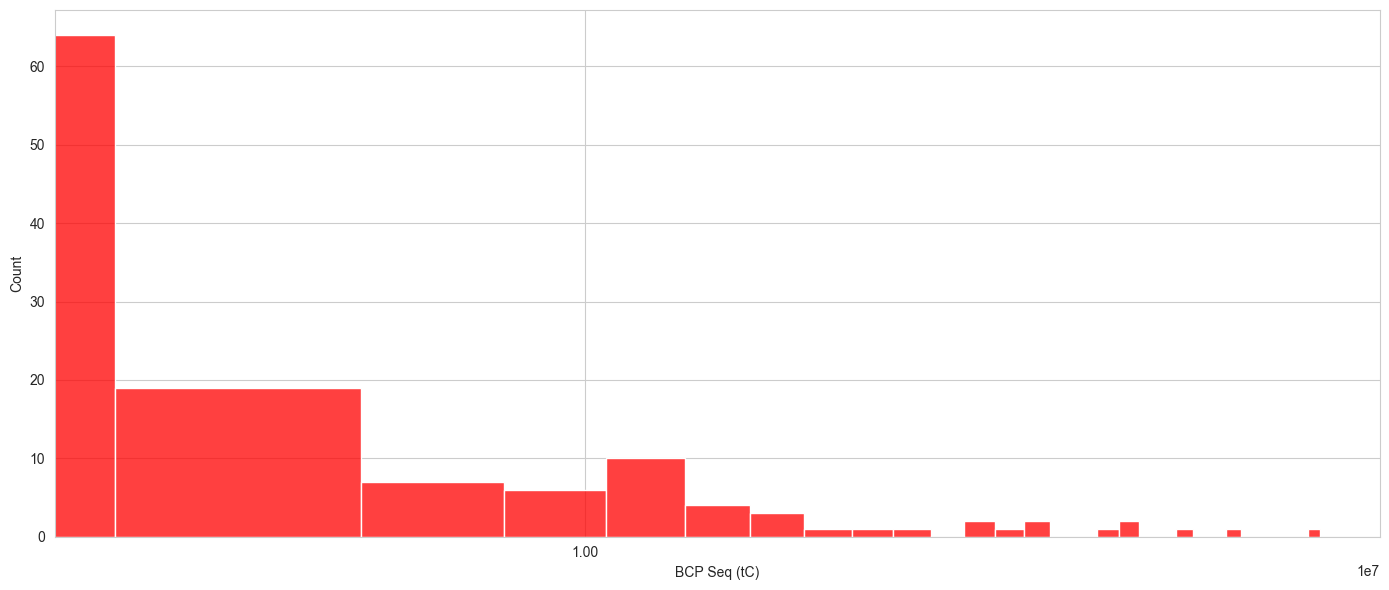

In [50]:
plt.figure(figsize=(14, 6))
sns.histplot(data=plot_data, x='BCP Seq (tC)', bins=30, color='red')
plt.xscale('log')
plt.gca().xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.tight_layout()
plt.show()

In [51]:
# Legacy column aliases used by sequestration / visualisation cells
ddf = data.copy()

ddf['Total_BCE_area_km2'] = ddf[
    ['saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2']
].sum(axis=1, skipna=True)
dq = ddf.dropna(subset=['uptake_salt_mean', 'uptake_seag_mean', 'uptake_mang_mean'])


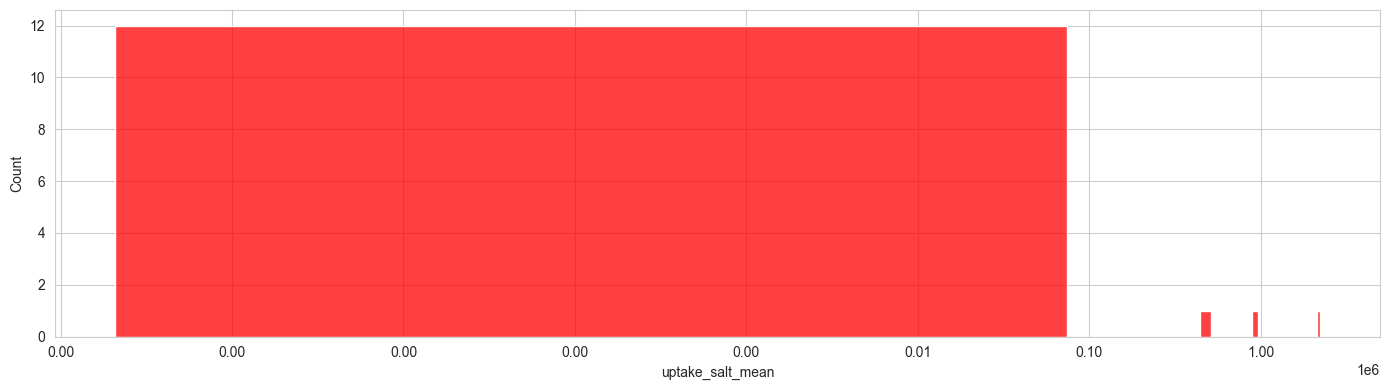

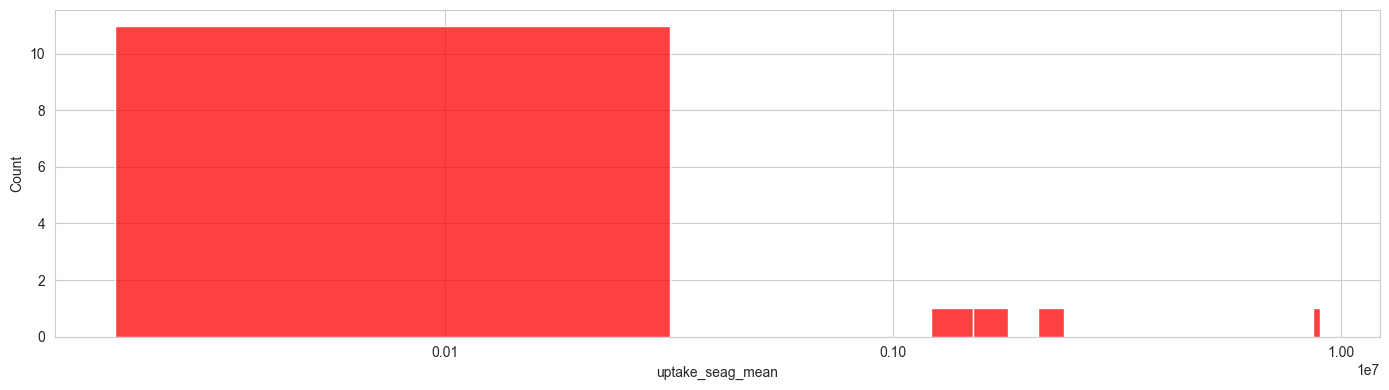

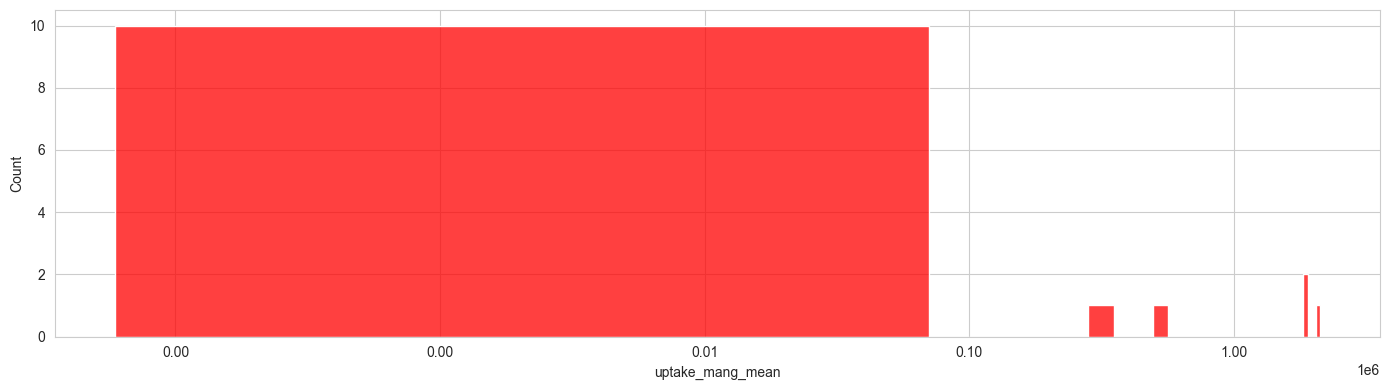

In [52]:
targvars = ['uptake_salt_mean', 'uptake_seag_mean', 'uptake_mang_mean']
colopat = ['#F2C94C', '#E27D60', '#85E3FF']

for var in targvars:
    plt.figure(figsize=(14, 4))
    sns.histplot(data=dq, x=var, bins=30, color='red')
    plt.xscale('log')
    plt.gca().xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
    plt.gca().xaxis.set_major_formatter(ScalarFormatter())
    plt.tight_layout()
    plt.show()

In [53]:
ddb = plot_data.copy()
ddb['Total BCEs Area (km²)'] = ddb[[
    'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
]].sum(axis=1, skipna=True).replace(0, np.nan)

# cmap color
cblx = sns.cubehelix_palette(n_colors=7, rot=-0.45)
cblx_rgb = cblx # liste de tuples RGB
cblx_hex = [to_hex(c) for c in cblx] # liste de hex
cblx_cmap = ListedColormap(cblx_hex)

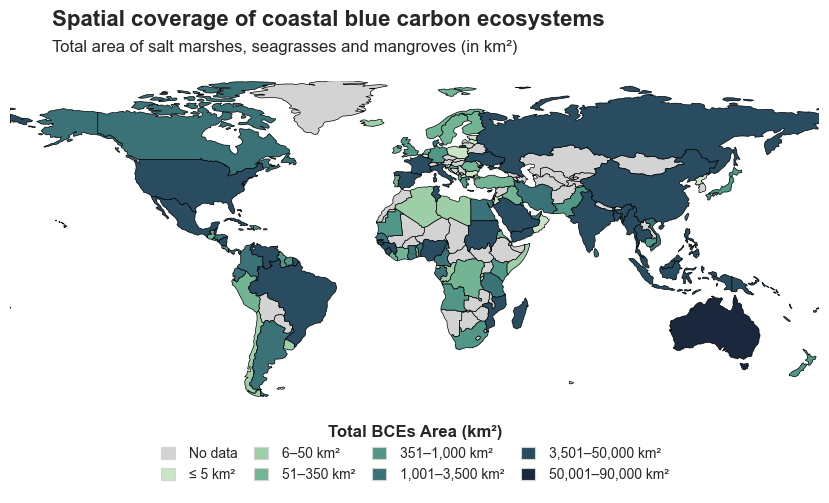

In [54]:
# Categorical (bins) test — -1 sentinel so the first label reads "≤ 5 km²"
mapper_bc(
    dtfm=ddb,
    var='Total BCEs Area (km²)',
    ecosystem='Total BCEs Area (km²)',
    cmap=cblx_cmap,
    title='Spatial coverage of coastal blue carbon ecosystems',
    subtitle='Total area of salt marshes, seagrasses and mangroves (in km²)',
    wld=wld,
    mapping=mapping,
    bins=[-1, 5, 50, 350, 1000, 3500, 50000, 90000],
    units='km²',
    already_scaled=True,
    show_legend=True,
    legend_bbox=(0.5, -0.325),
    legend_ncol=4,
    figsize=(10, 6),
)


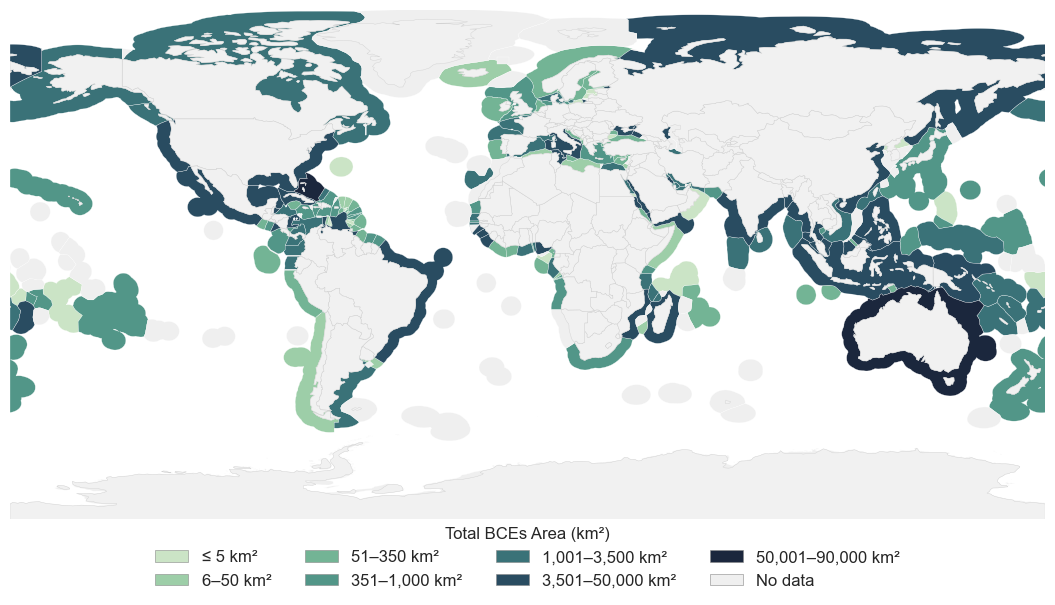

In [55]:
# paper1
# EEZ file    : EEZ_land_union_v4_202410.shp  (data_source/shp/eez/)
# Join column : TERRITORY1  (present in plot_data)

# Build input: total BCE area per EEZ territory
map_df = plot_data[
    ['country_name', 'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2']
].copy()
map_df.rename(columns={'country_name': 'UNION'}, inplace=True)
map_df['Total BCEs Area (km²)'] = (
    map_df[['saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2']]
    .sum(axis=1, skipna=True)
).replace(0, np.nan)

fig, ax, eez_disp = plot_eez_choropleth(
    eez_gdf=EEZ_SHP,
    data_df=map_df,
    value_col='Total BCEs Area (km²)',
    merge_on='UNION',
    world_gdf=WLD_SHP,
    bins=[-1, 5, 50, 350, 1000, 3500, 50000, 90000],
    palette='cubehelix',
    projection='EPSG:4326',
    missing_color='#efefef',
    legend_fontsize=12,
    figsize=(14, 6),
    title='',
    dissolve_by=None,
    clip_land=True,
 )
plt.show()

In [56]:
# # ============================================================
# # DIAGNOSTIC: cell 66 (mapper_bc / ISO) vs cell 68 (EEZ / TERRITORY1)
# # ============================================================
# import numpy as np
# import pandas as pd
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# from difflib import get_close_matches

# # ---------------------------------------------------------------
# # 0. Rebuild inputs exactly as each cell sees them
# # ---------------------------------------------------------------
# _ddb = ddb.copy()
# _ddb['Total BCEs Area (km²)'] = _ddb[
#     ['saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2']
# ].sum(axis=1, skipna=True)

# _eez_df_diag = plot_data[
#     ['TERRITORY1', 'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2']
# ].copy()
# _eez_df_diag['Total BCEs Area (km²)'] = (
#     _eez_df_diag[['saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2']]
#     .sum(axis=1, skipna=True)
# ).replace(0, np.nan)   # same as cell 68

# print('▶ Cell 66 join key: ISO        | rows:', len(_ddb),
#       '| unique:', _ddb['ISO'].nunique())
# print('▶ Cell 68 join key: TERRITORY1 | rows:', len(_eez_df_diag),
#       '| unique:', _eez_df_diag['TERRITORY1'].nunique())

# # ---------------------------------------------------------------
# # 1. Key-set audit
# # ---------------------------------------------------------------
# _eesp = gpd.read_file(EEZ_SHP)

# def _norm(s): return s.astype(str).str.strip().str.upper()

# _eesp['_T1']         = _norm(_eesp['TERRITORY1'])
# _eez_df_diag['_T1']  = _norm(_eez_df_diag['TERRITORY1'])
# _ddb['_ISO']          = _norm(_ddb['ISO'])

# set_shp    = set(_eesp['_T1'].dropna())
# set_data68 = set(_eez_df_diag['_T1'].dropna())

# in_data_not_shp = sorted(set_data68 - set_shp)
# in_shp_not_data = sorted(set_shp  - set_data68)

# print('\n──── Key audit (TERRITORY1) ────')
# print(f'  unique in data_df : {len(set_data68)}')
# print(f'  unique in EEZ shp : {len(set_shp)}')
# print(f'  in data NOT in shp  ({len(in_data_not_shp)}): {in_data_not_shp[:10]}')
# print(f'  in shp  NOT in data ({len(in_shp_not_data)}): {in_shp_not_data[:10]}')

# # ISO audit (cell 66)
# _wld_iso = _norm(wld['ISO_A3'])
# set_iso_shp  = set(_wld_iso.dropna())
# set_iso_data = set(_ddb['_ISO'].dropna())
# iso_miss = sorted(set_iso_data - set_iso_shp)
# print(f'\n  ISO in ddb NOT in world shp ({len(iso_miss)}): {iso_miss[:10]}')

# # ---------------------------------------------------------------
# # 2. Zeros / NaN comparison
# # ---------------------------------------------------------------
# n_zero_66 = (_ddb['Total BCEs Area (km²)'] == 0).sum()
# n_nan_66  =  _ddb['Total BCEs Area (km²)'].isna().sum()
# n_nan_68  =  _eez_df_diag['Total BCEs Area (km²)'].isna().sum()

# print('\n──── Zeros / NaN ────')
# print(f'  cell 66 → zeros kept as 0 : {n_zero_66}   NaN : {n_nan_66}')
# print(f'  cell 68 → zeros → NaN     : {n_nan_68}  (those EEZs show as "No data")')
# print('\nCell 66 value stats:')
# print(_ddb['Total BCEs Area (km²)'].describe().round(1).to_string())
# print('\nCell 68 value stats:')
# print(_eez_df_diag['Total BCEs Area (km²)'].describe().round(1).to_string())

# # ---------------------------------------------------------------
# # 3. Bin distribution comparison
# # ---------------------------------------------------------------
# _BINS = [-1, 5, 50, 350, 1000, 3500, 50000, 90000, np.inf]

# _cats66 = pd.cut(pd.to_numeric(_ddb['Total BCEs Area (km²)'], errors='coerce'),
#                  bins=_BINS, include_lowest=True)
# _merge68 = _eesp.merge(
#     _eez_df_diag[['TERRITORY1', 'Total BCEs Area (km²)']].drop_duplicates('TERRITORY1'),
#     on='TERRITORY1', how='left'
# )
# _cats68 = pd.cut(pd.to_numeric(_merge68['Total BCEs Area (km²)'], errors='coerce'),
#                  bins=_BINS, include_lowest=True)

# print('\n──── Bin distribution ────')
# print('Cell 66 (countries):')
# print(_cats66.value_counts(sort=False).to_string())
# print('\nCell 68 (EEZ rows after merge):')
# print(_cats68.value_counts(sort=False).to_string())

# # ---------------------------------------------------------------
# # 4. Territories with a value but no shp polygon (key mismatch)
# # ---------------------------------------------------------------
# _with_val    = set(_eez_df_diag.loc[_eez_df_diag['Total BCEs Area (km²)'].notna(), '_T1'])
# _miss_in_shp = sorted(_with_val - set_shp)

# print(f'\n──── Territories with value but no shp match ({len(_miss_in_shp)}) ────')
# print(_miss_in_shp[:20])

# # ---------------------------------------------------------------
# # 5. Fuzzy matching
# # ---------------------------------------------------------------
# _shp_list = sorted(set_shp)
# print('\n──── Fuzzy matches (top 20) ────')
# for k in _miss_in_shp[:20]:
#     best = get_close_matches(k, _shp_list, n=1, cutoff=0.5)
#     print(f"  '{k}'  →  {best[0] if best else '(no match)'}")

# # ---------------------------------------------------------------
# # 6. Debug overlay map
# # ---------------------------------------------------------------
# _eesp_plot = _eesp.copy()
# _eesp_plot['_matched'] = _eesp_plot['_T1'].isin(_with_val)

# fig_d, ax_d = plt.subplots(figsize=(16, 8))
# _eesp_plot[_eesp_plot['_matched']].plot(
#     ax=ax_d, color='#4ecb71', edgecolor='none', alpha=0.75, zorder=2)
# _eesp_plot[~_eesp_plot['_matched']].plot(
#     ax=ax_d, color='#e05252', edgecolor='none', alpha=0.4, zorder=1)
# wld.plot(ax=ax_d, color='none', edgecolor='#e07a10', linewidth=0.5, zorder=3)

# ax_d.set_axis_off()
# ax_d.set_title(
#     'EEZ match debug — green = has BCE value, red = no data match, orange = country borders',
#     fontsize=11)
# handles = [
#     mpatches.Patch(color='#4ecb71', label='EEZ matched (has BCE value)'),
#     mpatches.Patch(color='#e05252', label='EEZ polygon — no data match'),
#     mpatches.Patch(facecolor='none', edgecolor='#e07a10', linewidth=1,
#                    label='Country border (cell 66 scope)'),
# ]
# ax_d.legend(handles=handles, loc='lower left', fontsize=10, frameon=True)
# plt.tight_layout()
# # fig_d.savefig('debug_merge.png', dpi=120, bbox_inches='tight')
# plt.show()
# print('debug_merge.png saved.')
# print('\n✅ Diagnostic complete')

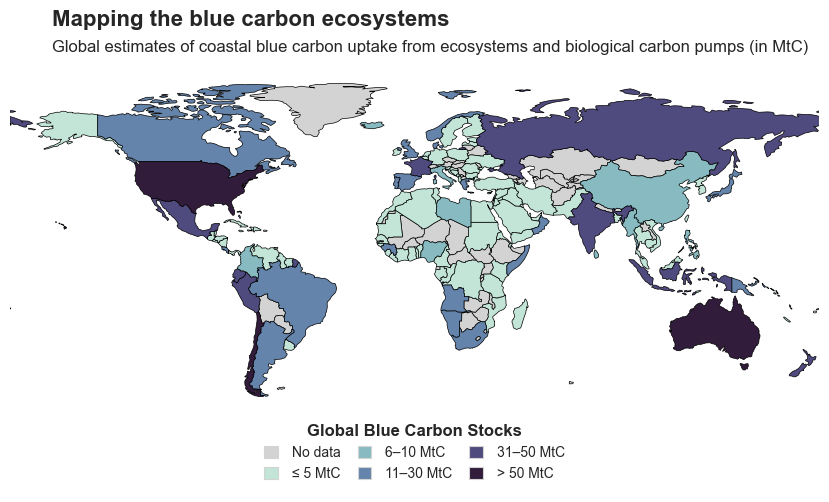

In [57]:
dbfm = ddb.copy()
palet = sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True)
mapper_bc(
    dtfm=dbfm,
    var='Total BCseq',
    ecosystem='Global Blue Carbon Stocks',
    mapping=mapping, 
    cmap=palet,
    title='Mapping the blue carbon ecosystems',
    subtitle='Global estimates of coastal blue carbon uptake from ecosystems and biological carbon pumps (in MtC)',
    wld=wld,
    bins=[-1, 5, 10, 30, 50],
    units='MtC',
    show_legend=True,
    legend_bbox=(0.5, -0.325),
    legend_ncol=3,
    figsize=(10, 6),
)

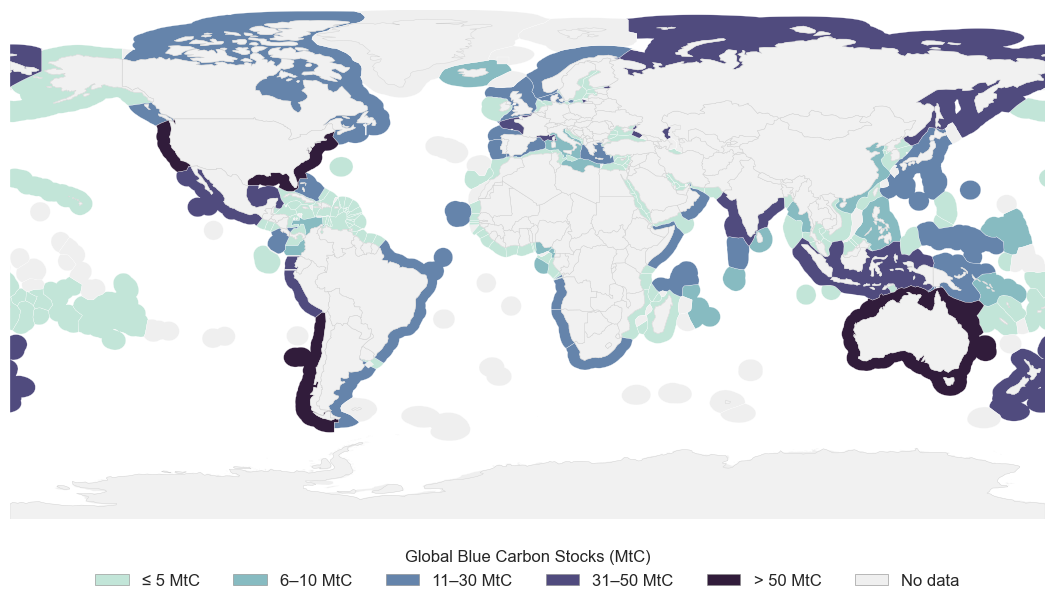

In [58]:
# paper1
map_df = plot_data[
    ['country_name', 'Total BCseq']
].copy()
map_df.rename(columns={'country_name': 'UNION'}, inplace=True)
map_df['Global Blue Carbon Stocks (MtC)'] = map_df['Total BCseq'] / 1e6  # convert to MtC

fig, ax, eez_disp = plot_eez_choropleth(
    eez_gdf=EEZ_SHP,
    data_df=map_df,
    value_col='Global Blue Carbon Stocks (MtC)',
    merge_on='UNION',
    world_gdf=WLD_SHP,
    bins=[-1, 5, 10, 30, 50],
    units='MtC',
    palette=palet,
    projection='EPSG:4326',
    missing_color='#efefef',
    legend_fontsize=12,
    legend_ncol=6,
    figsize=(14, 6),
    title='',
    dissolve_by=None,
    clip_land=True,
)
plt.show()

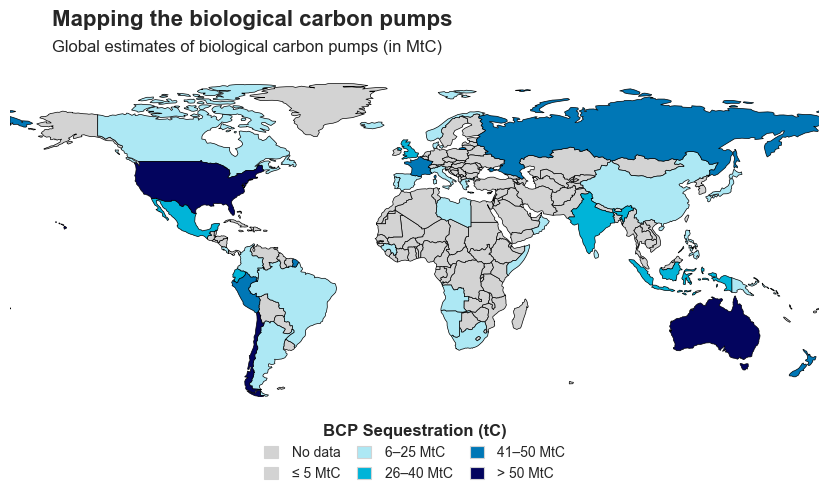

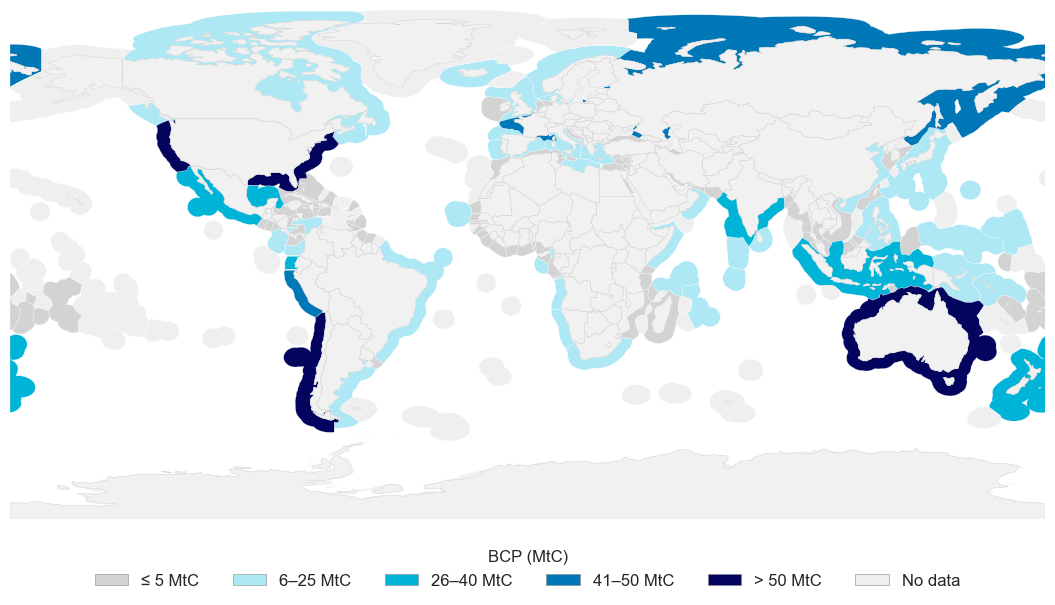

In [59]:
# supl11
# palet3 from color_map3
palet3 = ListedColormap(list(color_map3.values()))
mapper_bc(
    dtfm=dbfm,
    var='BCP Seq (tC)',
    ecosystem='BCP Sequestration (tC)',
    mapping=mapping, 
    cmap=palet3,
    title='Mapping the biological carbon pumps',
    subtitle='Global estimates of biological carbon pumps (in MtC)',
    wld=wld,
    bins=[-1, 5, 25, 40, 50],
    units='MtC',
    already_scaled=False,
    show_legend=True,
    legend_bbox=(0.5, -0.325),
    legend_ncol=3,
    figsize=(10, 6),
)

map_df = plot_data[
    ['country_name', 'BCP Seq (tC)']
].copy()
map_df.rename(columns={'country_name': 'UNION'}, inplace=True)
map_df['BCP (MtC)'] = map_df['BCP Seq (tC)'] / 1e6  # convert to MtC

fig, ax, eez_disp = plot_eez_choropleth(
    eez_gdf=EEZ_SHP,
    data_df=map_df,
    value_col='BCP (MtC)',
    merge_on='UNION',
    world_gdf=WLD_SHP,
    bins=[-1, 5, 25, 40, 50],
    units='MtC',
    palette=palet3,
    projection='EPSG:4326',
    missing_color='#efefef',
    legend_fontsize=12,
    legend_ncol=6,
    figsize=(14, 6),
    title='',
    dissolve_by=None,
    clip_land=True,
)
plt.show()

### BCE Area and Uptake Bar Charts

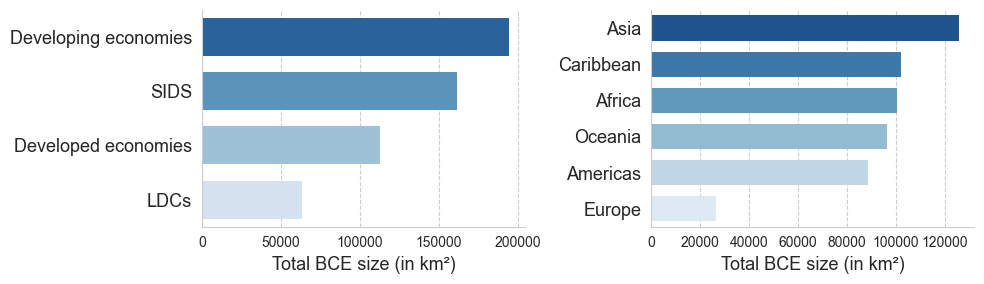

In [60]:
# paper1
grou = ddf.groupby('Groups')['Total_BCE_area_km2'].sum().sort_values(ascending=False).reset_index()
grou['Total_BCE_area_km2'] = grou['Total_BCE_area_km2']

grou2 = ddf.groupby('Continent')['Total_BCE_area_km2'].sum().sort_values(ascending=False).reset_index()
grou2['Total_BCE_area_km2'] = grou2['Total_BCE_area_km2']

# on 1 row and 2 cols
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
sns.set_theme(style='whitegrid')
# Groups
sns.barplot(
    data=grou, x='Total_BCE_area_km2', y='Groups', 
    width=0.7, palette='Blues_r', ax=axs[0], edgecolor='none'
)
axs[0].set_ylabel('')
axs[0].set_yticklabels(axs[0].get_yticklabels(), fontsize=13)
axs[0].set_xlabel('Total BCE size (in km²)', fontsize=13)
sns.despine(ax=axs[0])
axs[0].grid(True, axis='x', linestyle='--')

# Continents
sns.barplot(
    data=grou2, x='Total_BCE_area_km2', y='Continent', 
    width=0.7, palette='Blues_r', ax=axs[1], edgecolor='none'
)
axs[1].set_ylabel('')
axs[1].set_yticklabels(axs[1].get_yticklabels(), fontsize=13)
axs[1].set_xlabel('Total BCE size (in km²)', fontsize=13)
sns.despine(ax=axs[1])
axs[1].grid(True, axis='x', linestyle='--')

plt.tight_layout()
plt.show()

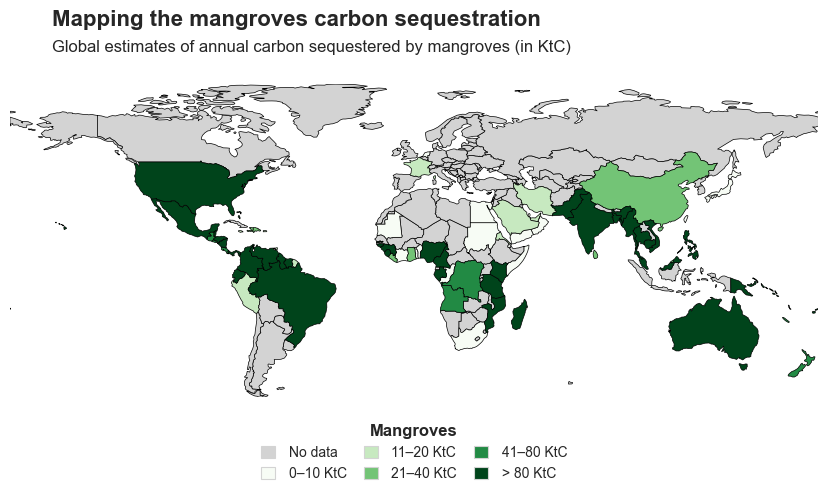

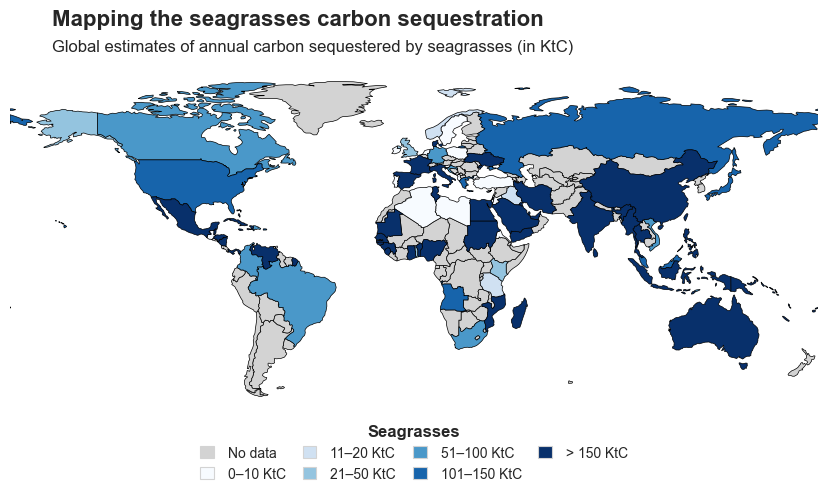

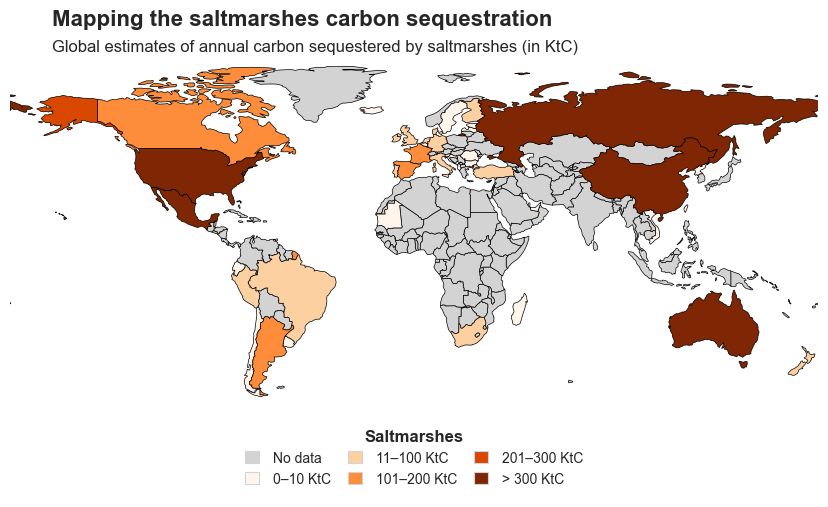

In [61]:
dictvars = {
    'Mangroves': [
        'uptake_mang_mean', 'Greens', 'Carbon Sequestered by Mangroves',
        'Estimates based on Mangroves areas and his sequestration rates',
        [0, 10, 20, 40, 80], 3
    ],
    'Seagrasses': [
        'uptake_seag_mean', 'Blues', 'Carbon Sequestered by Seagrasses',
        'Estimates based on Seagrasses areas and his sequestration rates',
        [0, 10, 20, 50, 100, 150], 4
    ],
    'Saltmarshes': [
        'uptake_salt_mean', 'Oranges', 'Carbon Sequestered by Saltmarshes',
        'Estimates based on Saltmarshes areas and his sequestration rates',
        [0, 10, 100, 200, 300], 3
    ]
}

for ecosystem, (var, palet, title, subtitle, bins, ncol) in dictvars.items():
    dbfm = ddb.copy().replace(0, np.nan)
    dbfm[f'{ecosystem} Sequestration (KtC)'] = dbfm[var]
    mapper_bc(
        dtfm=dbfm,
        var=f'{ecosystem} Sequestration (KtC)',
        ecosystem=ecosystem,
        cmap=palet,
        title=f'Mapping the {ecosystem.lower()} carbon sequestration',
        subtitle=f'Global estimates of annual carbon sequestered by {ecosystem.lower()} (in KtC)',
        mapping=mapping,
        wld=wld,
        bins=bins,
        units='KtC',
        already_scaled=False,
        show_legend=True,
        legend_bbox=(0.5, -0.325),
        legend_ncol=ncol,
        figsize=(10, 6),
    )

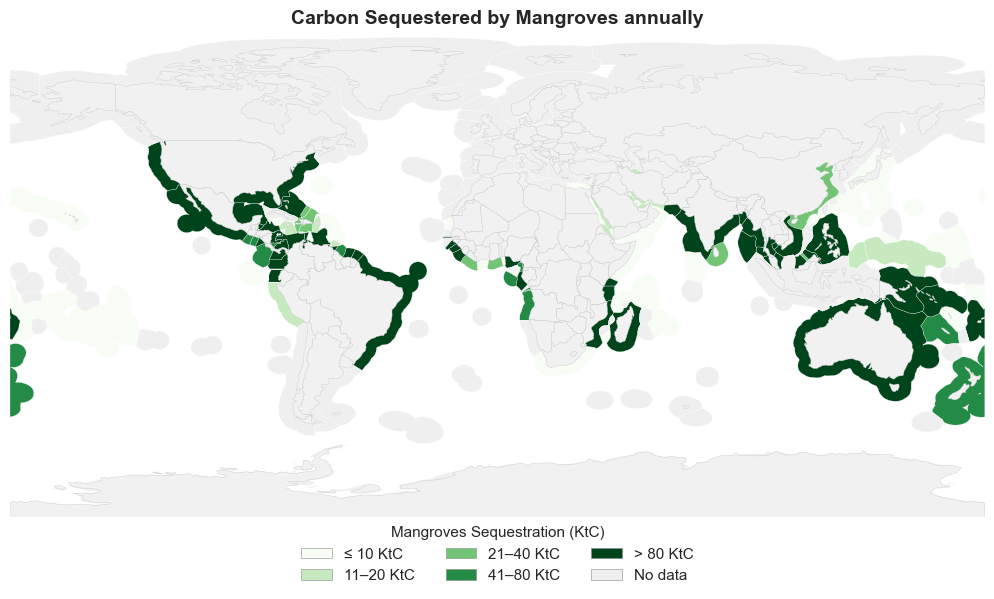

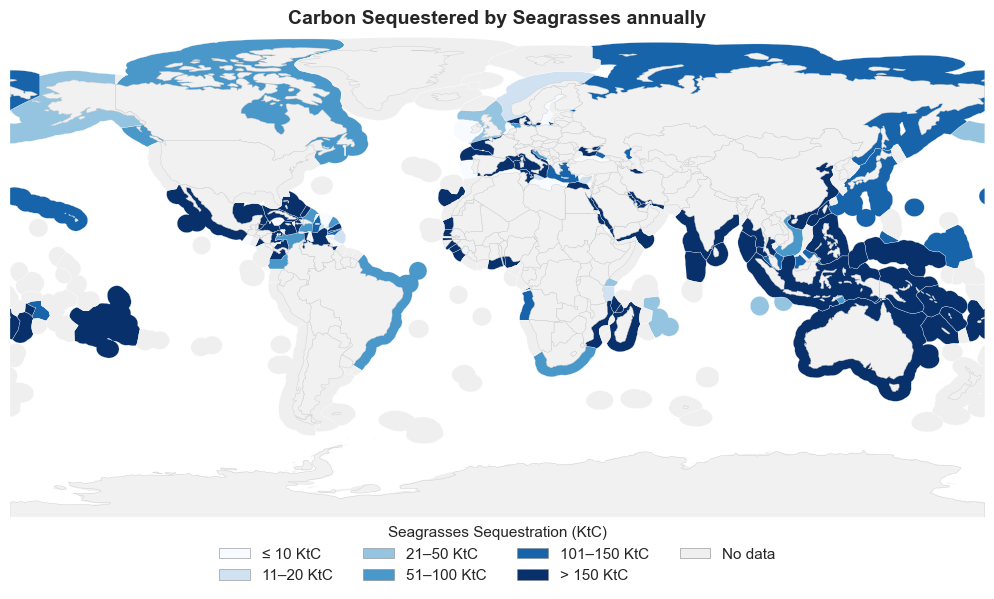

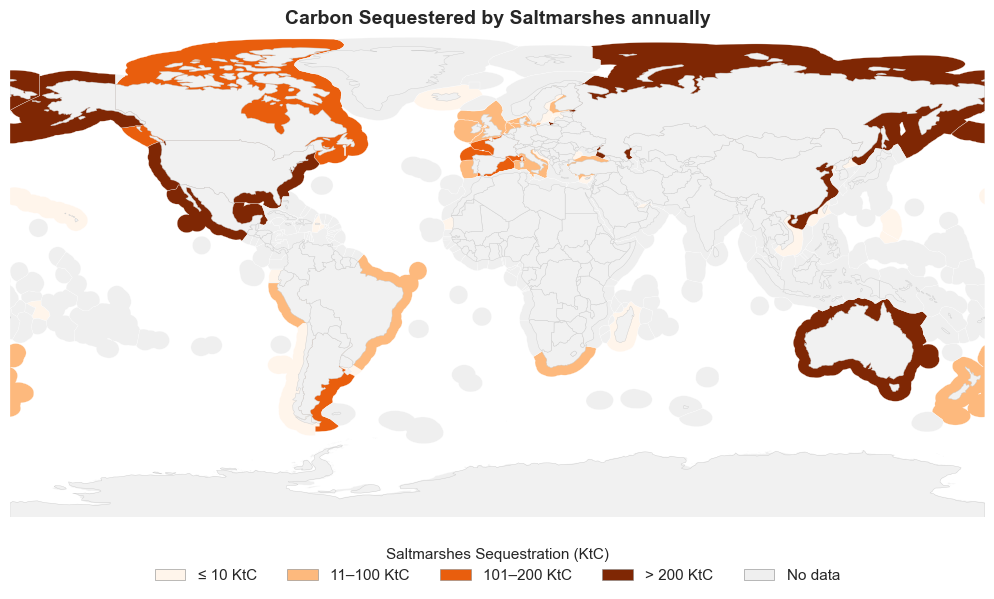

In [62]:
# supl11
dictvars = {
    'Mangroves': [
        'uptake_mang_mean', 'Greens', 'Carbon Sequestered by Mangroves annually',
        [-1, 10, 20, 40, 80], 3
    ],
    'Seagrasses': [
        'uptake_seag_mean', 'Blues', 'Carbon Sequestered by Seagrasses annually',
        [-1, 10, 20, 50, 100, 150], 4
    ],
    'Saltmarshes': [
        'uptake_salt_mean', 'Oranges', 'Carbon Sequestered by Saltmarshes annually',
        [-1, 10, 100, 200], 5
    ]
}

for ecosystem, (var, palet, title, bins, ncol) in dictvars.items():
    dbfm = ddb.copy()
    dbfm[f'{ecosystem} Sequestration (KtC)'] = dbfm[var]
    
    map_df = dbfm[['country_name', f'{ecosystem} Sequestration (KtC)']].copy()
    map_df.rename(columns={'country_name': 'UNION'}, inplace=True)
    
    fig, ax, eez_disp = plot_eez_choropleth(
        eez_gdf=EEZ_SHP,
        data_df=map_df,
        value_col=f'{ecosystem} Sequestration (KtC)',
        merge_on='UNION',
        world_gdf=WLD_SHP,
        bins=bins,
        units='KtC',
        already_scaled=False,
        palette=palet,
        projection='EPSG:4326',
        missing_color='#efefef',
        title=title,
        legend_ncol=ncol
    )
    plt.show()

In [63]:
(ddf
 .groupby('Groups')['uptake_total_mean']
 .mean()
 .sort_values(ascending=False)
 .reset_index()
 .assign(**{
     'Avg. BCEs Sequestration (MtC)': lambda x: x['uptake_total_mean'] / 1e6
 })
)[['Groups', 'Avg. BCEs Sequestration (MtC)']]

,Groups,Avg. BCEs Sequestration (MtC)
0,Developing economies,0.6770
1,SIDS,0.6344
2,LDCs,0.6251
3,Developed economies,0.5977


In [64]:
(ddf
 .groupby('Groups')['Total BCseq']
 .mean()
 .sort_values(ascending=False)
 .reset_index()
 .assign(**{
     'Avg. Total BC Sequestered (MtC)': lambda x: x['Total BCseq'] / 1e6}
 )
)[['Groups', 'Avg. Total BC Sequestered (MtC)']]

,Groups,Avg. Total BC Sequestered (MtC)
0,Developed economies,11.0117
1,Developing economies,7.0410
2,SIDS,3.1244
3,LDCs,3.1165


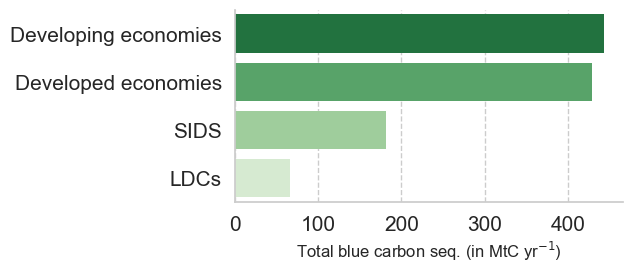

In [65]:
grou = ddf.groupby('Groups')['Total BCseq'].sum().sort_values(ascending=False).reset_index()
grou['Total BCseq'] = grou['Total BCseq'] / 1e6

sns.set_theme(style='whitegrid')
plt.figure(figsize=(5, 2.5))
sns.barplot(
    data=grou, x='Total BCseq', y='Groups', 
    width=0.8, palette='Greens_r', edgecolor='none'
)
# text on bars
# for p in plt.gca().patches:
#     plt.gca().text(p.get_width() + 10, p.get_y() + p.get_height()/2, 
#                    f'{p.get_width():.2f}', va='center', ha='left', fontsize=9, color='steelblue')
plt.ylabel('')
plt.xlabel('Total blue carbon seq. (in MtC yr$^{-1}$)')
sns.despine()
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True, axis='x', linestyle='--')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

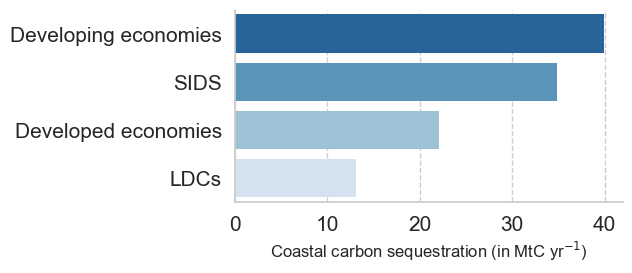

In [66]:
# paper2
grou = ddf.groupby('Groups')['uptake_total_mean'].sum().sort_values(ascending=False).reset_index()
grou['uptake_total_mean'] = grou['uptake_total_mean']/1e6

sns.set_theme(style='whitegrid')
plt.figure(figsize=(5, 2.5))
sns.barplot(
    data=grou, x='uptake_total_mean', y='Groups', 
    width=0.8, palette='Blues_r', edgecolor='none'
)
# text on bars
# for p in plt.gca().patches:
#     plt.gca().text(p.get_width() + 10, p.get_y() + p.get_height()/2, 
#                    f'{p.get_width():.2f} MtC', va='center', ha='left', fontsize=9)
plt.ylabel('')
plt.xlabel('Coastal carbon sequestration (in MtC yr$^{-1}$)')
sns.despine()
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.grid(True, axis='x', linestyle='--')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

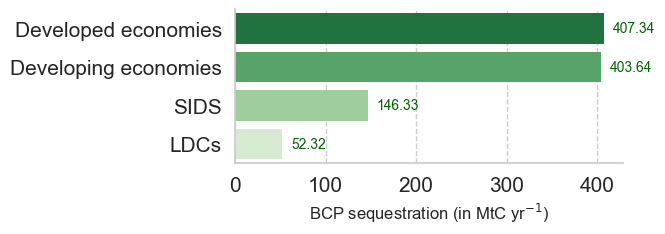

In [67]:
# paper3
grou = ddf.groupby('Groups')['BCP Seq (tC)'].sum().sort_values(ascending=False).reset_index()
grou['BCP Seq (tC)'] = grou['BCP Seq (tC)']/1e6

sns.set_theme(style='whitegrid')
plt.figure(figsize=(5, 2))
sns.barplot(
    data=grou, x='BCP Seq (tC)', y='Groups', 
    width=0.8, palette='Greens_r', edgecolor='none'
    )
# text on bars
for p in plt.gca().patches:
    plt.gca().text(p.get_width() + 10, p.get_y() + p.get_height()/2,
                   f'{p.get_width():.2f}', va='center', ha='left', fontsize=10, color='darkgreen')
plt.ylabel('')
plt.xlabel('BCP sequestration (in MtC yr$^{-1}$)')
sns.despine()
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.grid(True, axis='x', linestyle='--')
plt.show

In [68]:
seqt = ddf[[
     'ISO', 'Continent', 'Groups', 'uptake_salt_mean', 'uptake_seag_mean',
     'uptake_mang_mean', 'BCP Seq (tC)'
]].copy()
seqt = seqt.rename(columns={
     'uptake_salt_mean': 'Saltmarshes Sequestration (tC)',
     'uptake_seag_mean': 'Seagrasses Sequestration (tC)',
     'uptake_mang_mean': 'Mangroves Sequestration (tC)',
     'BCP Seq (tC)': 'BCP Sequestration (tC)'
})
# Only sum numeric columns to avoid TypeError
ecosystem_totals = seqt.select_dtypes(include='number').sum()
ecosystem_totals = ecosystem_totals / 1e6 
ecosystem_totals = ecosystem_totals.sort_values(ascending=False)  # Fixing the sort_values issue
print("""************************************************************************
     Carbon sequestered by NCS (Natural Carbon Sink) in MtC by year
************************************************************************""")
ecosystem_totals

************************************************************************
     Carbon sequestered by NCS (Natural Carbon Sink) in MtC by year
************************************************************************


BCP Sequestration (tC)           1,017.1513
Seagrasses Sequestration (tC)       81.5495
Mangroves Sequestration (tC)        20.7275
Saltmarshes Sequestration (tC)       9.1635
dtype: float64

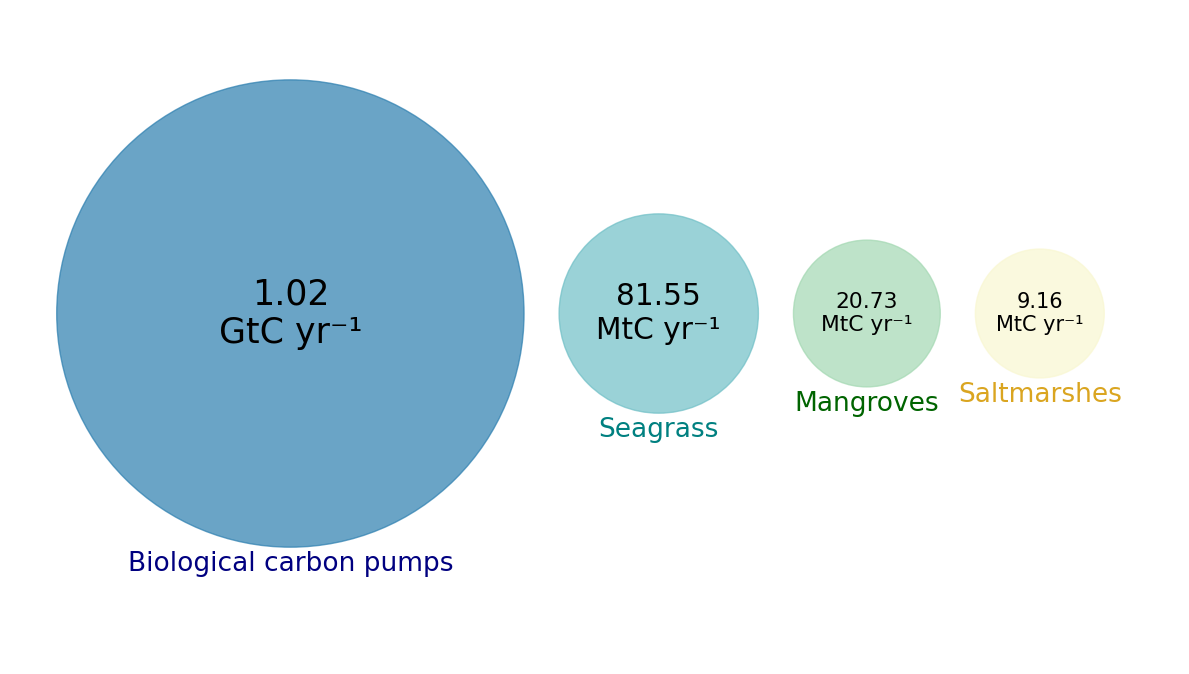

In [69]:
# paper3
ecosystem_totals.index = ["Biological carbon pumps", "Seagrass", "Mangroves", "Saltmarshes"]
circle_area_plot(
    ecosystem_totals=ecosystem_totals,
    colors=['#2b7eaf', '#6fbfc6', '#a3d8b2', '#f9f7d1'],
    label_colors=['navy', 'teal', 'darkgreen', 'goldenrod']
)


In [70]:
uptake_by_continent = seqt.groupby('Continent').agg({
    'BCP Sequestration (tC)'        : 'sum',
    'Saltmarshes Sequestration (tC)': 'sum',
    'Seagrasses Sequestration (tC)' : 'sum',
    'Mangroves Sequestration (tC)'  : 'sum'
}).reset_index()
uptake_by_continent = uptake_by_continent.rename(columns={
    'BCP Sequestration (tC)'        : 'Blue Carbon Pump (MtC)',
    'Saltmarshes Sequestration (tC)': 'Saltmarshes (MtC)',
    'Seagrasses Sequestration (tC)' : 'Seagrasses (MtC)',
    'Mangroves Sequestration (tC)'  : 'Mangroves (MtC)'
})
uptake_by_continent[[
    'Blue Carbon Pump (MtC)', 'Saltmarshes (MtC)', 'Seagrasses (MtC)', 'Mangroves (MtC)'
]] = (
    uptake_by_continent[[
        'Blue Carbon Pump (MtC)', 'Saltmarshes (MtC)', 'Seagrasses (MtC)', 'Mangroves (MtC)'
    ]] / 1e6
)
uptake_by_continent.to_csv(SUMMARY_DIR / 'sequestration_by_continent.csv', index=False)
uptake_by_continent


,Continent,Blue Carbon Pump (MtC),Saltmarshes (MtC),Seagrasses (MtC),Mangroves (MtC)
0,Africa,157.5229,0.0239,15.8301,5.1644
1,Americas,328.6054,4.0613,5.9842,6.8360
2,Asia,153.5396,0.9741,19.9991,5.2612
3,Caribbean,6.0787,0.0100,21.8032,0.4390
4,Europe,194.5450,1.8503,3.3458,0.0000
5,Oceania,176.8597,2.2439,14.5866,3.0269


## Regressions

Log-log regression models linking BCW to EEZ size, CO₂ emissions, and debt.

In [71]:
sns.set_theme(style='whitegrid')

Regression equation: $y = 9.61 + 0.70x$ | $R² = 0.20$


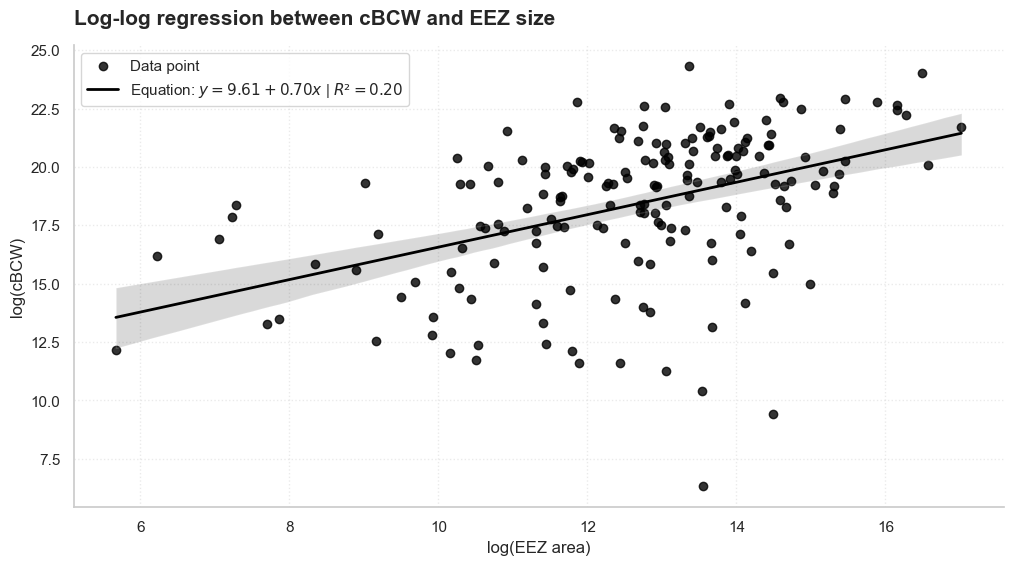

In [72]:
df = data.copy()
df = df[(df['Area_EEZ_KM2'] > 0) & (df['cBCW'] > 0)].copy()
df['log_EEZ'] = np.log(df['Area_EEZ_KM2'])
df['log_cBCW'] = np.log(df['cBCW'])
df = df.dropna(subset=['log_EEZ', 'log_cBCW'])
X = df['log_EEZ']
y = df['log_cBCW']
X = sm.add_constant(X)  # intercept

model = sm.OLS(y, X).fit()
a_hat = model.params['const']  # Intercept (a^)
b_hat = model.params['log_EEZ']  # Coefficient (b^)
R2 = model.rsquared  # Coefficient R²

# regression formula
equation = f"$y = {a_hat:.2f} + {b_hat:.2f}x$ | $R² = {R2:.2f}$"  
print(f"Regression equation: {equation}")

plt.figure(figsize=(12, 6))
# sns.scatterplot(data=df, x='log_EEZ', y='log_cBCW', alpha=0.4, color='blue')
sns.regplot(
    x='log_EEZ', y='log_cBCW', data=df, scatter=True, 
    color='black', line_kws={"linewidth": 2}
)
plt.xlabel('log(EEZ area)')
plt.ylabel('log(cBCW)')
plt.title(
    'Log-log regression between cBCW and EEZ size', 
    fontweight='bold', fontsize=15, pad=15, loc='left'
)
plt.legend(labels=['Data point', f'Equation: {equation}'], loc='best')
for sp in ['top', 'right']:
    plt.gca().spines[sp].set_visible(False)
plt.grid(alpha=0.4, linestyle=':')
plt.show()

In [73]:
are = data.copy()
are['total_BCEs(km²)'] = are[[
    'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
]].sum(axis=1, skipna=True)
are = are[[
       'ISO', 'Groups', 'Population', 'Area_EEZ_KM2', 'Area_EEZ_KM2_per_capita', 'total_BCEs(km²)',
       'uptake_total_mean', 'cBCW', 'cBCW_per_capita']]
are.rename(columns={'Area_EEZ_KM2': 'EEZ'}, inplace=True)
are['total_BCEs(km²)'] = are['total_BCEs(km²)'].replace(0, np.nan)
are['log EEZ'] = np.log(are['EEZ'])
are['log BCE'] = np.log(are['total_BCEs(km²)'])
are.head()


,ISO,Groups,Population,EEZ,Area_EEZ_KM2_per_capita,total_BCEs(km²),uptake_total_mean,cBCW,cBCW_per_capita,log EEZ,log BCE
0,AE,NaN,NaN,"6,199.3060",NaN,NaN,NaN,NaN,NaN,8.7322,NaN
1,AFG,LDCs,"41,454,761.0000","641,860.3931",0.0155,NaN,NaN,NaN,NaN,13.3721,NaN
2,US-AK,NaN,NaN,"5,193,058.2890",NaN,"1,771.4588","305,245.2500","626,366,528.0000",NaN,15.4628,7.4796
3,ALB,Developed economies,"2,811,655.0000","40,953.5448",0.0146,90.5973,"17,454.8828","35,835,124.0000",12.7452,10.6202,4.5064
4,DZA,Developing economies,"46,164,219.0000","2,444,283.5600",0.0529,40.4832,"8,856.2158","18,190,912.0000",0.3940,14.7093,3.7009


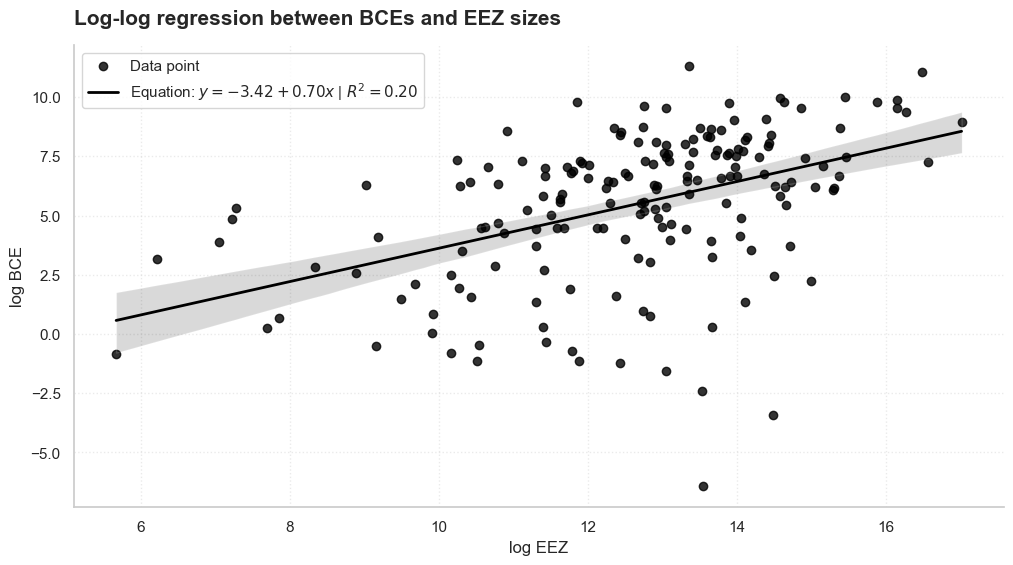

In [74]:
are = are.dropna(subset=['log EEZ', 'log BCE'])
X = are['log EEZ']
y = are['log BCE']
X = sm.add_constant(X)  # intercept
model = sm.OLS(y, X).fit()
a_hat = model.params['const']  # Interception (are^)
b_hat = model.params['log EEZ']  # Coefficient (b^)

R2 = model.rsquared  # Coefficient R²
equation = f"$y = {a_hat:.2f} + {b_hat:.2f}x$ | $R^2 = {R2:.2f}$"

plt.figure(figsize=(12, 6))
# plt.scatter(are['log EEZ'], are['log BCE'], color='green', alpha=0.6)
sns.regplot(
    x='log EEZ', y='log BCE', data=are, scatter=True, 
    color='black', line_kws={"linewidth": 2}
)
plt.xlabel('log EEZ')
plt.ylabel('log BCE')
plt.title(
    'Log-log regression between BCEs and EEZ sizes', 
    fontweight='bold', fontsize=15, pad=15, loc='left'
)
plt.legend(labels=['Data point', f'Equation: {equation}'], loc='best')
for sp in ['top', 'right']:
    plt.gca().spines[sp].set_visible(False)
plt.grid(alpha=0.4, linestyle=':')
plt.show()

Regression equation: $y = 11.11 + 0.46x$ | $R² = 0.18$


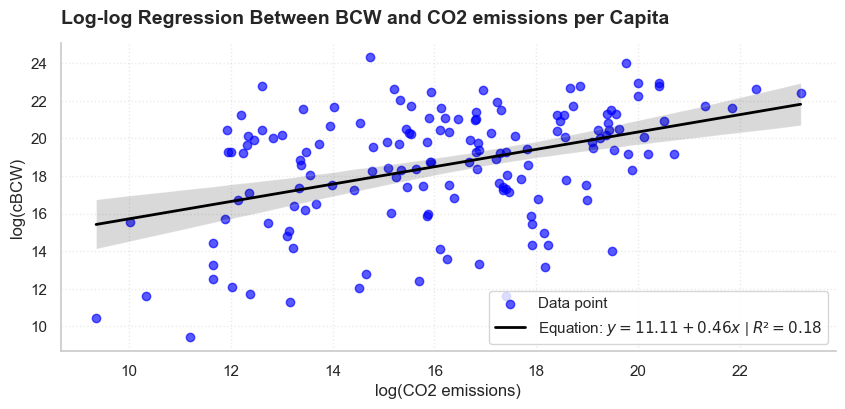

Regression equation: $y = -3.42 + 0.70x$ | $R² = 0.20$


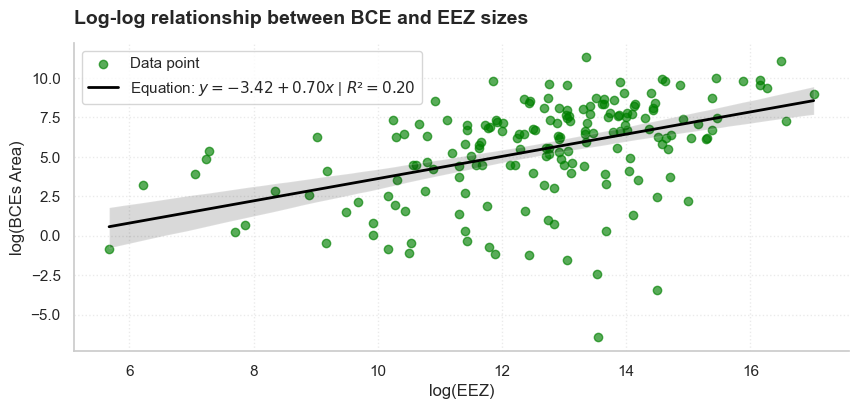

Regression equation: $y = -8.25 + -0.10x$ | $R² = 0.00$


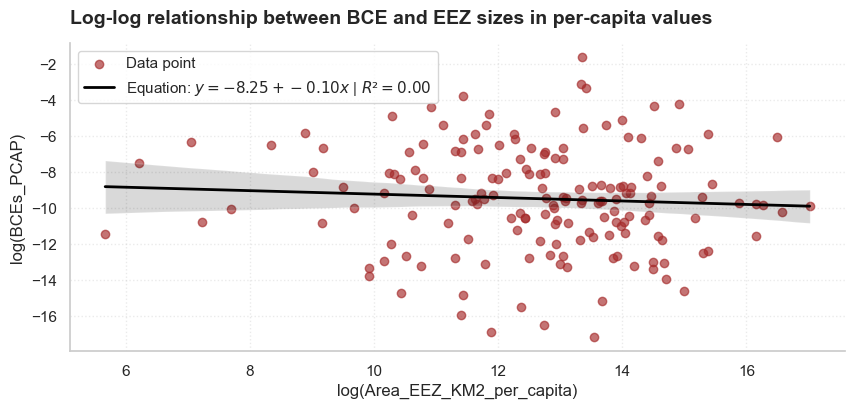

Regression equation: $y = 13.29 + 0.36x$ | $R² = 0.09$


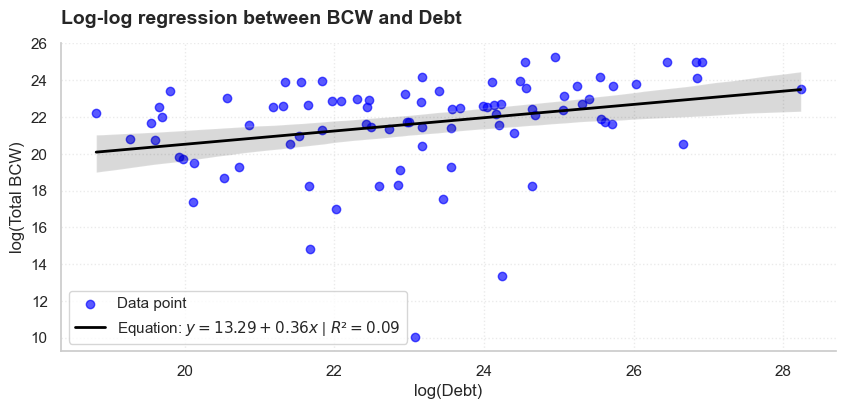

Regression equation: $y = 5.71 + 1.17x$ | $R² = 0.40$


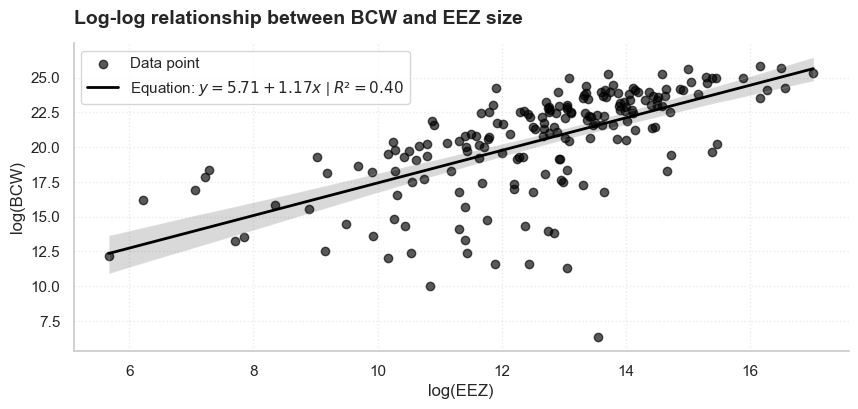

In [75]:
# supl3
regplotter(
    data, 'CO2_emissions_2023', 
    'log CO2',
    'Log-log Regression Between BCW and CO2 emissions per Capita',
    'CO2 emissions'
)

# ddf['BCEs area'] = ddf[[
#     'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
# ]].fillna(0).sum(axis=1).replace(0, np.nan)

ddt = data.copy()
ddt['BCEs Area'] = ddt[[
    'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
]].fillna(0).sum(axis=1).replace(0, np.nan)

ddt['Area_EEZ_KM2_per_capita'] = ddt['Area_EEZ_KM2'] / ddt['Population']
ddt['BCEs_PCAP'] = ddt['BCEs Area'] / ddt['Population']
ddt['cBCW'] = ddt['cBCW']
ddt['BCW'] = ddt['Total BCW']
ddt['EEZ'] = ddt['Area_EEZ_KM2']

regplotter(
    ddt, 'Area_EEZ_KM2', 'log(EEZ Size)',
    'Log-log relationship between BCE and EEZ sizes',
    'EEZ', 'BCEs Area', 'green'
)
regplotter(
    ddt, 'Area_EEZ_KM2', 'log(EEZ)',
    'Log-log relationship between BCE and EEZ sizes in per-capita values',
    'Area_EEZ_KM2_per_capita', 'BCEs_PCAP', 'brown'
)
regplotter(
    data, 'Debt (2015 US$)', 'log Debt',
    'Log-log regression between BCW and Debt',
    'Debt', 'Total BCW'
)

regplotter(
    ddt, 'EEZ', 'log(EEZ)',
    'Log-log relationship between BCW and EEZ size',
    'EEZ', 'BCW', 'black'
)


In [76]:
# # BCW vs CO2 emissions per capita
# regplotter_log_axes(
#     dtf=data,
#     var='CO2_emissions_2023',
#     varname='log CO2',
#     title='Log-log Regression Between coastal BCW and CO2 emissions per capita',
#     xlab='CO2 emissions per capita',
#     yvar='cBCW'
# )

# # BCW vs Debt per capita
# regplotter_log_axes(
#     dtf=data,
#     var='Debt (2015 US$)',
#     varname='log Debt',
#     title='Log-log Regression Between coastal BCW and Debt per capita',
#     xlab='Debt per capita (2015 US$)',
#     yvar='cBCW'
# )

# # Total BCW per capita vs EEZ per capita
# regplotter_log_axes(
#     dtf=data,
#     var='Area_EEZ_KM2_per_capita',
#     varname='log EEZ',
#     title='Log-log relationship between Total BCW and EEZ per capita',
#     xlab='EEZ per capita (km²)',
#     yvar='Total BCW_per_capita'
# )


## Bar Charts — BCW Analysis

Country and group-level bar charts for coastal BCW, BCP wealth, and total BCW.

### Coastal BCW per Capita (Top 30)

In [77]:
df = data.copy()
by_country = df[['ISO', 'cBCW_per_capita', 'Groups']]
by_country = by_country.sort_values(by='cBCW_per_capita', ascending=False)

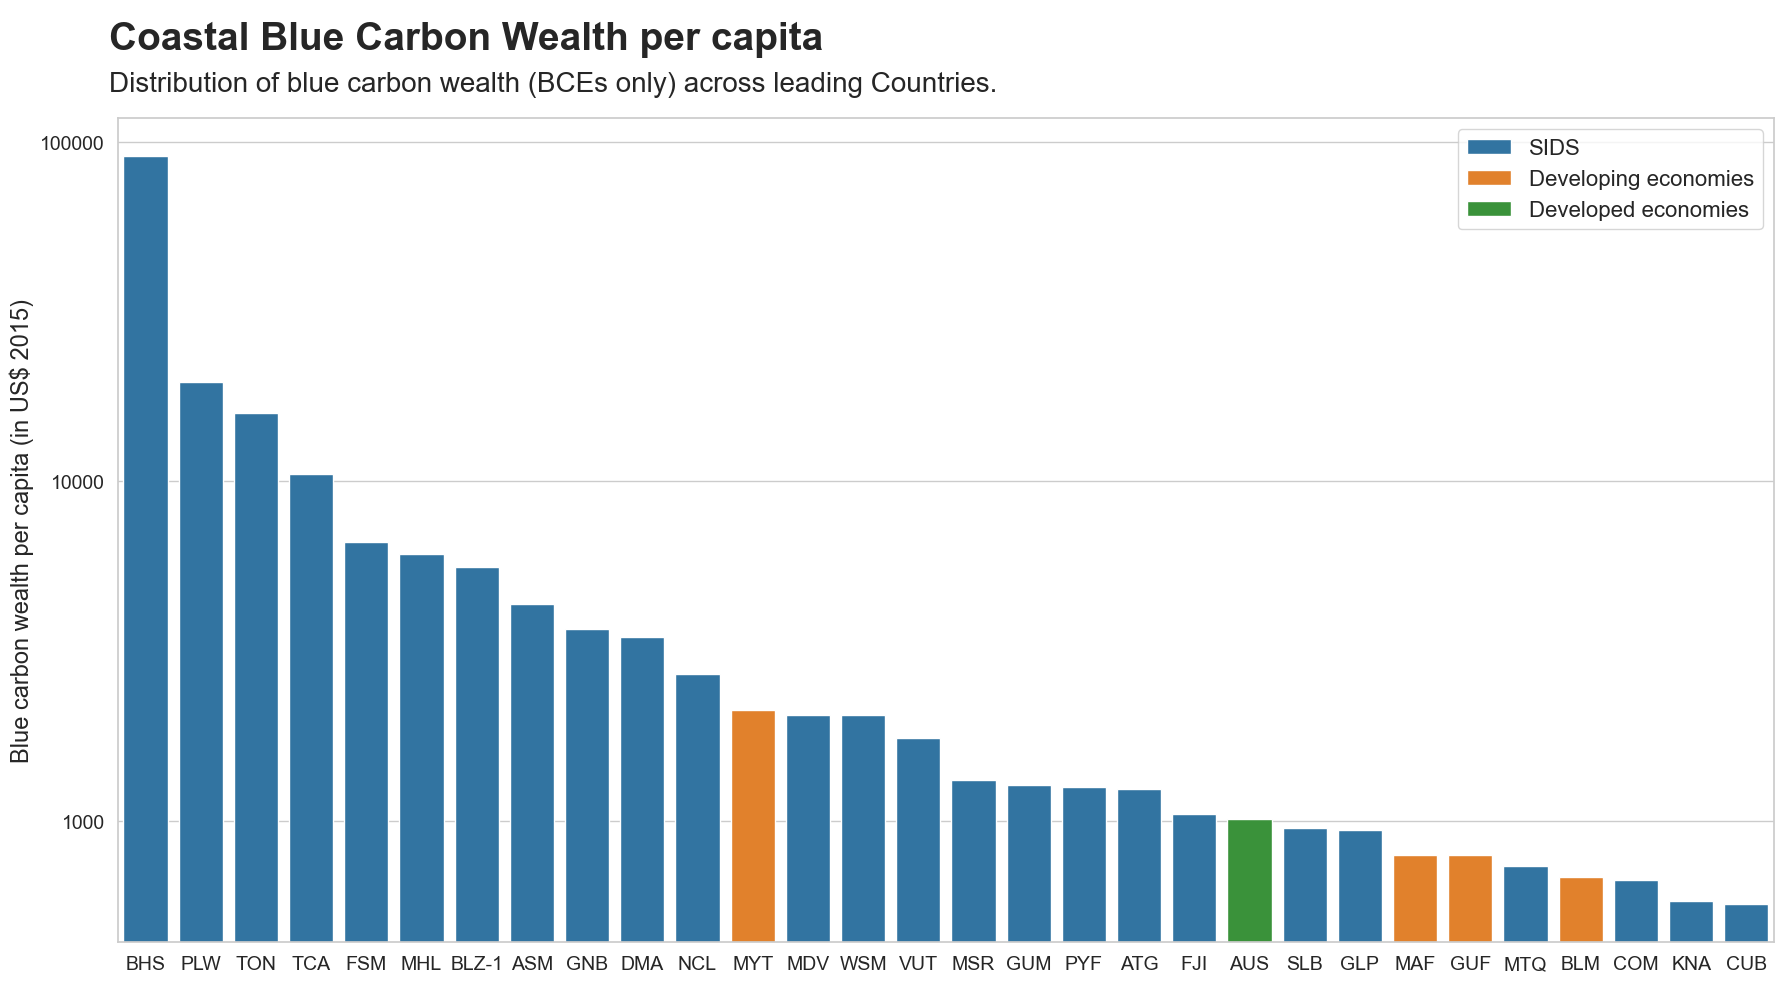

In [78]:
fig, ax = plt.subplots(figsize=(18, 10))
sns.set_theme(style='whitegrid')
sns.barplot(by_country.head(30), x='ISO', y='cBCW_per_capita', palette= 'tab10', hue='Groups',ax=ax)
fig.text(0.065, 0.97, 'Coastal Blue Carbon Wealth per capita', 
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.065, 0.92, 'Distribution of blue carbon wealth (BCEs only) across leading Countries.', 
         fontsize=20, va='top', ha='left')
plt.title('d', color='white', pad=70)
plt.ylabel('Blue carbon wealth per capita (in US$ 2015)', fontsize=17)
plt.xlabel('', fontsize=14)
ax.set_yscale("log")
format_log_axis_plain('y')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.legend(fontsize=16)
plt.show()

In [79]:
color_mapping = GROUPS_COLORMAP

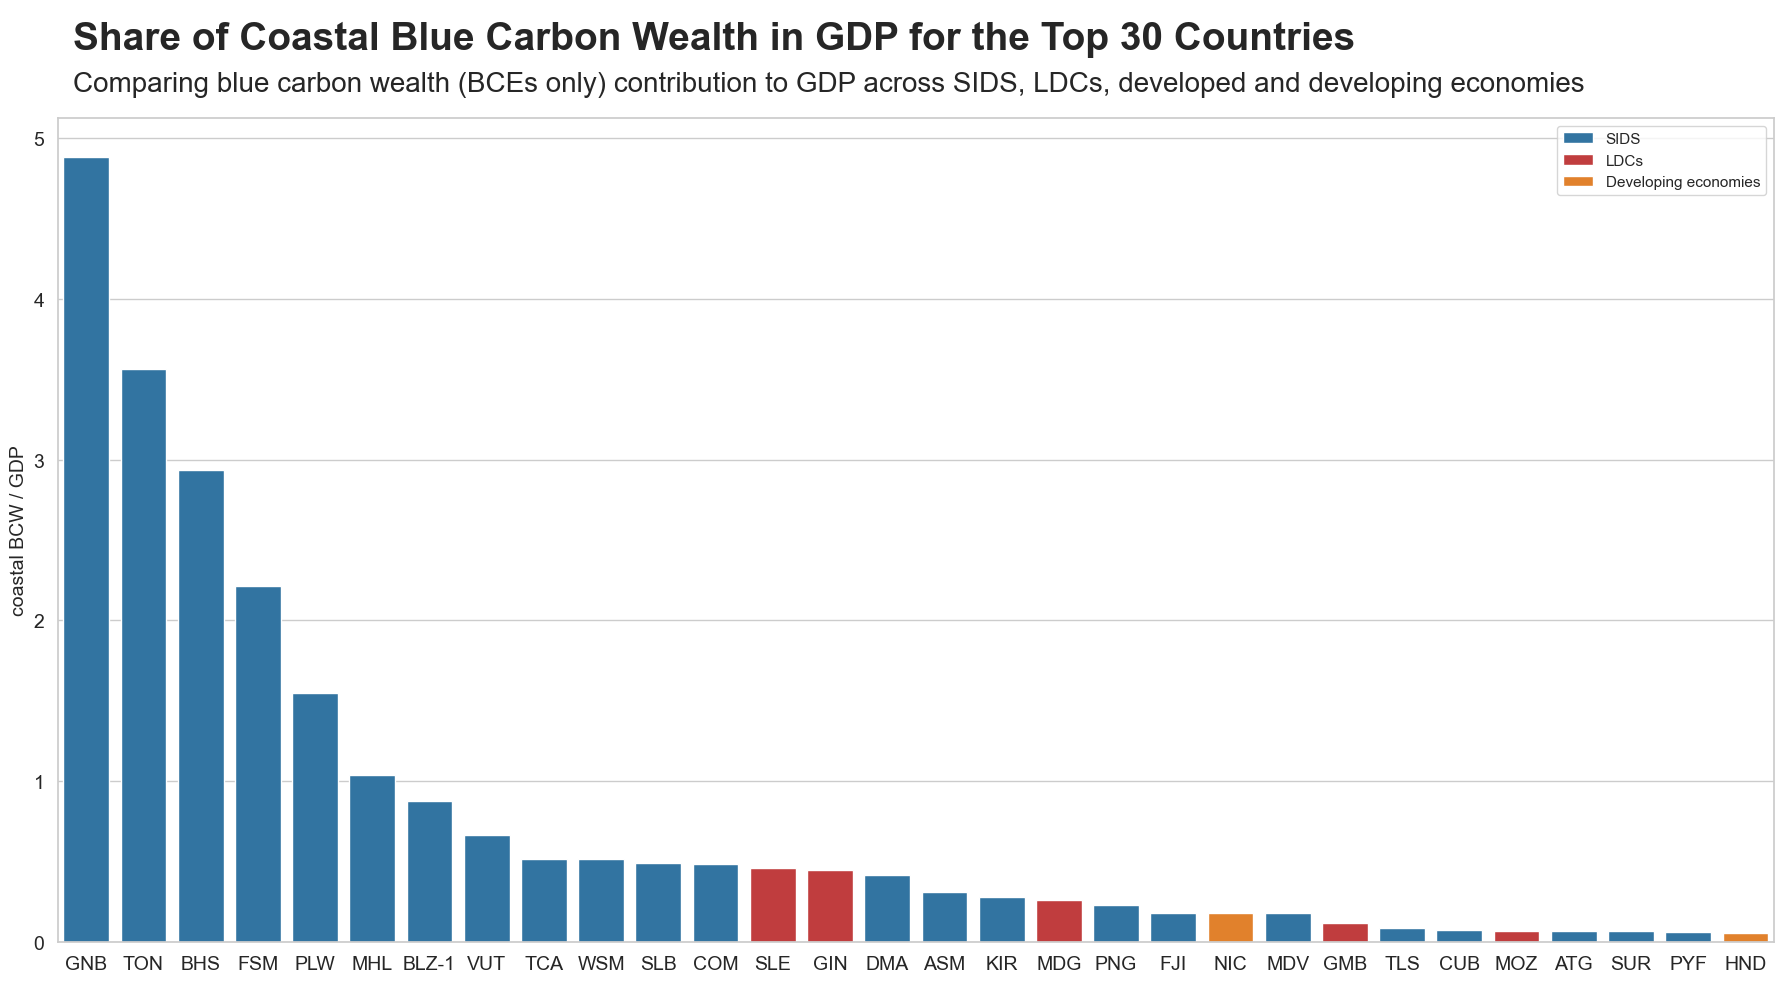

In [80]:
by_bg = df[['ISO', 'Groups', 'cBCW', 'GDP']]
by_bg['BCW_to_GDP_ratio'] = by_bg['cBCW'] / by_bg['GDP']
by_bg['BCW_to_GDP_ratio'] = by_bg['BCW_to_GDP_ratio'].replace([np.inf, -np.inf], np.nan)  # Replace inf with NaN
by_bg = by_bg.sort_values(by='BCW_to_GDP_ratio', ascending=False).head(30)
palette = by_bg['Groups'].map(color_mapping)

fig, ax = plt.subplots(figsize=(18, 10))
sns.set_theme(style='whitegrid')
sns.barplot(by_bg, x='ISO', y='BCW_to_GDP_ratio', palette= color_mapping, hue='Groups',ax=ax)
fig.text(0.045, 0.97, 'Share of Coastal Blue Carbon Wealth in GDP for the Top 30 Countries', 
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.045, 0.92, 'Comparing blue carbon wealth (BCEs only) contribution to GDP across SIDS, LDCs, developed and developing economies', 
         fontsize=20, va='top', ha='left')
plt.title('d', color='white', pad=70)
plt.ylabel('coastal BCW / GDP', fontsize=14)
plt.xlabel('')
plt.tick_params(axis='both', which='major', labelsize=14)
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend()
plt.show()

### BCP Wealth per Capita (Top 30)

In [81]:
by_country = data[['ISO', 'country_name', 'oBCW_per_capita', 'Groups']]
by_country = by_country.sort_values(by='oBCW_per_capita', ascending=False)

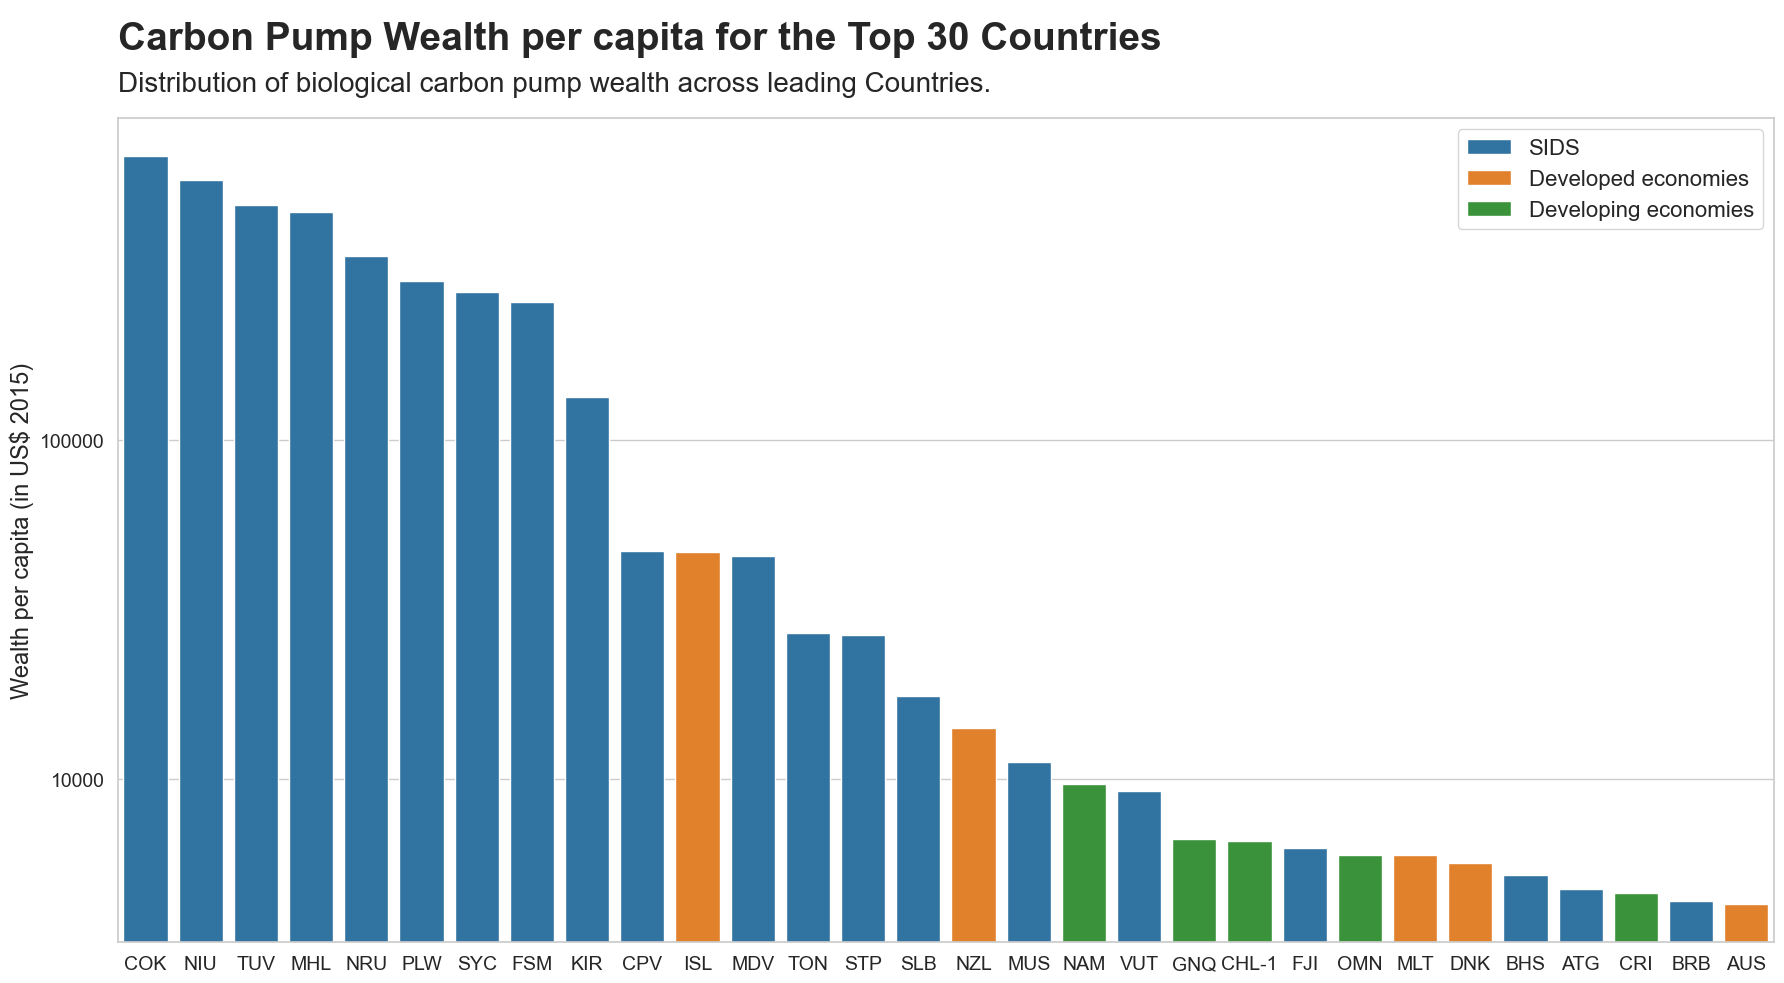

In [82]:
fig, ax = plt.subplots(figsize=(18, 10))
sns.set_theme(style='whitegrid')
sns.barplot(by_country.head(30), x='ISO', y='oBCW_per_capita', palette= 'tab10', hue='Groups',ax=ax)
fig.text(0.07, 0.97, 'Carbon Pump Wealth per capita for the Top 30 Countries', 
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.07, 0.92, 'Distribution of biological carbon pump wealth across leading Countries.', 
         fontsize=20, va='top', ha='left')
plt.title('d', color='white', pad=70)
plt.ylabel('Wealth per capita (in US$ 2015)', fontsize=17)
plt.xlabel('', fontsize=14)
ax.set_yscale("log")
format_log_axis_plain('y')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.legend(fontsize=16)
plt.show()

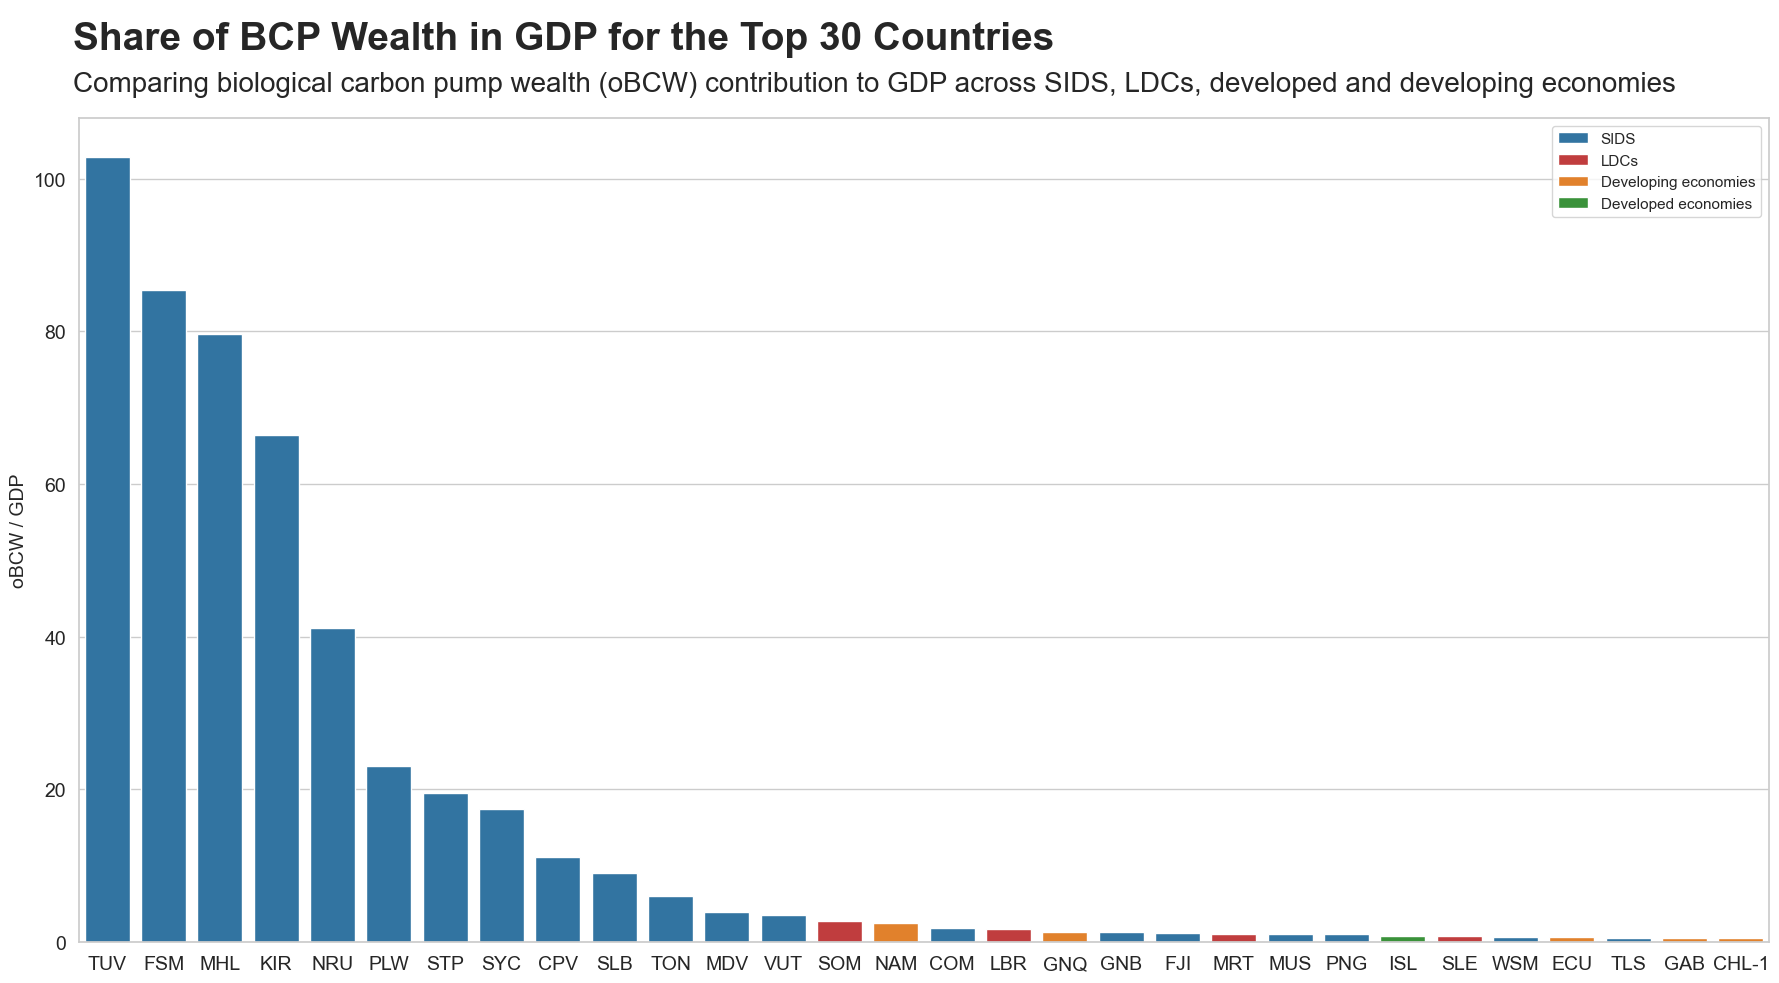

In [83]:
by_bg = df[['ISO', 'Groups', 'oBCW', 'GDP']]
by_bg['oBCW to GDP ratio'] = by_bg['oBCW'] / by_bg['GDP']
by_bg['oBCW to GDP ratio'] = by_bg['oBCW to GDP ratio'].replace([np.inf, -np.inf], np.nan)
by_bg = by_bg.sort_values(by='oBCW to GDP ratio', ascending=False).head(30)
palette = by_bg['Groups'].map(color_mapping)

fig, ax = plt.subplots(figsize=(18, 10))
sns.set_theme(style='whitegrid')
sns.barplot(by_bg, x='ISO', y='oBCW to GDP ratio', palette=color_mapping, hue='Groups', ax=ax)
fig.text(0.045, 0.97, 'Share of BCP Wealth in GDP for the Top 30 Countries',
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.045, 0.92, 'Comparing biological carbon pump wealth (oBCW) contribution to GDP across SIDS, LDCs, developed and developing economies',
         fontsize=20, va='top', ha='left')
plt.title('d', color='white', pad=70)
plt.ylabel('oBCW / GDP', fontsize=14)
plt.xlabel('')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.legend()
plt.show()


### Total BCW per Capita (Top 30)

In [84]:
by_country = df[['ISO', 'country_name', 'Total BCW_per_capita', 'Groups']]
by_country = by_country.sort_values(by='Total BCW_per_capita', ascending=False)

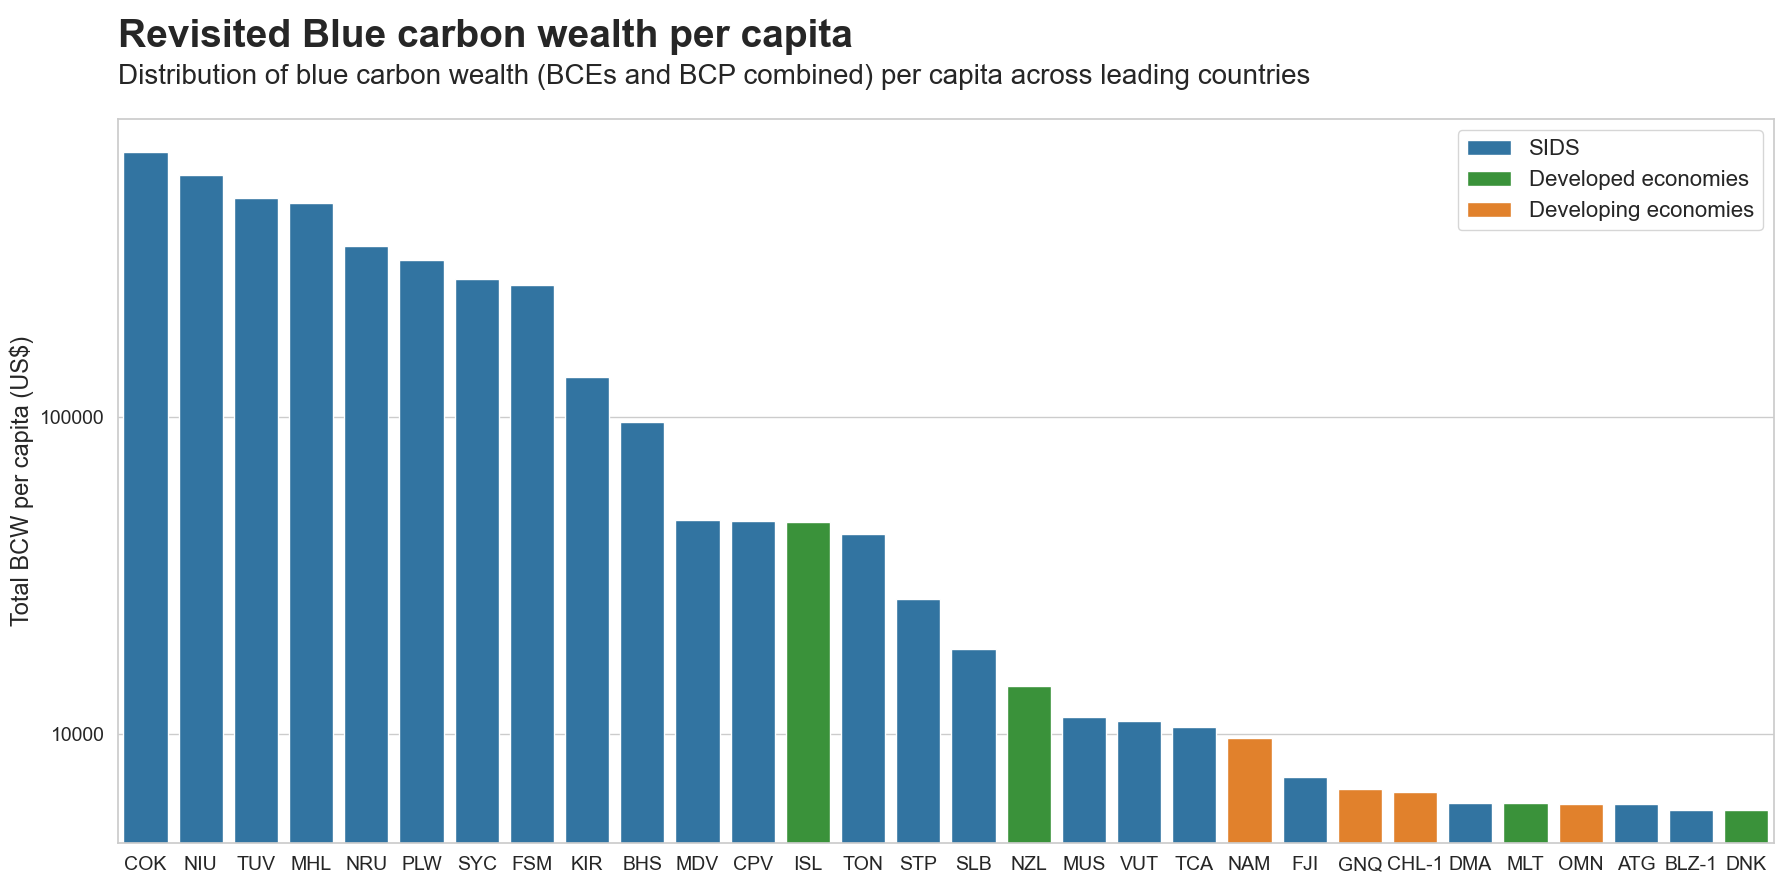

In [85]:
fig, ax = plt.subplots(figsize=(18, 9))
sns.set_theme(style='whitegrid')
sns.barplot(by_country.head(30), x='ISO', y='Total BCW_per_capita', palette= color_mapping, hue='Groups',ax=ax)
fig.text(0.07, 0.97, 'Revisited Blue carbon wealth per capita', 
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.07, 0.92, 'Distribution of blue carbon wealth (BCEs and BCP combined) per capita across leading countries',
         fontsize=20, va='top', ha='left')
plt.title('d', color='white', pad=70)
plt.ylabel('Total BCW per capita (US$)', fontsize=17)
plt.xlabel('')
plt.xticks(fontsize=17)
ax.set_yscale("log")
format_log_axis_plain('y')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.legend(fontsize=16)
plt.show()

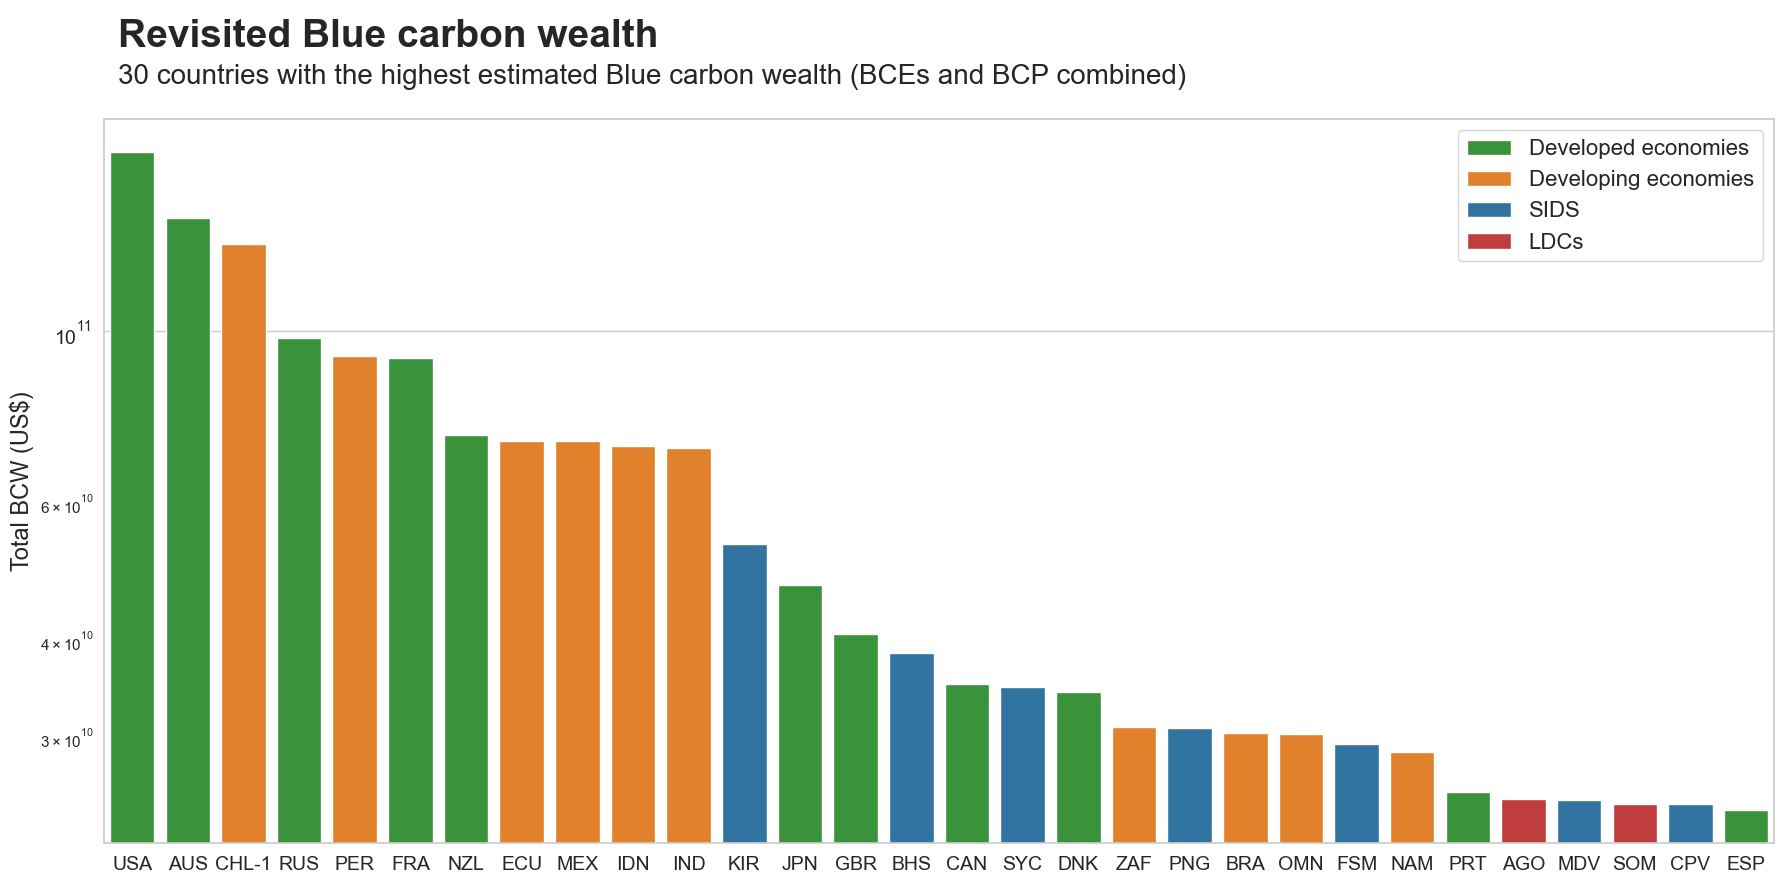

In [86]:
by_country = df[['ISO', 'Total BCW', 'Groups']]
by_country = by_country.sort_values(by='Total BCW', ascending=False)

fig, ax = plt.subplots(figsize=(18, 9))
sns.set_theme(style='whitegrid')
sns.barplot(by_country.head(30), x='ISO', y='Total BCW', palette= color_mapping, hue='Groups',ax=ax)
fig.text(0.07, 0.97, 'Revisited Blue carbon wealth', 
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.07, 0.92, '30 countries with the highest estimated Blue carbon wealth (BCEs and BCP combined)',
         fontsize=20, va='top', ha='left')
plt.title('d', color='white', pad=70)
plt.ylabel('Total BCW (US$)', fontsize=17)
plt.xlabel('')
plt.xticks(fontsize=17)
ax.set_yscale("log")
# format_log_axis_plain('y')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.legend(fontsize=16)
plt.show()

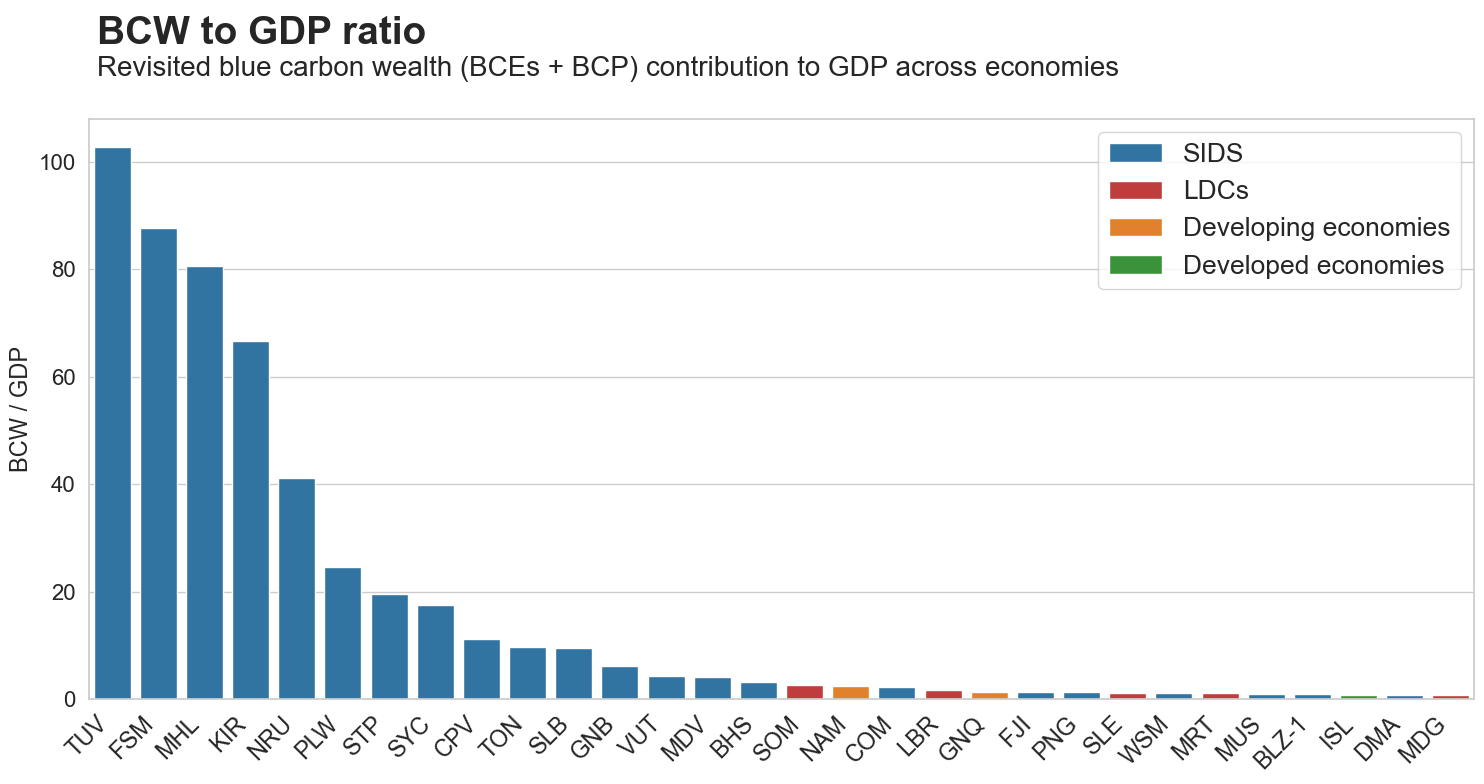

In [87]:
# paper7
by_bg = df[['ISO', 'Groups', 'Total BCW', 'GDP']]
by_bg['Total BCW to GDP ratio'] = by_bg['Total BCW'] / by_bg['GDP']
by_bg['Total BCW to GDP ratio'] = by_bg['Total BCW to GDP ratio'].replace([np.inf, -np.inf], np.nan)  # Replace inf with NaN
by_bg = by_bg.sort_values(by='Total BCW to GDP ratio', ascending=False).head(30)
palette = by_bg['Groups'].map(color_mapping)

fig, ax = plt.subplots(figsize=(15, 8))
sns.set_theme(style='whitegrid')
sns.barplot(by_bg, x='ISO', y='Total BCW to GDP ratio', palette= color_mapping, hue='Groups',ax=ax)
fig.text(0.07, 0.97, 'BCW to GDP ratio', 
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.07, 0.92, 'Revisited blue carbon wealth (BCEs + BCP) contribution to GDP across economies', 
         fontsize=20, va='top', ha='left')
plt.title('d', color='white', pad=70)
plt.ylabel('BCW / GDP', fontsize=17)
# plt.yscale("log")
# format_log_axis_plain('y')
plt.xlabel('')
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xticks(rotation=45, ha='right', fontsize=17)
plt.tight_layout()
plt.legend(fontsize=19)
plt.show()

In [88]:
print("\nAverage BCW to GDP ratio by group:")
by_bg.groupby('Groups')['Total BCW to GDP ratio'].mean()


Average BCW to GDP ratio by group:


Groups
Developed economies     0.7863
Developing economies    1.8794
LDCs                    1.4755
SIDS                   22.5844
Name: Total BCW to GDP ratio, dtype: float64

### EEZ per Capita

In [89]:
by_eez = df[['country_name','ISO', 'Groups', 'Area_EEZ_KM2', 'Population']]
by_eez['Area_EEZ_KM2_per_capita'] = by_eez['Area_EEZ_KM2'] / by_eez['Population']
by_eez_sorted = by_eez.sort_values(by='Area_EEZ_KM2_per_capita', ascending=False)
top_30_eez = by_eez_sorted.head(30)

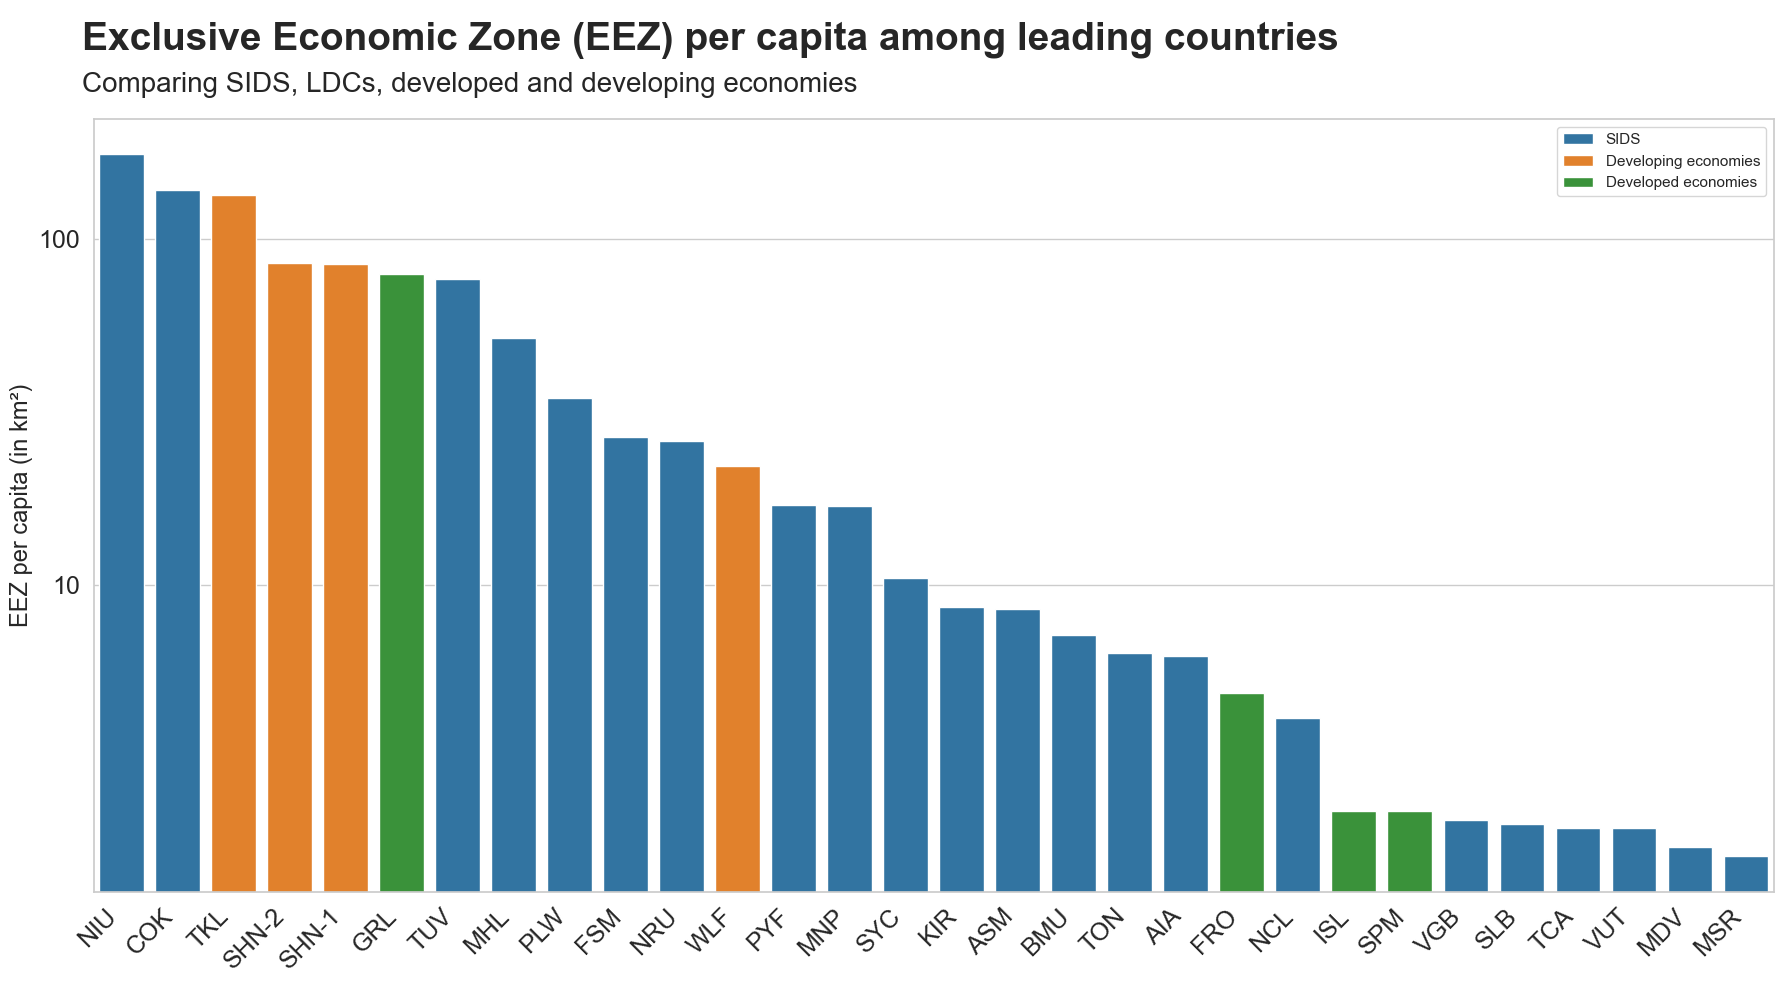

In [90]:
# paper1
fig, ax = plt.subplots(figsize=(18, 10))
sns.set_theme(style='whitegrid')
sns.barplot(top_30_eez, x='ISO', y='Area_EEZ_KM2_per_capita', palette= 'tab10', ci=False, hue='Groups',ax=ax)
fig.text(0.05, 0.97, 'Exclusive Economic Zone (EEZ) per capita among leading countries', 
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.05, 0.92, 'Comparing SIDS, LDCs, developed and developing economies', 
         fontsize=20, va='top', ha='left')

# fig.text(0.045, 0, 'Note: The suffixes added to ISO codes, such as SHN-1, SHN-2, SHN-3 for Saint Helena, Ascension, and Tristan Da Cunha, and KIR-1 for the Gilbert Islands, KIR-2 for the Phoenix Islands, and KIR-3 for the Line Islands of Kiribati, are used to differentiate these territories under the same ISO designation.', 
#          fontsize=18, va='top', ha='left', wrap=True)

plt.title('d', color='white', pad=70)
plt.ylabel('EEZ per capita (in km²)', fontsize=17)
plt.xlabel('')
ax.set_yscale("log")
format_log_axis_plain('y')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xticks(rotation=45, ha='right', fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.legend()
plt.show()

## Choropleth Maps — BCW per Capita

World maps showing per-capita blue carbon wealth by country.

### Coastal BCW per Capita

In [91]:
plot_data['cBCW_per_capita'] = plot_data['cBCW'] / plot_data['Population']
plot_data['oBCW_per_capita'] = plot_data['oBCW'] / plot_data['Population']

by_country = plot_data[['ISO', 'cBCW_per_capita', 'Groups']]
by_country = by_country.sort_values(by='cBCW_per_capita', ascending=False)
by_country['cat'] = by_country['cBCW_per_capita'].apply(categorize_bcw_pcap)


### Coastal BCW per Capita (map + bar chart)

In [92]:
# print(sns.color_palette("ch:start=.2,rot=-.3", n_colors=4)[::-1])
hex_col = ['#27203f', '#51618f', '#7da6c0', '#c2e2e2']
list_col = hex_col[::-1]

In [93]:
# from matplotlib.colors import rgb2hex

# hex_palette = [rgb2hex(c) for c in palette][::-1]

# ['#27213f', '#3e406b', '#52628f', '#6685ab', '#7da7c0', '#9cc7d1', '#c3e2e3']

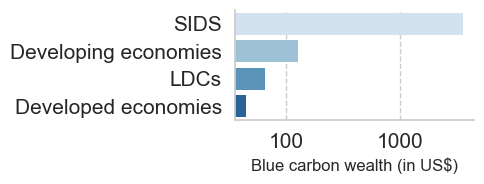

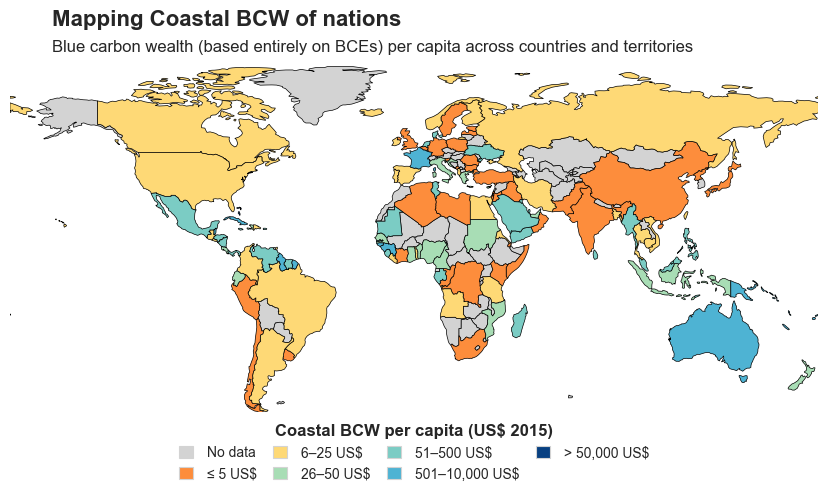

In [94]:
# paper4
mb_data = plot_data.copy()
mb_data.rename(columns={'cBCW_per_capita': 'Coastal BCW per capita (US$ 2015)'}, inplace=True)

hex_col2 = ['#27203f', '#51618f', '#7da6c0', '#a3c8d6', '#c2e2e2']
colors_hex = [
    "#e31a1c",  # Over 80%
    "#fd8d3c",  # 70-80%
    "#fed976",  # 60-70%
    "#f7fcb9",  # 50-60%
    "#ccebc5",  # 50%
    "#a8ddb5",  # 40-50%
    "#7bccc4",  # 30-40%
    "#4eb3d3",  # 20-30%
    "#2b8cbe",  # 10-20%
    "#0868ac",  # 0%-10%
    "#084081",  # 0%
]
colors_hex_6 = [
    "#ccebc5",  # vert très pâle (presque neutre, pour la transition)
    "#a8ddb5",  # vert-bleu clair
    "#7bccc4",  # bleu turquoise clair
    "#4eb3d3",  # bleu clair
    "#2b8cbe",  # bleu moyen
    "#084081",  # bleu foncé
]
hex_col2 = ['#27213f', '#3e406b', '#6685ab', '#7da7c0', '#9cc7d1', '#e6f2f2']
list_col2 = hex_col2[::-1]
colors_hex_6 = [
    "#fd8d3c",  # orange
    "#fed976",  # jaune
    "#a8ddb5",  # vert-bleu clair
    "#7bccc4",  # bleu turquoise clair
    "#4eb3d3",  # bleu clair
    "#2b8cbe",  # bleu moyen
    "#084081",  # bleu foncé
]
map_and_barplot(
    df=mb_data,
    var='Coastal BCW per capita (US$ 2015)',
    group_col='Groups',
    units='US$',
    thresholds=[-1, 5, 25, 50, 500, 10000, 50000],
    mapping=mapping,
    # colors=list_col2,
    colors=colors_hex_6,
    title='Mapping Coastal BCW of nations',
    subtitle='Blue carbon wealth (based entirely on BCEs) per capita across countries and territories',
    xlabel_bar='Blue carbon wealth (in US$)',
    fig_size_map=(10, 6),
    legend_bbox=(0.5, -0.25),
    legend_ncol=4,
    fig_size_bar=(5, 2),
    cmap_palette='Blues',
    wld=world
)

### Total BCW per Capita

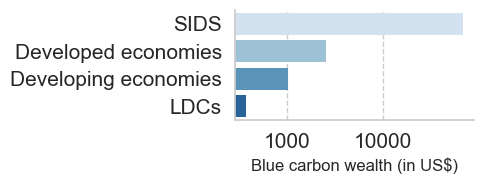

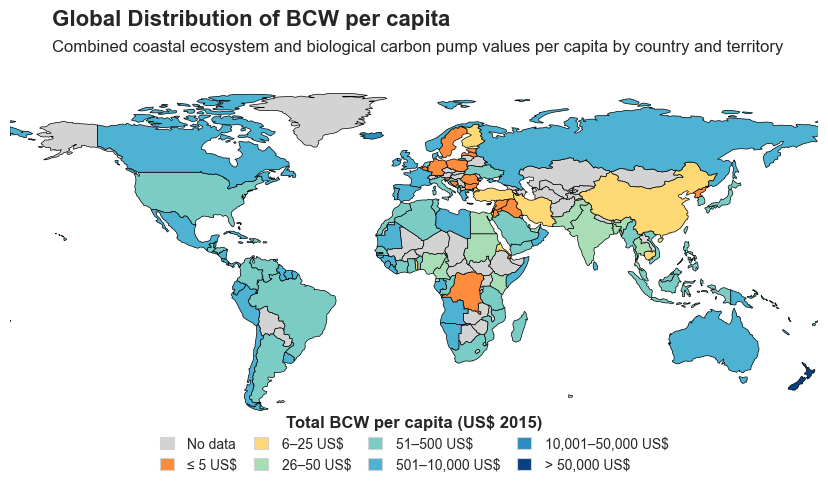

In [95]:
# paper4
mb_data.rename(columns={'Total BCW_per_capita': 'Total BCW per capita (US$ 2015)'}, inplace=True)
# ['#c2e2e2', '#8bb6c9', '#6585ab', '#48507e', '#27203f', '#0a0a18'] # old col_list
map_and_barplot(
    df=mb_data,
    var='Total BCW per capita (US$ 2015)',
    group_col='Groups',
    units='US$',
    thresholds=[-1, 5, 25, 50, 500, 10000, 50000],
    mapping=mapping,
    # colors=list_col2,
    colors=colors_hex_6,
    title='Global Distribution of BCW per capita',
    subtitle='Combined coastal ecosystem and biological carbon pump values per capita by country and territory',
    xlabel_bar='Blue carbon wealth (in US$)',
    fig_size_map=(10, 6),
    legend_bbox=(0.5, -0.25),
    legend_ncol=4,
    fig_size_bar=(5, 2),
    cmap_palette='Blues',
    wld=world
)

## Continental and Group Analysis

Aggregate BCW per capita by continent and economic group. Wind rose charts for top countries per continent.

### By Continent

In [96]:
# supl2
continent = df.groupby('Continent')[['cBCW', 'oBCW', 'Total BCW', 'Population']].sum().reset_index()
continent['cBCW_per_capita'] = continent['cBCW'] / continent['Population']
continent['oBCW_per_capita'] = continent['oBCW'] / continent['Population']
continent['Total BCW_per_capita'] = continent['Total BCW'] / continent['Population']
continent.rename(columns={
    'oBCW': 'PCW', 'oBCW_per_capita': 'PCW_PCAP'
    }).to_csv('continent_summary.csv', index=False, float_format='%.6f')
continent.head()

,Continent,cBCW,oBCW,Total BCW,Population,cBCW_per_capita,oBCW_per_capita,Total BCW_per_capita
0,Africa,"43,107,834,064.2969","323,200,300,000.0000","366,308,127,572.0469","1,479,900,930.0000",29.1289,218.3932,247.5221
1,Americas,"34,580,563,750.5703","674,221,839,644.0000","708,802,367,980.0703","1,017,200,349.0000",33.9958,662.8211,696.8169
2,Asia,"53,818,429,353.6875","315,027,553,629.9362","368,845,993,287.3750","4,769,847,844.0000",11.2830,66.0456,77.3287
3,Caribbean,"45,701,131,562.9219","12,472,102,310.0000","58,173,234,921.6406","44,309,064.0000","1,031.4172",281.4797,"1,312.8969"
4,Europe,"10,668,659,308.3359","399,161,047,767.5210","409,829,716,252.8398","743,902,347.0000",14.3415,536.5772,550.9187


In [97]:
pal = CONTINENT_PAL


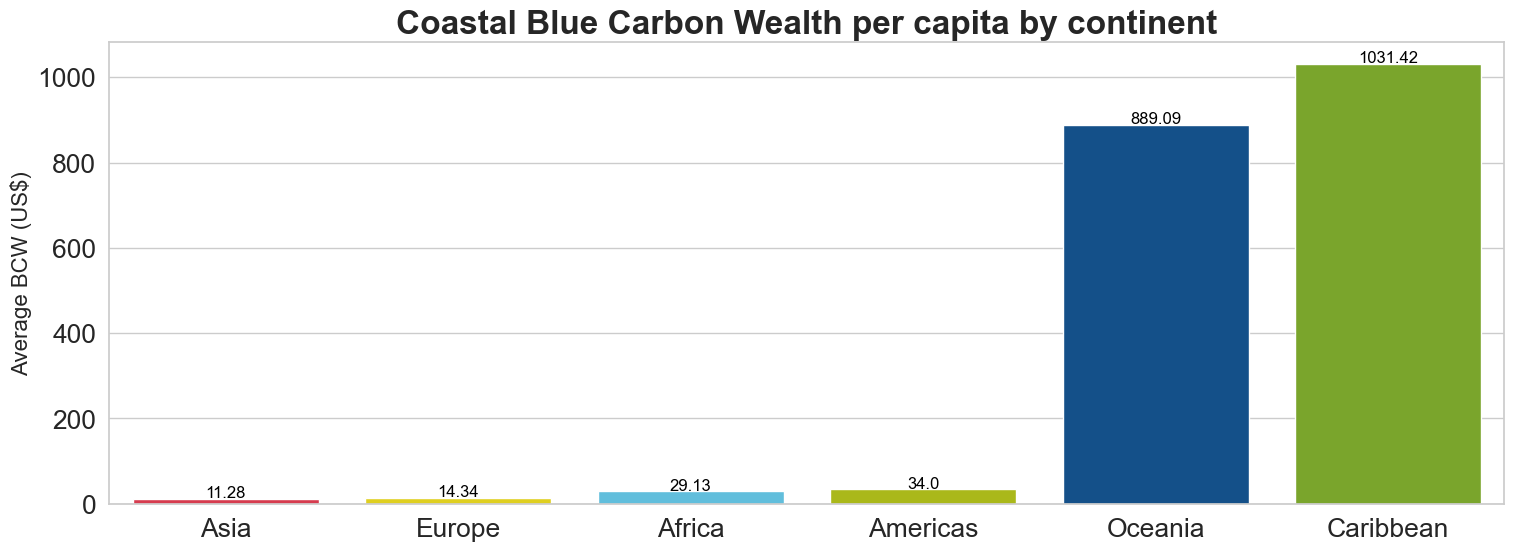

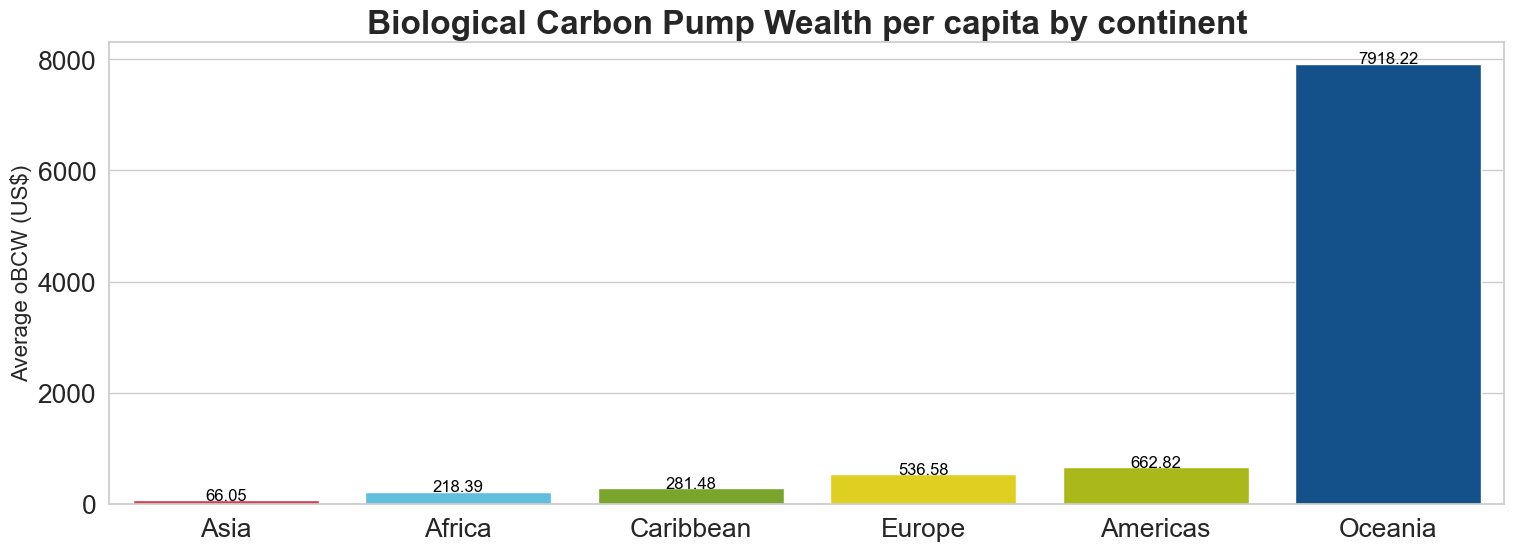

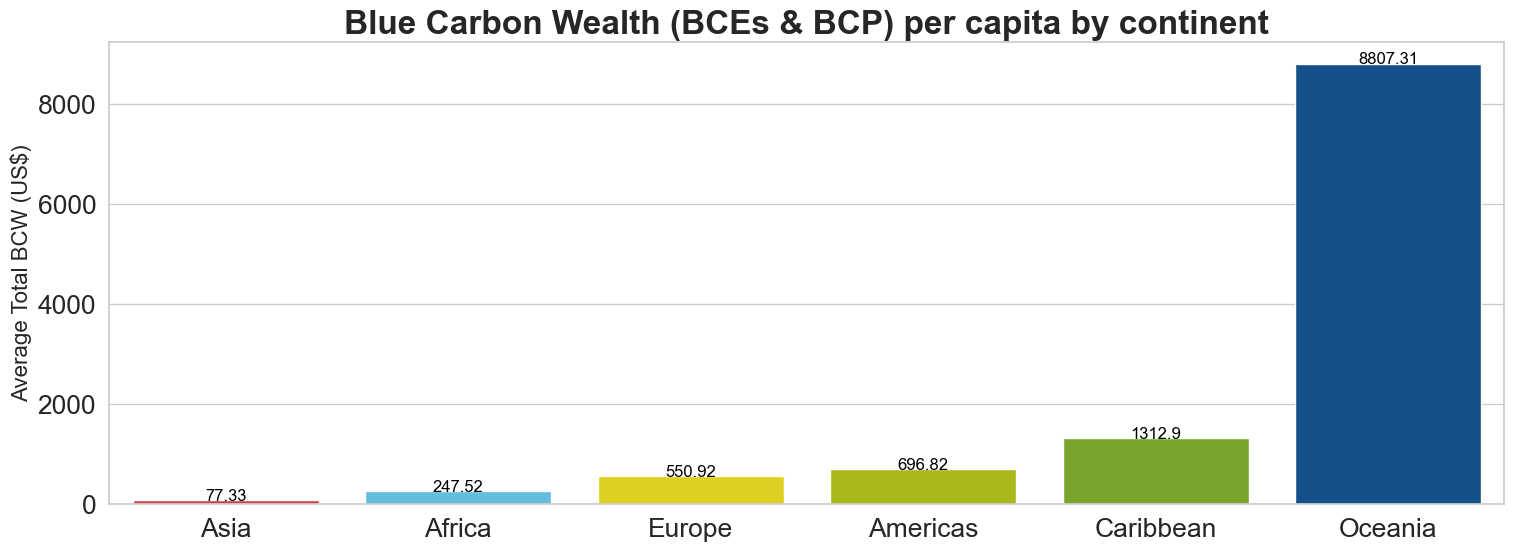

In [98]:
# supl5
varlist = ['cBCW_per_capita', 'oBCW_per_capita', 'Total BCW_per_capita']
titles = ['Coastal Blue Carbon Wealth per capita by continent',
          'Biological Carbon Pump Wealth per capita by continent',
          'Blue Carbon Wealth (BCEs & BCP) per capita by continent']
ylabels = ['Average BCW (US$)',
           'Average oBCW (US$)',
              'Average Total BCW (US$)']
for var, title, ylabel in zip(varlist, titles, ylabels):
    cdf = continent.copy()
    cdf.sort_values(by=var, inplace=True)
    plt.figure(figsize=(18, 6))
    sns.set_theme(style="whitegrid")
    sns.barplot(cdf, x='Continent', y=var, ci=False, palette=pal)
    plt.title(title, fontweight='bold',
            fontsize=24)
    plt.xlabel('')
    for i, v in enumerate(cdf[var]):
        plt.text(
            i, v + 3, str(round(v, 2)), 
            color='black', ha='center'
        )
    plt.tick_params(axis='both', which='major', labelsize=19)
    plt.ylabel(ylabel, fontsize=16)
    plt.show()

In [99]:
cont = continent.copy()
varlits = ['cBCW', 'oBCW', 'Total BCW']
varlist = ['cBCW_per_capita', 'oBCW_per_capita', 'Total BCW_per_capita']
for var, tot in zip(varlist, varlits):
    tota = cont[tot].sum()
    cont[f'prop_{tot}'] = round((cont[tot]/tota) * 100, 2).astype(str) + '%'
    cont[f'prop_{tot}'] = cont[f'prop_{tot}'].astype(str)
    cont['Continent'] =cont['Continent'].astype('object')
    cont[f'Estimated_{var}'] = cont['Continent'] + ' (' + cont[var].round(2).astype(str) + ' US$ on avg.)'
cont = cont.drop(columns=varlist + varlits)
cont

,Continent,Population,prop_cBCW,Estimated_cBCW_per_capita,prop_oBCW,Estimated_oBCW_per_capita,prop_Total BCW,Estimated_Total BCW_per_capita
0,Africa,"1,479,900,930.0000",18.86%,Africa (29.13 US$ on avg.),15.49%,Africa (218.39 US$ on avg.),15.82%,Africa (247.52 US$ on avg.)
1,Americas,"1,017,200,349.0000",15.13%,Americas (34.0 US$ on avg.),32.31%,Americas (662.82 US$ on avg.),30.61%,Americas (696.82 US$ on avg.)
2,Asia,"4,769,847,844.0000",23.54%,Asia (11.28 US$ on avg.),15.1%,Asia (66.05 US$ on avg.),15.93%,Asia (77.33 US$ on avg.)
3,Caribbean,"44,309,064.0000",19.99%,Caribbean (1031.42 US$ on avg.),0.6%,Caribbean (281.48 US$ on avg.),2.51%,Caribbean (1312.9 US$ on avg.)
4,Europe,"743,902,347.0000",4.67%,Europe (14.34 US$ on avg.),19.13%,Europe (536.58 US$ on avg.),17.7%,Europe (550.92 US$ on avg.)
5,Oceania,"45,827,843.0000",17.82%,Oceania (889.09 US$ on avg.),17.39%,Oceania (7918.22 US$ on avg.),17.43%,Oceania (8807.31 US$ on avg.)


In [100]:
country_data = df[['ISO', 'country_name', 'Continent', 'cBCW_per_capita', 'oBCW_per_capita', 'Total BCW_per_capita']].copy()
country_data.head()

,ISO,country_name,Continent,cBCW_per_capita,oBCW_per_capita,Total BCW_per_capita
0,AE,"Abu musa, Greater and Lesser Tunb",Asia,NaN,NaN,NaN
1,AFG,Afghanistan,Asia,NaN,NaN,NaN
2,US-AK,Alaska,Americas,NaN,NaN,NaN
3,ALB,Albania,Europe,12.7452,56.8465,69.5917
4,DZA,Algeria,Africa,0.3940,133.3349,133.7290


### By Economic Group

In [101]:
groups = df.groupby('Groups')[['cBCW', 'oBCW', 'Total BCW', 'Population']].sum().reset_index()
groups['cBCW_per_capita'] = groups['cBCW'] / groups['Population']
groups['oBCW_per_capita'] = groups['oBCW'] / groups['Population']
groups['Total BCW_per_capita'] = groups['Total BCW'] / groups['Population']
groups['Groups'] = groups['Groups'].replace({'Developed economies': 'Developed', 'Developing economies': 'Developing'})
groups.head()

,Groups,cBCW,oBCW,Total BCW,Population,cBCW_per_capita,oBCW_per_capita,Total BCW_per_capita
0,Developed,"45,377,962,613.8359","835,773,911,687.5210","881,151,857,092.8398","1,345,085,326.0000",33.7361,621.3538,655.0899
1,Developing,"81,898,418,741.0000","828,176,157,946.0000","910,074,568,414.6875","5,538,886,372.0000",14.7861,149.5203,164.3064
2,LDCs,"26,910,537,986.0000","107,346,339,600.0000","134,256,871,414.0000","1,143,856,913.0000",23.5261,93.8460,117.3721
3,SIDS,"71,639,761,928.2087","300,226,292,117.9362","371,866,049,296.8679","73,159,766.0000",979.2235,"4,103.7077","5,082.9311"


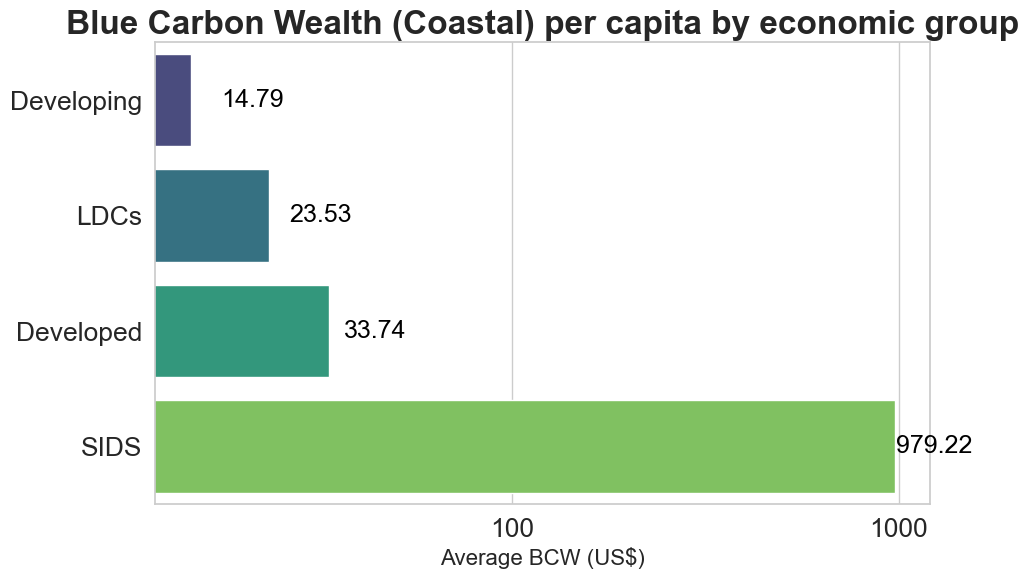

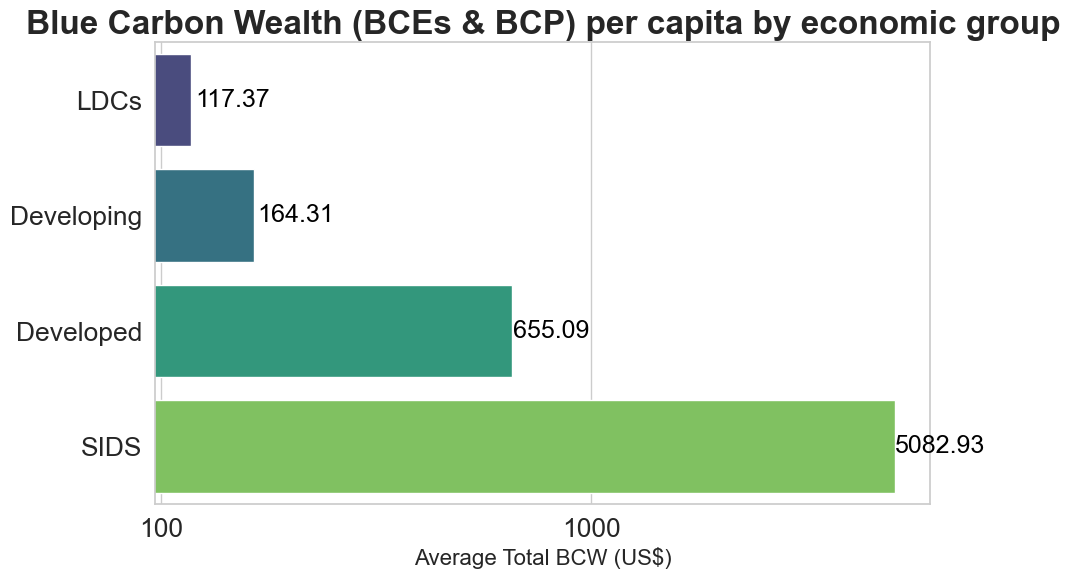

In [102]:
                # supl5
# horizontal barplot for groups
varlist = ['cBCW_per_capita', 'Total BCW_per_capita']
titles = ['Blue Carbon Wealth (Coastal) per capita by economic group',
          'Blue Carbon Wealth (BCEs & BCP) per capita by economic group']
ylabels = ['Average BCW (US$)',
           'Average Total BCW (US$)']
for var, title, ylabel in zip(varlist, titles, ylabels):
    gdf = groups.copy()
    gdf.sort_values(by=var, inplace=True)
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    sns.barplot(gdf, y='Groups', x=var, ci=False, palette='viridis')
    plt.title(title, fontweight='bold',
            fontsize=24)
    plt.ylabel('')
    for i, v in enumerate(gdf[var]):
        plt.text(
            v + 3, i, str(round(v, 2)), 
            color='black', va='center', fontsize=18
        )
    plt.xscale("log")
    format_log_axis_plain('x')
    plt.tick_params(axis='both', which='major', labelsize=19)
    plt.xlabel(ylabel, fontsize=16)
    plt.show()

In [103]:
groups = df.groupby('Groups')[['cBCW', 'oBCW', 'Total BCW', 'Population']].mean().reset_index()
groups['total bcw share %'] = groups['Total BCW'] / groups['Total BCW'].sum() * 100
groups['cBCW_per_capita'] = groups['cBCW'] / groups['Population']
groups['oBCW_per_capita'] = groups['oBCW'] / groups['Population']
groups['Total BCW_per_capita'] = groups['Total BCW'] / groups['Population']
groups['Groups'] = groups['Groups'].replace({'Developed economies': 'Developed', 'Developing economies': 'Developing'})
groups.head()

,Groups,cBCW,oBCW,Total BCW,Population,total bcw share %,cBCW_per_capita,oBCW_per_capita,Total BCW_per_capita
0,Developed,"1,226,431,421.9956","32,145,150,449.5200","22,593,637,361.3549","23,191,126.3103",45.3288,52.8837,"1,386.0970",974.2363
1,Developing,"1,388,108,792.2203","18,403,914,621.0222","14,445,628,070.0744","66,733,570.7470",28.9817,20.8008,275.7820,216.4672
2,LDCs,"1,281,454,189.8095","6,709,146,225.0000","6,393,184,353.0476","30,915,051.7027",12.8264,41.4508,217.0188,206.7984
3,SIDS,"1,302,541,125.9674","7,698,110,054.3061","6,411,483,608.5667","1,283,504.6667",12.8631,"1,014.8316","5,997.7266","4,995.2943"


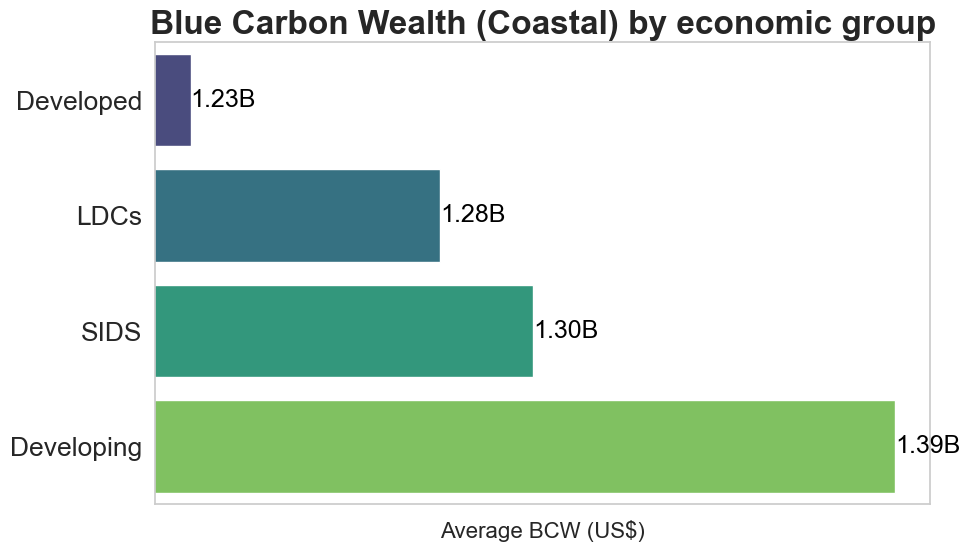

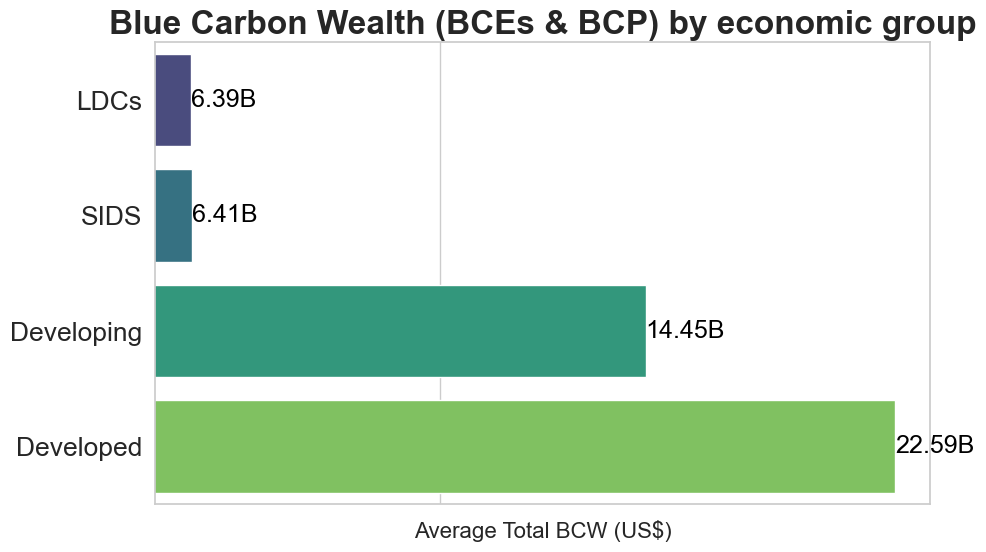

In [104]:
# supl5
# horizontal barplot for groups
varlist = ['cBCW', 'Total BCW']
titles = ['Blue Carbon Wealth (Coastal) by economic group',
          'Blue Carbon Wealth (BCEs & BCP) by economic group']
ylabels = ['Average BCW (US$)',
           'Average Total BCW (US$)']
for var, title, ylabel in zip(varlist, titles, ylabels):
    gdf = groups.copy()
    gdf.sort_values(by=var, inplace=True)
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    sns.barplot(gdf, y='Groups', x=var, ci=False, palette='viridis')
    plt.title(title, fontweight='bold',
            fontsize=24)
    plt.ylabel('')
    for i, v in enumerate(gdf[var]):
        plt.text(
            v + 3, i, f'{v/1e9:.2f}B', 
            color='black', va='center', fontsize=18
        )
    plt.xticks(visible=False)
    plt.xscale("log")
    format_log_axis_plain('x')
    plt.tick_params(axis='both', which='major', labelsize=19)
    plt.xlabel(ylabel, fontsize=16)
    plt.show()

### Wind Rose Charts

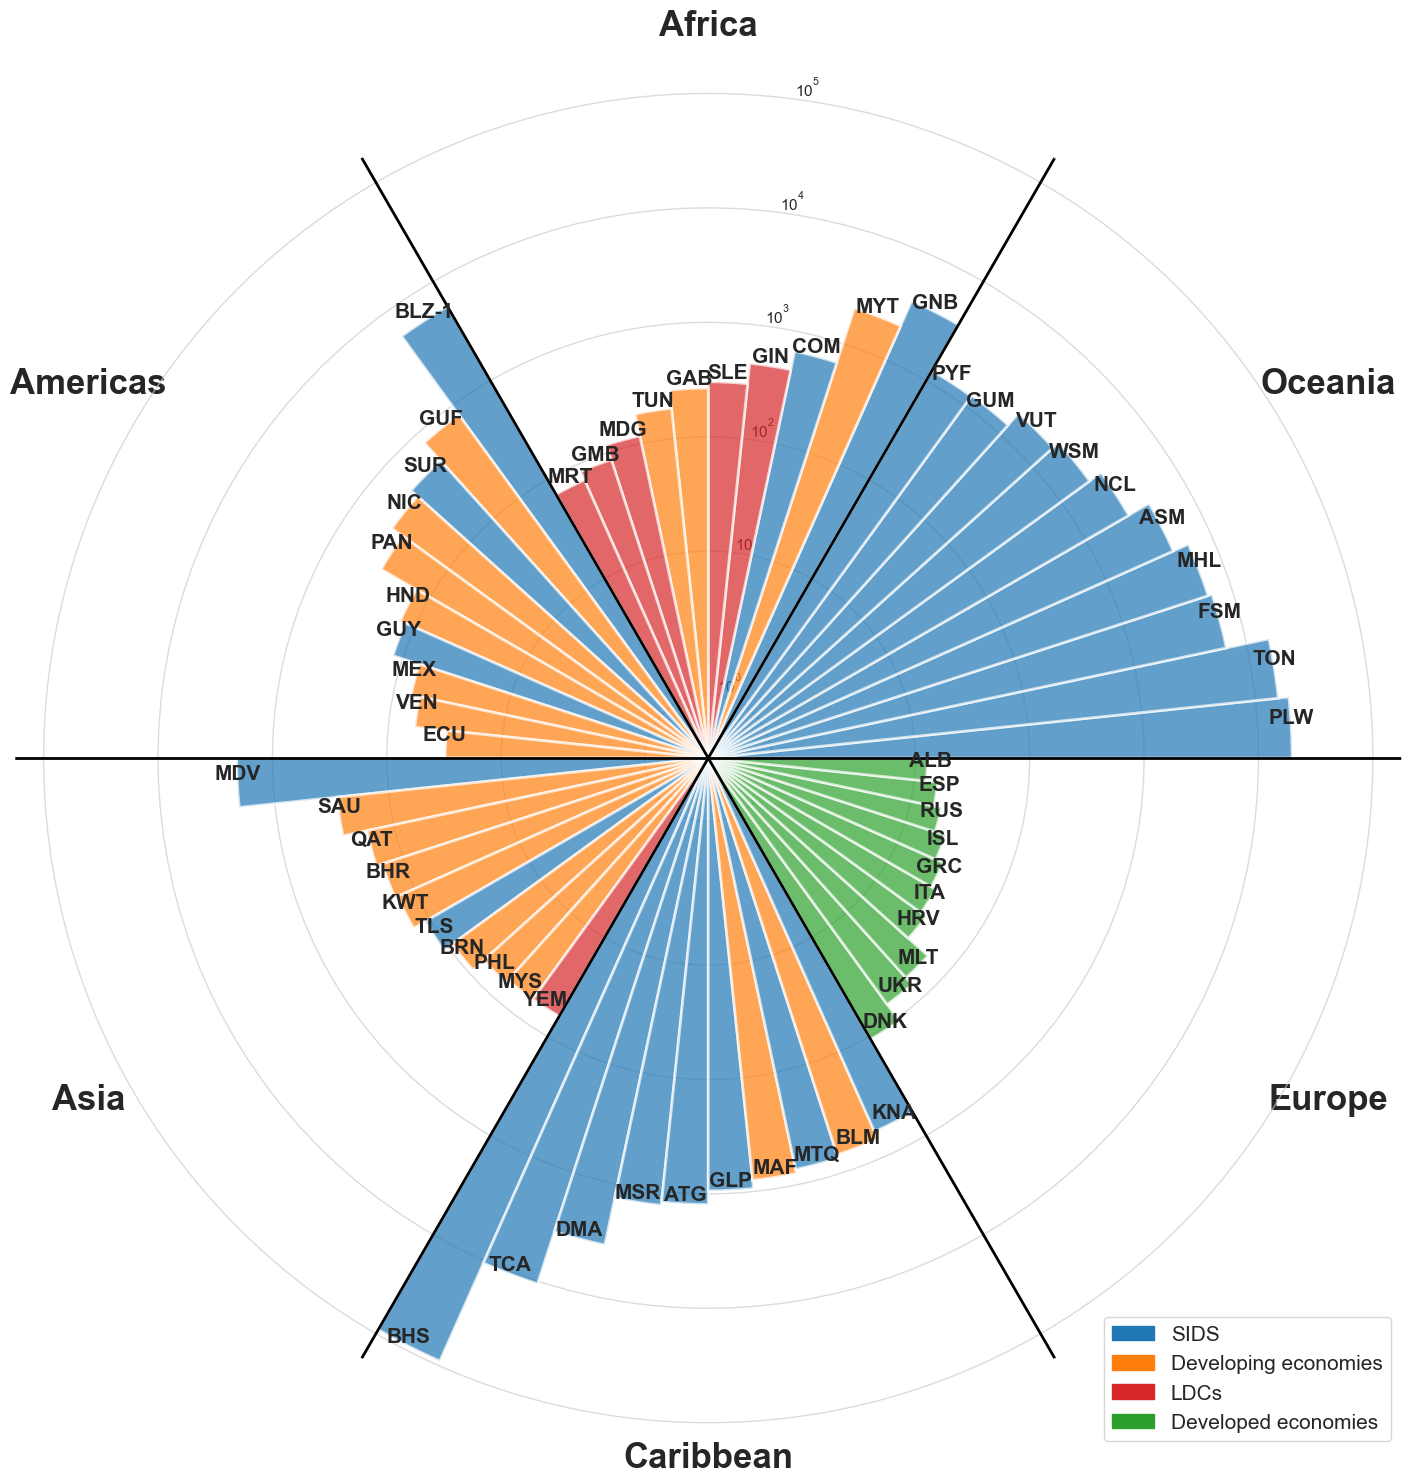

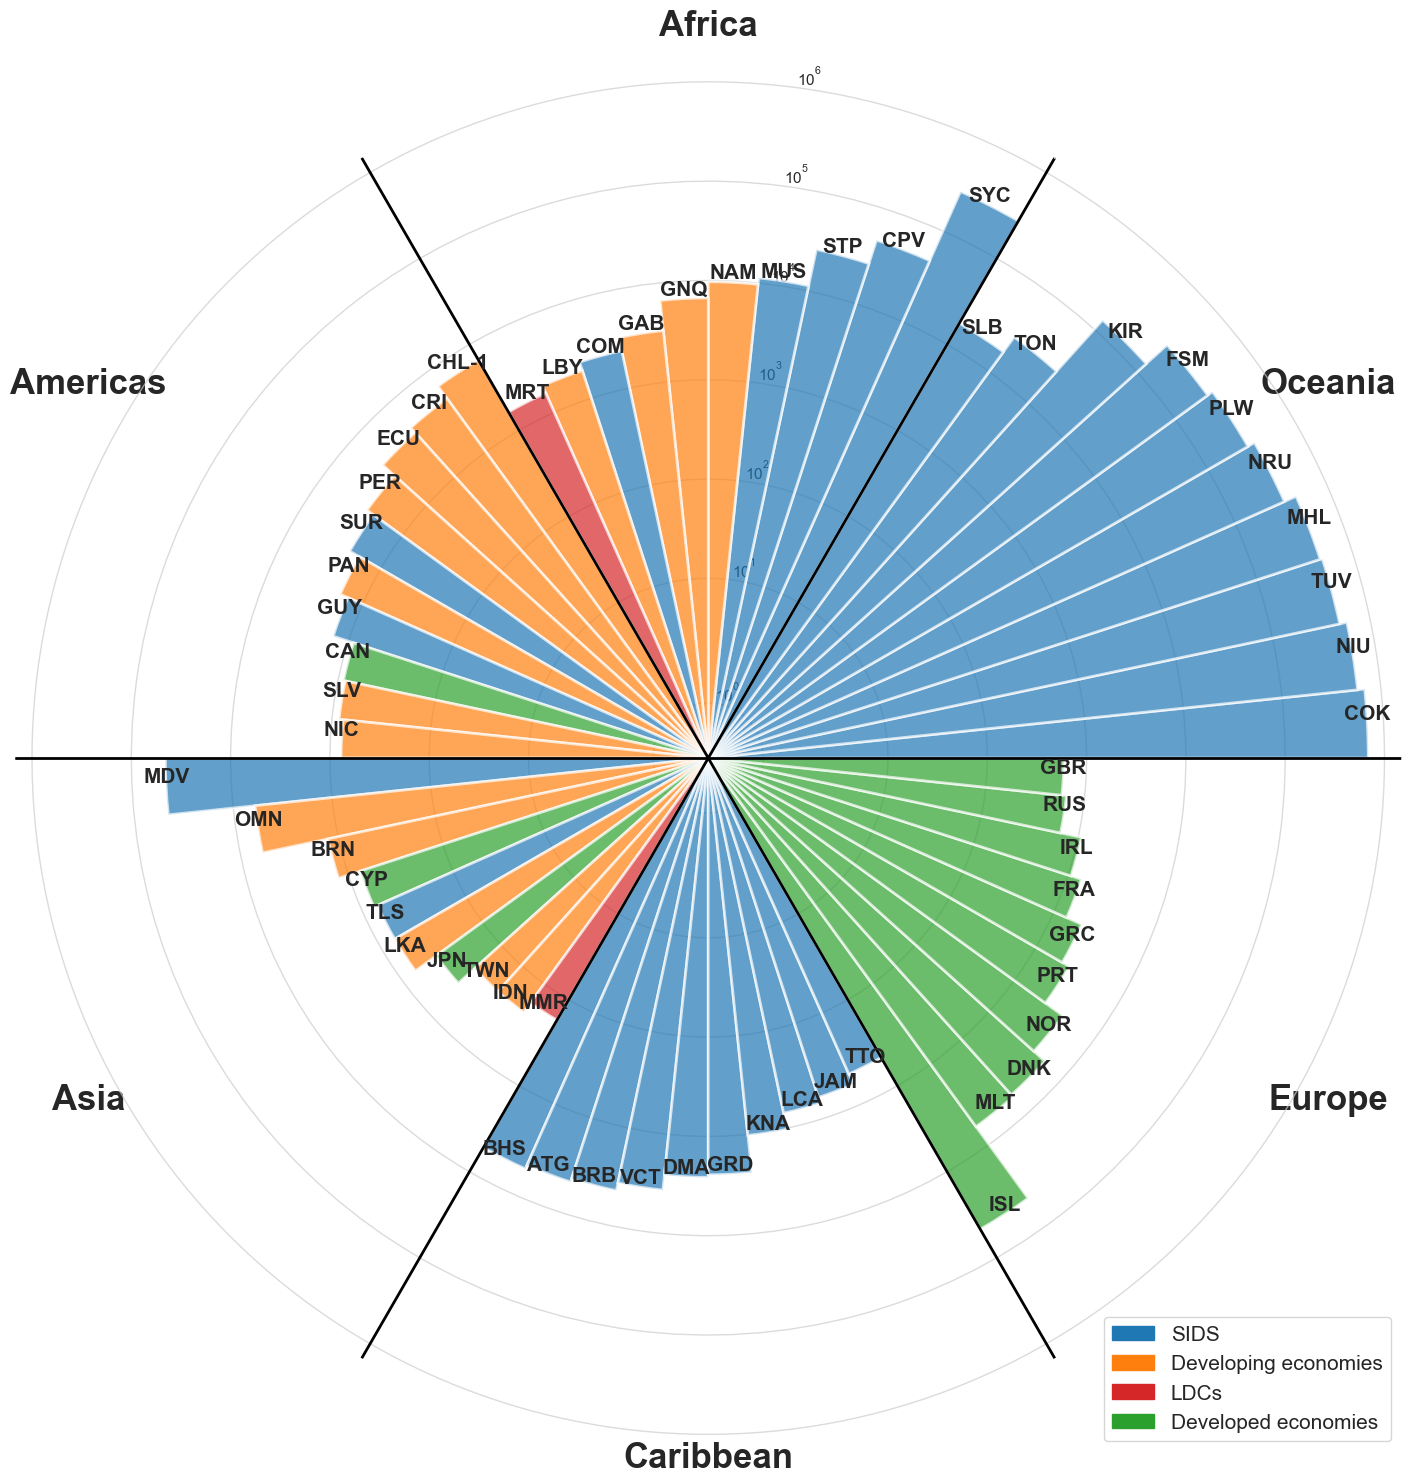

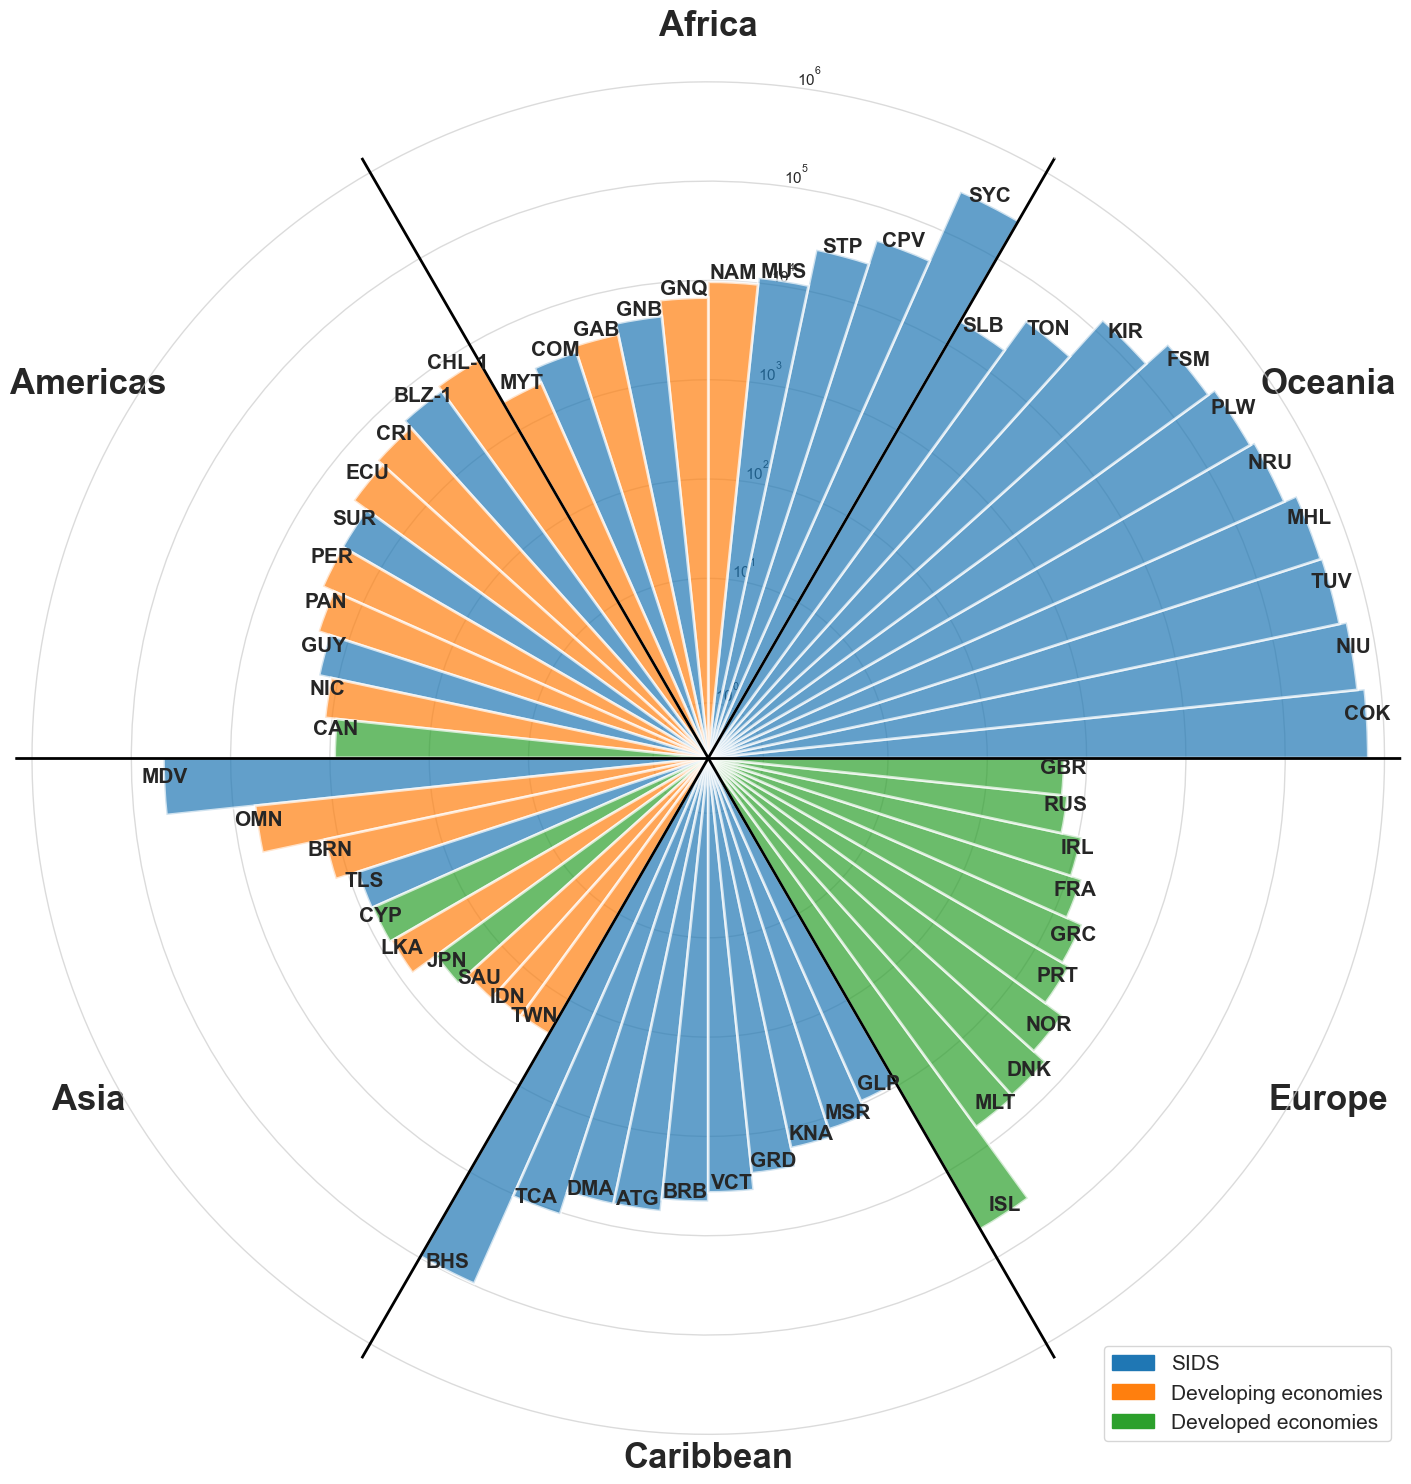

In [105]:
# paper4
pf = df[[
    'Continent', 'ISO', 'Groups', 'cBCW_per_capita', 
    'oBCW_per_capita', 'Total BCW_per_capita'
]].copy()

# Top 10 countries for each Continent by cBCW_per_capita, oBCW_per_capita and Total BCW_per_capita
top_10_bcw = pf.groupby('Continent').apply(lambda x: x.nlargest(10, 'cBCW_per_capita')).reset_index(drop=True)
top_10_bcw.drop(columns=['oBCW_per_capita', 'Total BCW_per_capita'], inplace=True)
top_10_oBCW = pf.groupby('Continent').apply(lambda x: x.nlargest(10, 'oBCW_per_capita')).reset_index(drop=True)
top_10_oBCW.drop(columns=['cBCW_per_capita', 'Total BCW_per_capita'], inplace=True)
top_10_Total_BCW = pf.groupby('Continent').apply(lambda x: x.nlargest(10, 'Total BCW_per_capita')).reset_index(drop=True)
top_10_Total_BCW.drop(columns=['cBCW_per_capita', 'oBCW_per_capita'], inplace=True)

datasets = [top_10_bcw, top_10_oBCW, top_10_Total_BCW]

category_colors = {
    'SIDS': '#1f77b4',       # Bleu
    'Developing economies': '#ff7f0e',  # Orange
    'Developed economies': '#2ca02c',    # Vert
    'LDCs': '#d62728'         # Rouge
}
for dta in datasets:
    if 'cBCW_per_capita' in dta.columns:
        segment_col = 'Continent'
        label_col = 'ISO'
        value_col = 'cBCW_per_capita'
        category_col = 'Groups'
    elif 'oBCW_per_capita' in dta.columns:
        segment_col = 'Continent'
        label_col = 'ISO'
        value_col = 'oBCW_per_capita'
        category_col = 'Groups'
    else:
        segment_col = 'Continent'
        label_col = 'ISO'
        value_col = 'Total BCW_per_capita'
        category_col = 'Groups'

    wind_rose(dta, segment_col=segment_col, label_col=label_col, value_col=value_col,
              category_col=category_col, n_top=10, figsize=(18, 18), category_colors=category_colors)

## Joint Regimes and Overlapping Claims

Estimate BCW for maritime areas under joint management or contested jurisdiction.

### Data Preparation

In [106]:
dta = pd.read_csv(SUMMARY_DIR / 'bce_data.csv')
dta = dta.rename(columns={'country_name': 'entity', 'ISO_TER1': 'ISO'})
dta = dta[['entity', 'ISO', 'Area_EEZ_KM2', 'Continent']]
otj = dta[dta['entity'].str.contains('Joint regime|Overlapping', na=False)]
otj = otj.sort_values(by='entity').reset_index(drop=True)

for _, row in otj.iterrows():
    if 'Joint regime' in row['entity']:
        otj.loc[row.name, 'ISO'] = f'JR-{row.name + 1}'
    elif 'Overlapping claim' in row['entity']:
        otj.loc[row.name, 'ISO'] = f'OC-{row.name - 20}'
otj
# 21 Joint regimes and 11 Overlapping claims
# Only one with data on Seq: Joint regime area Torres Strait Treaty: Papua New Guinea and Australia


,entity,ISO,Area_EEZ_KM2,Continent
0,Joint regime area Torres Strait Treaty: Papua ...,JR-1,"2,620.8506",Oceania
1,Joint regime area: Barbados / Guyana,JR-2,67.1575,Caribbean
2,Joint regime area: Costa Rica / Ecuador (Galap...,JR-3,"17,337.2422",Americas
3,Joint regime area: Croatia / Slovenia,JR-4,98.3189,Europe
4,Joint regime area: Dominican Republic / Colombia,JR-5,"13,110.7034",Caribbean
5,Joint regime area: Ecuador / Colombia,JR-6,"18,663.0196",Americas
6,Joint regime area: France / Italy,JR-7,67.0413,Europe
7,Joint regime area: Honduras / United Kingdom (...,JR-8,"2,075.2810",Americas
8,Joint regime area: Iceland / Denmark (Faeroe I...,JR-9,"1,233.6885",Europe
9,Joint regime area: Iceland / Norway (Jan Mayen),JR-10,"45,531.9129",Europe


In [107]:
full = pd.read_csv(DATA_DIR / 'shp' / 'EEZ_full.csv')
full = full[['UNION', 'ISO_TER1', 'ISO_TER2', 'ISO_TER3']]

otj_full = otj.merge(full, left_on='entity', right_on='UNION', how='left').drop(columns=['UNION'])

country_Total_BCW = df[['ISO', 'Total BCW_per_capita']].copy()
country_Total_BCW_unique = country_Total_BCW.drop_duplicates(subset='ISO')
otj_full['Total BCWpcap_1'] = otj_full['ISO_TER1'].map(country_Total_BCW_unique.set_index('ISO')['Total BCW_per_capita'])
otj_full['Total BCWpcap_2'] = otj_full['ISO_TER2'].map(country_Total_BCW_unique.set_index('ISO')['Total BCW_per_capita'])
otj_full['Total BCWpcap_3'] = otj_full['ISO_TER3'].map(country_Total_BCW_unique.set_index('ISO')['Total BCW_per_capita'])

otj_full['Total BCW_InvolvedStates'] = otj_full[['Total BCWpcap_1', 'Total BCWpcap_2', 'Total BCWpcap_3']].mean(axis=1).replace(0, np.nan)
otj_full.drop(columns=['Total BCWpcap_1', 'Total BCWpcap_2', 'Total BCWpcap_3', 'ISO_TER1', 'ISO_TER2', 'ISO_TER3'], inplace=True)


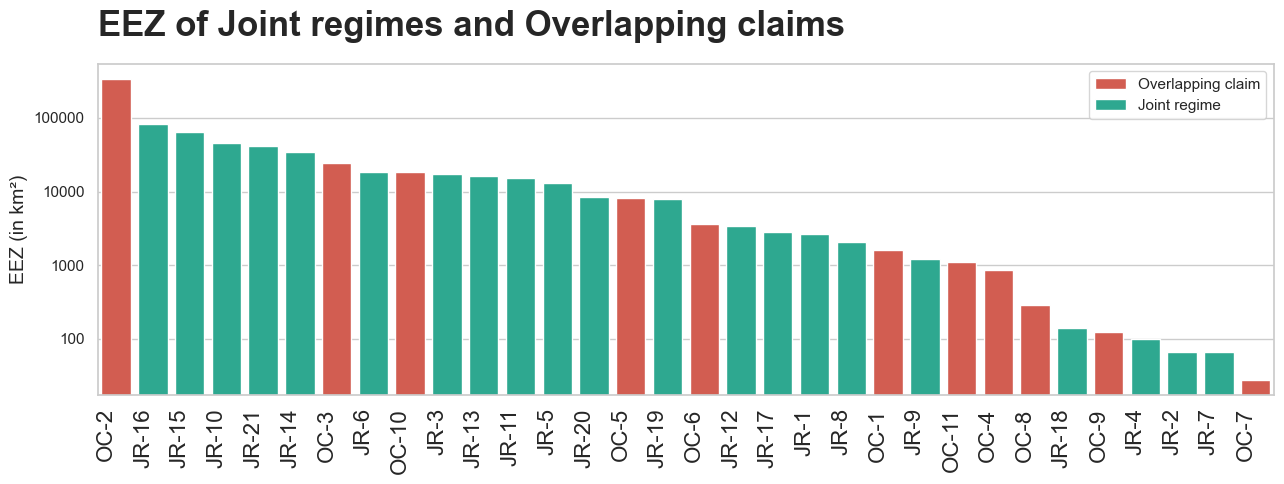

In [108]:
# supl8
plt.figure(figsize=(13, 5))
palette = {
    'Joint regime': '#1ABC9C',   # turquoise
    'Overlapping claim': '#E74C3C'  # corail chaud
}
otj_full['entity_type'] = otj_full['entity'].apply(lambda x: 'Joint regime' if 'Joint regime' in x else 'Overlapping claim')
sns.barplot(data=otj_full.sort_values(by='Area_EEZ_KM2', ascending=False), x='ISO', 
            y='Area_EEZ_KM2', hue='entity_type', palette=palette)

plt.xlabel('')
plt.xticks(rotation=90, ha='right', fontsize=16)
plt.ylabel('EEZ (in km²)', fontsize=14)
plt.yscale('log')
format_log_axis_plain('y')

plt.title('EEZ of Joint regimes and Overlapping claims', 
          fontsize=25, fontweight='bold', pad=20, loc='left')

plt.legend()
plt.tight_layout()
plt.show()

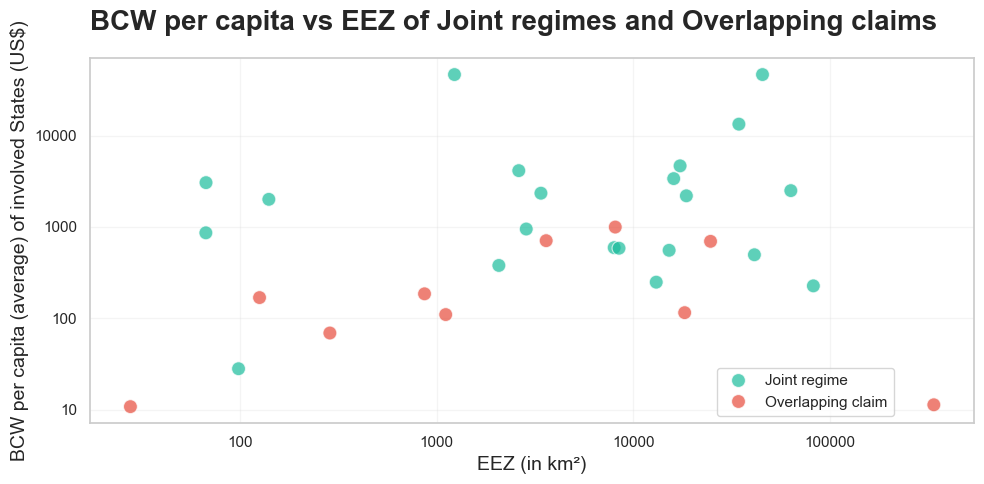

In [109]:
plt.figure(figsize=(10, 5))

sns.scatterplot(data=otj_full, x='Area_EEZ_KM2', y='Total BCW_InvolvedStates', hue='entity_type', 
                palette=palette, s=100, alpha=0.7)

plt.xlabel('EEZ (in km²)', fontsize=14)
plt.ylabel('BCW per capita (average) of involved States (US$)', fontsize=14)

plt.title('BCW per capita vs EEZ of Joint regimes and Overlapping claims',
          fontsize=20, fontweight='bold', pad=20, loc='left')

plt.yscale('log')
plt.xscale('log')
format_log_axis_plain('y')
format_log_axis_plain('x')

plt.legend(title='', bbox_to_anchor=(0.7, 0), loc='lower left', ncol=1)
plt.tight_layout()
plt.grid(alpha=0.2)
plt.show()

### Bootstrap Estimates

In [110]:
# 1. Calcul du Total BCW par km² pour chaque pays
df['Total BCW_per_km2'] = df['Total BCW'] / df['Area_EEZ_KM2']

# 2. Bootstrap pour IC95% de Total BCW_per_km²
n_boot = 10000
d_boot = df['Total BCW_per_km2'].dropna().values
boot_means = np.random.choice(d_boot, size=(n_boot, len(d_boot)), replace=True).mean(axis=1)

Total_BCWperkm_mean = boot_means.mean()
Total_BCWperkm_ci = np.percentile(boot_means, [2.5, 97.5])

# 3. Aires totales des zones JR et OC
joint_area = otj_full[otj_full['entity_type'] == 'Joint regime']['Area_EEZ_KM2'].sum()
overlapping_area = otj_full[otj_full['entity_type'] == 'Overlapping claim']['Area_EEZ_KM2'].sum()

# 4. Estimations avec IC95% pour JR et OC
joint_Total_BCW_mean = joint_area * Total_BCWperkm_mean
joint_Total_BCW_ci = joint_area * Total_BCWperkm_ci

overlapping_Total_BCW_mean = overlapping_area * Total_BCWperkm_mean
overlapping_Total_BCW_ci = overlapping_area * Total_BCWperkm_ci

# 5. Affichage
print(f"Mean Total BCW per km²: {Total_BCWperkm_mean:,.2f} US$/km² "
      f"[{Total_BCWperkm_ci[0]:,.2f} ; {Total_BCWperkm_ci[1]:,.2f}]")

print(f"We estimate that the total Total BCW in Joint regimes is approximately "
      f"{joint_Total_BCW_mean/1e9:,.2f}B US$ "
      f"[{joint_Total_BCW_ci[0]/1e9:,.2f}B ; {joint_Total_BCW_ci[1]/1e9:,.2f}B]")

print(f"We estimate that the total Total BCW in Overlapping claims is approximately "
      f"{overlapping_Total_BCW_mean/1e9:,.2f}B US$ "
      f"[{overlapping_Total_BCW_ci[0]/1e9:,.2f}B ; {overlapping_Total_BCW_ci[1]/1e9:,.2f}B]")


Mean Total BCW per km²: 13,543.94 US$/km² [10,412.07 ; 17,274.85]
We estimate that the total Total BCW in Joint regimes is approximately 5.11B US$ [3.93B ; 6.51B]
We estimate that the total Total BCW in Overlapping claims is approximately 5.39B US$ [4.14B ; 6.87B]


In [111]:
# Moyenne ponderee par l'aire (ratio global)
Total_BCWperkm_mean_aw = df['Total BCW'].sum() / df['Area_EEZ_KM2'].sum()

# Bootstrap par "pays" pour l'IC95% du ratio global
n_boot = 10000
rng = np.random.default_rng(42)
means_aw = []

vals = df[['Total BCW', 'Area_EEZ_KM2']].dropna().to_numpy()
n = len(vals)

for _ in range(n_boot):
    sample = vals[rng.integers(0, n, n), :]   # bootstrap pays
    num = sample[:,0].sum()
    den = sample[:,1].sum()
    if den > 0:
        means_aw.append(num/den)

means_aw = np.array(means_aw)
aw_ci = np.percentile(means_aw, [2.5, 97.5])

print(f"Weighted mean Total BCW per km²: {Total_BCWperkm_mean_aw:,.2f} US$/km² "
      f"[{aw_ci[0]:,.2f} ; {aw_ci[1]:,.2f}]")

Weighted mean Total BCW per km²: 8,046.08 US$/km² [7,525.02 ; 12,738.64]


In [112]:
byc = df.dropna(subset=['Total BCW','Area_EEZ_KM2','Continent']).copy()
res = []

for cont, g in byc.groupby('Continent'):
    m = g['Total BCW'].sum() / g['Area_EEZ_KM2'].sum()
    # petit bootstrap par continent
    arr = g[['Total BCW','Area_EEZ_KM2']].to_numpy()
    b = []
    for _ in range(5000):
        samp = arr[rng.integers(0, len(arr), len(arr)), :]
        den = samp[:,1].sum()
        if den>0:
            b.append(samp[:,0].sum()/den)
    ci = np.percentile(b, [2.5,97.5])
    res.append((cont, m, ci[0], ci[1]))

continent_rates = pd.DataFrame(res, columns=['Continent','Total BCWperkm','ci_lo','ci_hi'])
continent_rates

,Continent,Total BCWperkm,ci_lo,ci_hi
0,Africa,"10,579.4557","7,679.3521","14,054.9823"
1,Americas,"10,799.6556","5,314.5557","20,672.3874"
2,Asia,"7,909.4688","4,754.1197","11,706.4196"
3,Caribbean,"18,120.3164","4,095.6933","33,349.1174"
4,Europe,"11,478.8028","5,781.1409","40,691.9674"
5,Oceania,"8,154.9825","4,671.7630","10,672.2737"


In [113]:
# 1) Taux globaux pondere (au cas ou un continent manque)
df_clean = df.dropna(subset=['Total BCW','Area_EEZ_KM2']).copy()
global_rate = df_clean['Total BCW'].sum() / df_clean['Area_EEZ_KM2'].sum()

# Bootstrap pour IC95% global (coherent avec ta methode precedente)
rng = np.random.default_rng(42)
n_boot = 10000
vals = df_clean[['Total BCW','Area_EEZ_KM2']].to_numpy()
n = len(vals)
boot_ratio = []
for _ in range(n_boot):
    samp = vals[rng.integers(0, n, n), :]
    den = samp[:,1].sum()
    if den > 0:
        boot_ratio.append(samp[:,0].sum()/den)
boot_ratio = np.array(boot_ratio)
global_ci_lo, global_ci_hi = np.percentile(boot_ratio, [2.5, 97.5])

# 2) Table des taux par continent (tu l'as deja creee: continent_rates)
#    Continent | Total BCWperkm | ci_lo | ci_hi
# On la transforme en dict pour merge facile
rate_map = continent_rates.set_index('Continent')[['Total BCWperkm','ci_lo','ci_hi']]

# 3) Prep des donnees OTJ (JR / OC)
cols_needed = ['entity','ISO','Continent','entity_type','Area_EEZ_KM2']
missing_cols = [c for c in cols_needed if c not in otj_full.columns]
if missing_cols:
    raise ValueError(f"Colonnes manquantes dans otj_full: {missing_cols}")

otj = otj_full[cols_needed].copy()

# 4) Merge des taux continentaux
otj = otj.merge(rate_map, left_on='Continent', right_index=True, how='left')

# 5) Fallback: si continent inconnu => utiliser le taux global pondere
otj['Total BCWperkm'] = otj['Total BCWperkm'].fillna(global_rate)
otj['ci_lo']    = otj['ci_lo'].fillna(global_ci_lo)
otj['ci_hi']    = otj['ci_hi'].fillna(global_ci_hi)

# 6) Estimations par entite
otj['Total BCW_est']      = otj['Area_EEZ_KM2'] * otj['Total BCWperkm']
otj['Total BCW_est_low']  = otj['Area_EEZ_KM2'] * otj['ci_lo']
otj['Total BCW_est_high'] = otj['Area_EEZ_KM2'] * otj['ci_hi']

result_otj = otj.rename(columns={
    'Area_EEZ_KM2':'EEZ_area',
    'Total BCWperkm':'rate_per_km2',
    'ci_lo':'rate_ci_lo',
    'ci_hi':'rate_ci_hi'
})[[
    'entity','ISO','Continent','entity_type','EEZ_area',
    'rate_per_km2','rate_ci_lo','rate_ci_hi',
    'Total BCW_est','Total BCW_est_low','Total BCW_est_high'
]]

# 7) Totaux par type (JR / OC) et global
def summarize(group):
    return pd.Series({
        'Total BCW_total'     : group['Total BCW_est'].sum(),
        'Total BCW_total_low' : group['Total BCW_est_low'].sum(),
        'Total BCW_total_high': group['Total BCW_est_high'].sum()
    })

summary_by_type = (result_otj
                   .groupby('entity_type', dropna=False)
                   .apply(summarize)
                   .reset_index())

summary_global = summarize(result_otj)

# 8) Impression lisible (en milliards US$)
def to_billion(x): return x / 1e9

print("=== TOTALS BY TYPE (Billion US$) ===")
for _, row in summary_by_type.iterrows():
    et = row['entity_type']
    print(f"{et}: {to_billion(row['Total BCW_total_low']):.2f}B  -  "
          f"{to_billion(row['Total BCW_total']):.2f}B  -  "
          f"{to_billion(row['Total BCW_total_high']):.2f}B")

print("\n=== GLOBAL TOTAL (Billion US$) ===")
print(f"{to_billion(summary_global['Total BCW_total_low']):.2f}B  -  "
      f"{to_billion(summary_global['Total BCW_total']):.2f}B  -  "
      f"{to_billion(summary_global['Total BCW_total_high']):.2f}B")

# 9) Resultats par entite (DataFrame principal)
# result_otj

=== TOTALS BY TYPE (Billion US$) ===
Joint regime: 2.18B  -  4.05B  -  7.97B
Overlapping claim: 1.92B  -  3.44B  -  5.34B

=== GLOBAL TOTAL (Billion US$) ===
4.11B  -  7.50B  -  13.31B


In [114]:
global_rate, global_ci_lo, global_ci_hi

(np.float64(9825.346721946036),
 np.float64(7525.019863699738),
 np.float64(12738.641282018625))

### Econometric Predictions (Log-Log + Smearing)

In [115]:
# =========================
# Préparation des données
# =========================
X = df[['Area_EEZ_KM2', 'Continent']].copy()
X['log_EEZ'] = np.log(X['Area_EEZ_KM2'])
X.drop(columns=['Area_EEZ_KM2'], inplace=True)
y = np.log(df['Total BCW'])

X = pd.get_dummies(X, columns=['Continent'], drop_first=True)
regdata = pd.concat([X, y], axis=1).dropna()
X = regdata.drop(columns=['Total BCW']).astype(float)
y = regdata['Total BCW'].astype(float)

# Ajout constante pour statsmodels
X_sm = sm.add_constant(X)

# =========================
# Régression log-log avec statsmodels
# =========================
model_sm = sm.OLS(y, X_sm).fit(cov_type='HC3')  # robust SE
print(model_sm.summary())

# =========================
# Prédictions avec IC
# =========================
otj_pred = otj_full[['Area_EEZ_KM2', 'Continent']].copy()
otj_pred['log_EEZ'] = np.log(otj_pred['Area_EEZ_KM2'])
areas = otj_pred['Area_EEZ_KM2'].values
otj_pred.drop(columns=['Area_EEZ_KM2'], inplace=True)
otj_pred = pd.get_dummies(otj_pred, columns=['Continent'], drop_first=True)

# Ajout de colonnes manquantes si besoin pour aligner
for col in X.columns:
    if col not in otj_pred.columns:
        otj_pred[col] = 0
otj_pred = otj_pred[X.columns].astype(float)  # même ordre que pour l'entraînement

otj_pred_sm = sm.add_constant(otj_pred)

predictions = model_sm.get_prediction(otj_pred_sm)
pred_summary = predictions.summary_frame(alpha=0.05)  # 95% CI

# =========================
# Conversion et assemblage final
# =========================
resid_log = model_sm.resid
S = np.mean(np.exp(resid_log))  # smearing factor

Total_BCW_pred = np.exp(pred_summary['mean']) * S
Total_BCW_lower = np.exp(pred_summary['mean_ci_lower']) * S
Total_BCW_upper = np.exp(pred_summary['mean_ci_upper']) * S

# Total_BCW estimé avec méthode Total_BCWperkm
Total_BCW_est = areas * Total_BCWperkm_mean

result_df = pd.DataFrame({
    'entity': otj_full['entity'],
    'ISO': otj_full['ISO'],
    'Continent': otj_full['Continent'],
    'EEZ_area': areas,
    'Total BCW_pred': Total_BCW_pred,
    'Total BCW_pred_lower': Total_BCW_lower,
    'Total BCW_pred_upper': Total_BCW_upper,
    'Total BCW_est': Total_BCW_est
})

result_df['Total BCW_est_low'] = areas * Total_BCWperkm_ci[0]
result_df['Total BCW_est_high'] = areas * Total_BCWperkm_ci[1]
print(f"""
Total Total BCW estimated for Joint regimes and Overlapping claims:
- Lower bound: {result_df['Total BCW_pred_lower'].sum()/1e9:.2f} billion US$
- Point estimate: {result_df['Total BCW_pred'].sum()/1e9:.2f} billion US$
- Upper bound: {result_df['Total BCW_pred_upper'].sum()/1e9:.2f} billion US$""")
result_df.head()

                            OLS Regression Results                            
Dep. Variable:              Total BCW   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     29.53
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.33e-24
Time:                        00:51:52   Log-Likelihood:                -464.60
No. Observations:                 190   AIC:                             943.2
Df Residuals:                     183   BIC:                             965.9
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   5.8147    


Total Total BCW estimated for Joint regimes and Overlapping claims:
- Lower bound: 6.01 billion US$
- Point estimate: 14.24 billion US$
- Upper bound: 37.06 billion US$


,entity,ISO,Continent,EEZ_area,Total BCW_pred,Total BCW_pred_lower,Total BCW_pred_upper,Total BCW_est,Total BCW_est_low,Total BCW_est_high
0,Joint regime area Torres Strait Treaty: Papua ...,JR-1,Oceania,"2,620.8506","5,788,095.2758","715,415.0471","46,828,826.2266","35,496,649.8638","27,288,479.3957","45,274,809.3268"
1,Joint regime area: Barbados / Guyana,JR-2,Caribbean,67.1575,"269,974.6504","51,398.6382","1,418,059.2016","909,577.8468","699,248.9834","1,160,136.6253"
2,Joint regime area: Costa Rica / Ecuador (Galap...,JR-3,Americas,"17,337.2422","279,247,419.9968","58,575,718.0126","1,331,253,362.6665","234,814,612.6476","180,516,576.7370","299,498,314.7862"
3,Joint regime area: Croatia / Slovenia,JR-4,Europe,98.3189,"155,728.4779","16,688.1239","1,453,210.6176","1,331,625.9978","1,023,703.6099","1,698,445.1597"
4,Joint regime area: Dominican Republic / Colombia,JR-5,Caribbean,"13,110.7034","149,174,215.5299","64,330,148.4914","345,917,848.7973","177,570,614.3175","136,509,559.8790","226,485,477.8159"


In [116]:
SEED = 42
B_SIM = 10000  # number of draws for parametric simulation of the total
rng = np.random.default_rng(SEED)

df_ = df.copy()
df_ = df_.loc[(df_['Area_EEZ_KM2'] > 0) & (df_['Total BCW'] > 0)].copy()

X = df_[['Area_EEZ_KM2', 'Continent']].copy()
X['log_EEZ'] = np.log(X['Area_EEZ_KM2'])
X.drop(columns=['Area_EEZ_KM2'], inplace=True)

y = np.log(df_['Total BCW'])  # dependent variable on log scale

# dummies
X = pd.get_dummies(X, columns=['Continent'], drop_first=True)

# drop rows with any remaining NA
regdata = pd.concat([X, y.rename('Total BCW')], axis=1).dropna()
X = regdata.drop(columns=['Total BCW']).astype(float)
y = regdata['Total BCW'].astype(float)

# add constant for statsmodels
X_sm = sm.add_constant(X, has_constant='add')

# estimation: statsmodels OLS with robust HC3 SE
model_sm = sm.OLS(y, X_sm).fit(cov_type='HC3')  # robust SE
print(model_sm.summary())

# predictions per entity (JR / OC) with smearing
# prepare prediction design matrix for otj_full
otj_pred = otj_full[['Area_EEZ_KM2', 'Continent']].copy()
assert (otj_pred['Area_EEZ_KM2'] > 0).all(), "Area_EEZ_KM2 must be > 0 for log transform in otj_pred"
otj_pred['log_EEZ'] = np.log(otj_pred['Area_EEZ_KM2'])
areas = otj_pred['Area_EEZ_KM2'].values  # keep raw areas for Total BCW-per-km method
otj_pred.drop(columns=['Area_EEZ_KM2'], inplace=True)
otj_pred = pd.get_dummies(otj_pred, columns=['Continent'], drop_first=True)

# align dummy columns with training design X
for col in X.columns:
    if col not in otj_pred.columns:
        otj_pred[col] = 0.0
otj_pred = otj_pred[X.columns].astype(float)
otj_pred_sm = sm.add_constant(otj_pred, has_constant='add')

# point predictions on log scale
pred_log = model_sm.predict(otj_pred_sm)
resid_log = model_sm.resid # duan smearing factor (global)
S = float(np.mean(np.exp(resid_log)))  # E[exp(epsilon)]

# per-entity predictions in levels (E[Y|X])
Total_BCW_pred = np.exp(pred_log) * S

# optional: approximate 95% CI per entity via linear CI on log scale + smearing
pred_obj = model_sm.get_prediction(otj_pred_sm)
pred_summary = pred_obj.summary_frame(alpha=0.05)  # mean_ci_lower/upper on log scale
Total_BCW_lower = np.exp(pred_summary['mean_ci_lower'].values) * S
Total_BCW_upper = np.exp(pred_summary['mean_ci_upper'].values) * S

# total and its 95% CI via parametric simulation (do not sum per-entity CIs)
beta_hat = model_sm.params.values
# use the (robust) covariance matrix returned by statsmodels with cov_type='HC3'
V_beta = model_sm.cov_params().values

totals = np.empty(B_SIM, dtype=float)
X_pred_full = otj_pred_sm.values  # (n_pred x k)

for b in range(B_SIM):
    beta_b = rng.multivariate_normal(mean=beta_hat, cov=V_beta, check_valid='ignore')
    mu_log_b = X_pred_full @ beta_b                     # log-scale mean
    pred_b = np.exp(mu_log_b) * S                       # back-transform with smearing
    totals[b] = pred_b.sum()

tot_low, tot_mid, tot_high = np.percentile(totals, [2.5, 50.0, 97.5])

# Total_BCW-per-km comparator (needs Total_BCWperkm_mean and Total_BCWperkm_ci = (low, high))
Total_BCW_est = areas * Total_BCWperkm_mean
Total_BCW_est_low = areas * Total_BCWperkm_ci[0]
Total_BCW_est_high = areas * Total_BCWperkm_ci[1]

# assemble result table
result_df = pd.DataFrame({
    'entity': otj_full['entity'].values,
    'ISO': otj_full['ISO'].values,
    'Continent': otj_full['Continent'].values,
    'EEZ_area': areas.astype(float),
    'Total BCW_pred': Total_BCW_pred.astype(float),
    'Total BCW_pred_lower': Total_BCW_lower.astype(float),
    'Total BCW_pred_upper': Total_BCW_upper.astype(float),
    'Total BCW_est': Total_BCW_est.astype(float),
    'Total BCW_est_low': Total_BCW_est_low.astype(float),
    'Total BCW_est_high': Total_BCW_est_high.astype(float),
})

# reporting
total_point = float(result_df['Total BCW_pred'].sum())

print(f"""
Total Total BCW (JR/OC) — statsmodels + smearing (levels):
- Point estimate: {total_point/1e9:.2f} billion US$
- 95% CI (parametric, aggregated): [{tot_low/1e9:.2f}, {tot_high/1e9:.2f}] billion US$
(median of simulated totals: {tot_mid/1e9:.2f} billion US$)

Comparator — Total BCW-per-km:
- Point estimate: {result_df['Total BCW_est'].sum()/1e9:.2f} billion US$
- 95% range (agg by sum of pointwise): [{result_df['Total BCW_est_low'].sum()/1e9:.2f}, {result_df['Total BCW_est_high'].sum()/1e9:.2f}] billion US$
""")

# return final table for further use
# result_df


                            OLS Regression Results                            
Dep. Variable:              Total BCW   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     29.53
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.33e-24
Time:                        00:51:52   Log-Likelihood:                -464.60
No. Observations:                 190   AIC:                             943.2
Df Residuals:                     183   BIC:                             965.9
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   5.8147    


Total Total BCW (JR/OC) — statsmodels + smearing (levels):
- Point estimate: 14.24 billion US$
- 95% CI (parametric, aggregated): [8.27, 29.61] billion US$
(median of simulated totals: 15.24 billion US$)

Comparator — Total BCW-per-km:
- Point estimate: 10.49 billion US$
- 95% range (agg by sum of pointwise): [8.07, 13.38] billion US$



In [117]:
hall1 = otj_full[['ISO', 'entity']].rename(columns={'entity':'country_name'}).sort_values(by='country_name').reset_index(drop=True)
hall2 = data[['ISO', 'country_name']].sort_values(by='country_name').reset_index(drop=True)
hall = pd.concat([hall2, hall1], axis=0)
# hall.to_excel('country_names_ISO.xlsx', index=False)

In [118]:
print(f"""
Total Total BCW estimated for Joint regimes and Overlapping claims:
- Lower bound: {result_df['Total BCW_pred_lower'].sum()/1e9:.2f} billion US$
- Point estimate: {result_df['Total BCW_pred'].sum()/1e9:.2f} billion US$
- Upper bound: {result_df['Total BCW_pred_upper'].sum()/1e9:.2f} billion US$""")


Total Total BCW estimated for Joint regimes and Overlapping claims:
- Lower bound: 6.01 billion US$
- Point estimate: 14.24 billion US$
- Upper bound: 37.06 billion US$


In [119]:
pal = {**CONTINENT_PAL, 'unknown': '#d3D3D3'}


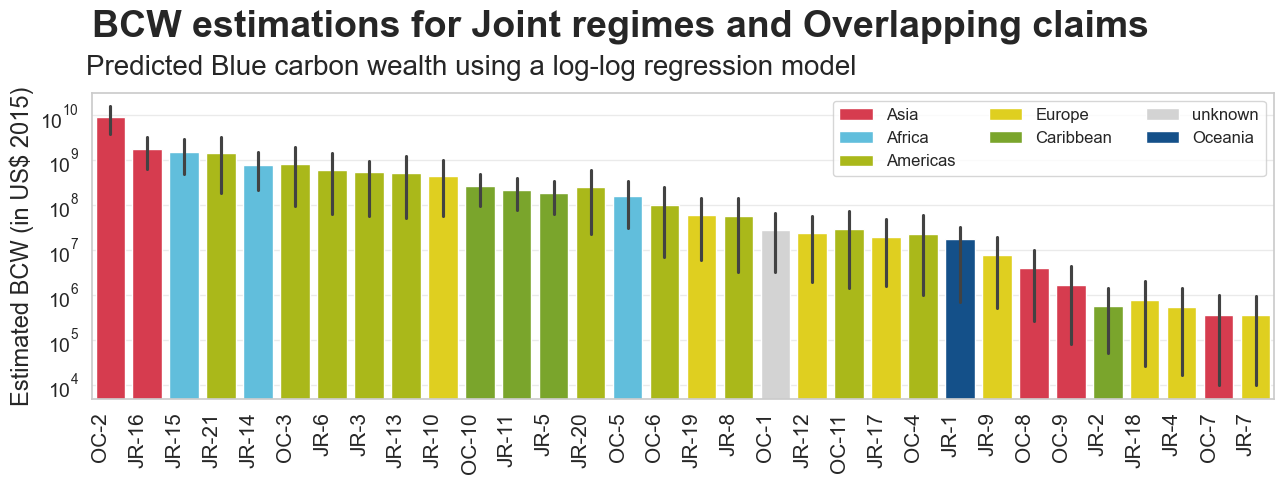

In [120]:
# preds
df_pred_ci = result_df[['ISO', 'Continent', 'Total BCW_pred', 'Total BCW_pred_lower', 'Total BCW_pred_upper']].copy()
df_pred_ci = df_pred_ci.sort_values(by='Total BCW_pred', ascending=False)
df_pred_ci = df_pred_ci.melt(id_vars=['ISO', 'Continent'], 
                            value_vars=['Total BCW_pred', 'Total BCW_pred_lower', 'Total BCW_pred_upper'],
                            var_name='Type', value_name='Total BCW')
df_pred_ci['Type'] = df_pred_ci['ISO'].apply(
    lambda x: 'Joint regime' if x.startswith('JR-') else ('Overlapping claim' if x.startswith('OC-') else 'Other'))
df_pred_ci['Continent'] = df_pred_ci['Continent'].fillna('unknown')

# estim
df_est_ci = result_df[['ISO', 'Continent', 'Total BCW_est', 'Total BCW_est_low', 'Total BCW_est_high']].copy()
df_est_ci = df_est_ci.sort_values(by='Total BCW_est', ascending=False)
df_est_ci = df_est_ci.melt(id_vars=['ISO', 'Continent'], 
                            value_vars=['Total BCW_est', 'Total BCW_est_low', 'Total BCW_est_high'],
                            var_name='Type', value_name='Total BCW')
df_est_ci['Type'] = df_est_ci['ISO'].apply(
    lambda x: 'Joint regime' if x.startswith('JR-') else ('Overlapping claim' if x.startswith('OC-') else 'Other'))
df_est_ci['Continent'] = df_est_ci['Continent'].fillna('unknown')

# LR
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=df_pred_ci, x='ISO', y='Total BCW', hue='Continent', palette=pal, ax=ax)
plt.title('BCW estimations for Joint regimes and Overlapping claims',
          fontsize=27, fontweight='bold', pad=40, loc='left')
fig.text(0.0725, 0.875, 'Predicted Blue carbon wealth using a log-log regression model', 
         fontsize=20, va='top', ha='left')
plt.ylabel('Estimated BCW (in US$ 2015)', fontsize=17)
plt.xlabel('', fontsize=14)
ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xticks(rotation=90, ha='right', fontsize=15)
plt.legend(fontsize=12, loc='upper right', ncol=3)
plt.tight_layout()
plt.grid(axis='y', alpha=0.4)
plt.show()

## Debt Analysis

Compare BCW to total external debt across countries and economic groups.

In [121]:
be = df[[
    'country_name', 'ISO', 'Groups', 'Continent', 'Population', 'cBCW', 'cBCW_per_capita', 
    'Total BCW', 'Total BCW_per_capita', 'Debt (2015 US$)', 'Debt (2015 US$)_per_capita',
    'BCW_Debt_ratio'
]].copy()

**30 Premiers**

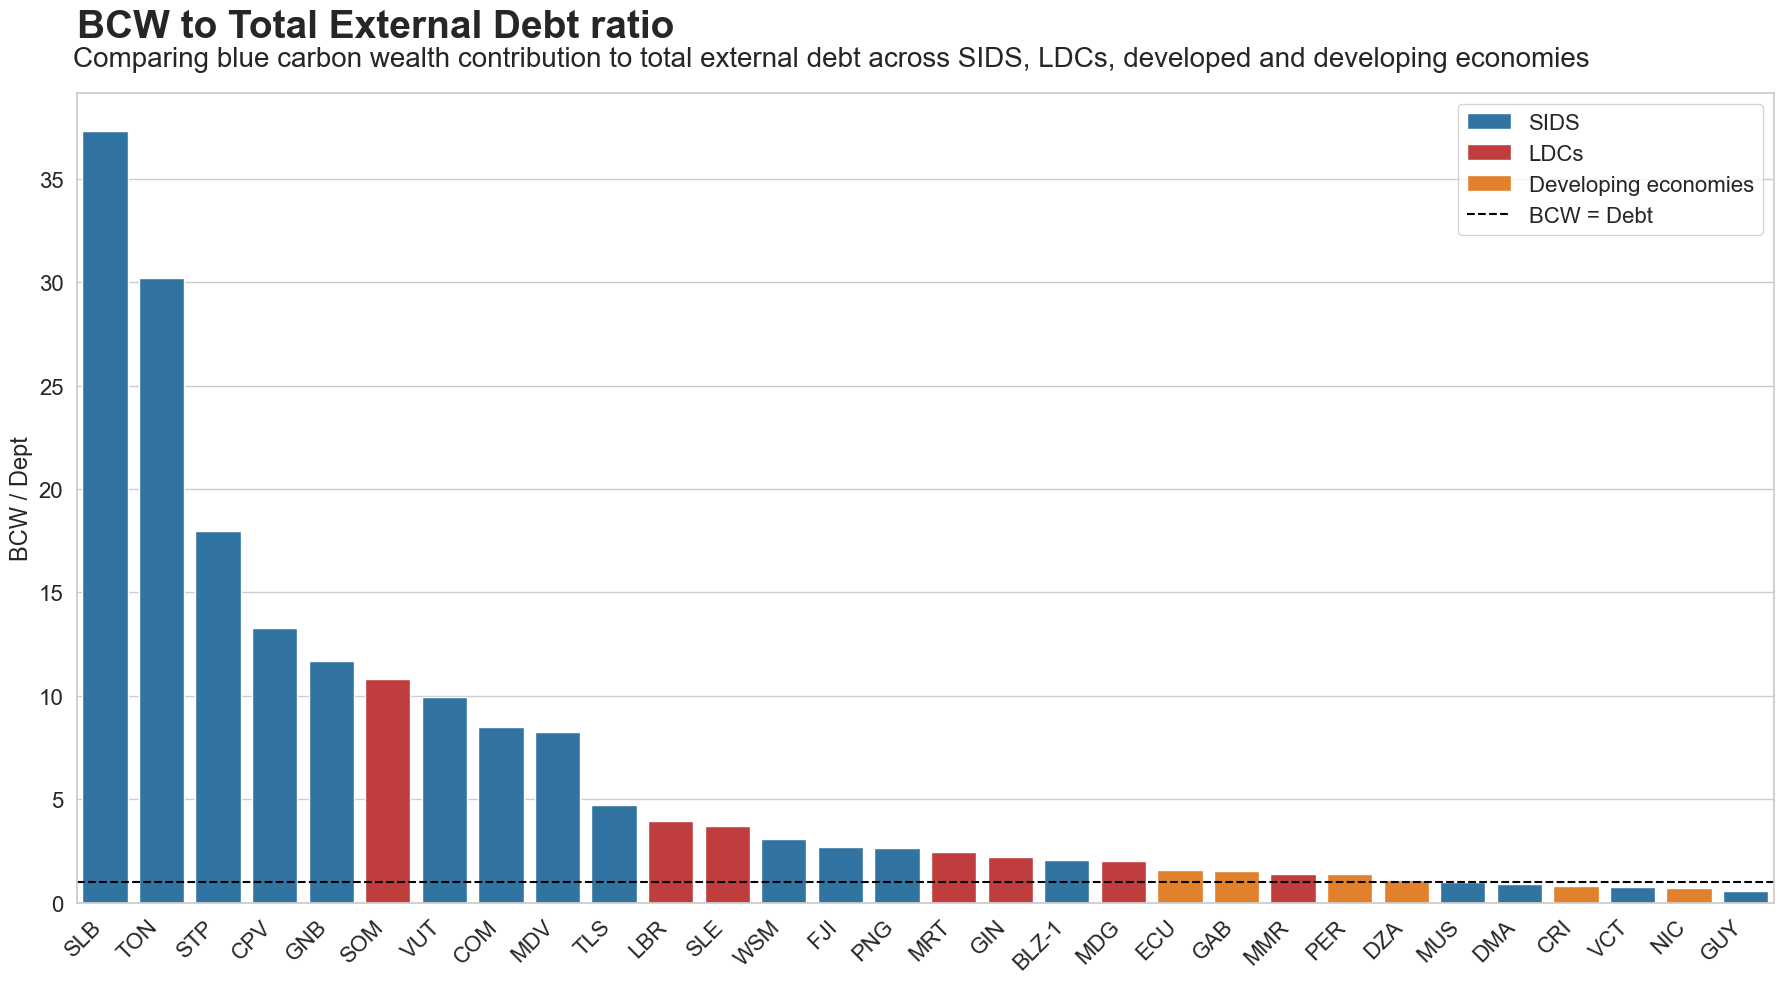

In [122]:
by_bg = be[['ISO', 'Groups', 'BCW_Debt_ratio']]
by_bg = be.sort_values(by='BCW_Debt_ratio', ascending=False)

fig, ax = plt.subplots(figsize=(18, 10))
sns.set_theme(style='whitegrid')
sns.barplot(by_bg.iloc[:30, :], x='ISO', y='BCW_Debt_ratio', palette= color_mapping,ci=False, hue='Groups',ax=ax)
plt.title('BCW to Total External Debt ratio', 
         fontsize=28, fontweight='bold', loc='left', pad=40)
fig.text(0.045, 0.945, 'Comparing blue carbon wealth contribution to total external debt across SIDS, LDCs, developed and developing economies', 
         fontsize=20, va='top', ha='left')
plt.axhline(y=1, color='black', linestyle='--', label='BCW = Debt')
plt.ylabel('BCW / Dept', fontsize=17)
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()
plt.legend(fontsize=16)
plt.show()

**30 Suivants**

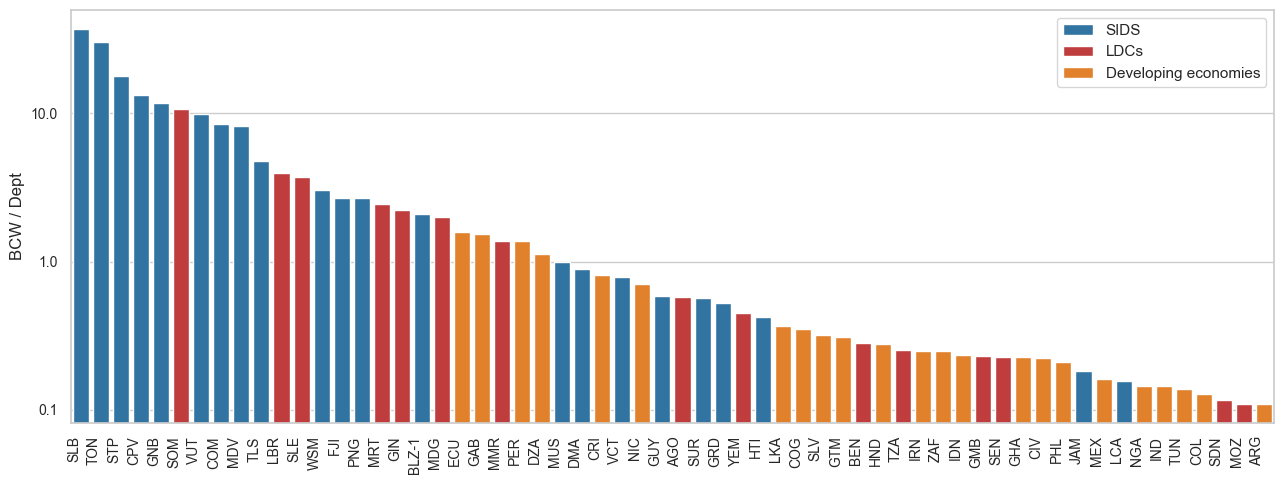

In [123]:
# supl22
by_bg = be[['ISO', 'Groups', 'BCW_Debt_ratio']].copy()
by_bg = be.sort_values(by='BCW_Debt_ratio', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
sns.set_theme(style='whitegrid')
sns.barplot(by_bg.iloc[:60, :], x='ISO', y='BCW_Debt_ratio', ci=False, palette= color_mapping, 
            hue='Groups',ax=ax)
plt.ylabel('BCW / Dept', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=90,ha='right')
plt.tick_params(axis='both', which='major', labelsize=10)
ax.set_yscale("log")
format_log_axis_plain('y')
plt.tight_layout()
plt.legend()
plt.show()

### Comparison BCE vs BCE+BCP

In [124]:
selection = [
    "ISO", "country_name", "Continent", "Groups",
    "Population", "GDP", "Debt (2015 US$)", "CO2_emissions_2023",
    "uptake_total_mean", "BCP Seq (tC)",
    "cBCW", "Total BCW"
]
df = data[selection].copy()

# Without BCP (only BCE)
df["S_BCE"] = df["uptake_total_mean"] * CMOL

# With BCP
df["S_BCE_BCP"] = df["BCP Seq (tC)"] * CMOL
df["S_ALL"] = df["S_BCE"] + df["S_BCE_BCP"]

df["E"] = df["CO2_emissions_2023"] # CO2 emissions in 2023 (tCO2)

# A) Net balance (soft "carbon budget")
df["NetCO2_BCE"] = df["S_BCE"] - df["E"]
df["NetCO2_ALL"] = df["S_ALL"] - df["E"]
df["Delta_NetCO2"] = df["NetCO2_ALL"] - df["NetCO2_BCE"]

df["is_net_sink_BCE"] = df["NetCO2_BCE"] < 0
df["is_net_sink_ALL"] = df["NetCO2_ALL"] < 0
df["switch_sink_status"] = df["is_net_sink_ALL"] != df["is_net_sink_BCE"]

# B) Coverage : years of emissions covered by the BCW
df["BCW_TOTAL"] = df["Total BCW"]
df["Coverage_BCE"] = df["cBCW"] / (df["E"] * gscc_value)
df["Coverage_ALL"] = df["BCW_TOTAL"] / (df["E"] * gscc_value)
df["Delta_Coverage"] = df["Coverage_ALL"] - df["Coverage_BCE"]

# C) Relief : % of debt that could be covered by the BCW
df["Relief_BCE"] = (df["S_BCE"] * gscc_value) / df["Debt (2015 US$)"]
df["Relief_ALL"] = (df["S_ALL"] * gscc_value) / df["Debt (2015 US$)"]
df["Delta_Relief"] = df["Relief_ALL"] - df["Relief_BCE"]

# Quadrants BCE and BCP
def quadrant(is_sink, high_stress):
    if (not is_sink) and high_stress: 
        return "Source + high debt stress"
    if (not is_sink) and (not high_stress): 
        return "Source + low debt stress"
    if is_sink and high_stress: 
        return "Sink + high debt stress"
    return "Sink + low debt stress"


out_cols = [
    "ISO","country_name","Continent","Groups",
    "E","S_BCE","S_ALL",
    "NetCO2_BCE","NetCO2_ALL","Delta_NetCO2",
    "cBCW","Total BCW","Coverage_BCE","Coverage_ALL","Delta_Coverage",
    "Debt (2015 US$)","Debt_to_GDP","Relief_BCE","Relief_ALL","Delta_Relief",
    "Quadrant_BCE","Quadrant_ALL","switch_sink_status","switch_quadrant"
]

# ----------------------------
# outputs "paper-ready"
# ----------------------------
# (C) Typology of countries by net sink/source status and debt stress (using debt/GDP ratio)
df["Debt_to_GDP"] = df["Debt (2015 US$)"] / df["GDP"]
thr = df["Debt_to_GDP"].median(skipna=True)
df["high_debt_stress"] = df["Debt_to_GDP"] >= thr

df["Quadrant_BCE"] = [quadrant(s, h) for s, h in zip(df["is_net_sink_BCE"], df["high_debt_stress"])]
df["Quadrant_ALL"] = [quadrant(s, h) for s, h in zip(df["is_net_sink_ALL"], df["high_debt_stress"])]
df["switch_quadrant"] = df["Quadrant_BCE"] != df["Quadrant_ALL"]

quadrant_switch = df[df["switch_quadrant"]].sort_values("Delta_NetCO2").copy()
# (A) Top movers: BCP effect
top_delta_cov = df.sort_values("Delta_Coverage", ascending=False).head(25)
top_delta_relief = df.sort_values("Delta_Relief", ascending=False).head(25)

# (B) Who switches from net sink to net source or vice versa when including BCP Seq?
switchers = df[df["switch_sink_status"]].sort_values("Delta_NetCO2").copy()


df[out_cols].to_csv(OUTPUT_DIR / "bcw_finance_indicators.csv", index=False)
top_delta_cov[out_cols].to_csv(OUTPUT_DIR / "top_movers_delta_coverage.csv", index=False)
top_delta_relief[out_cols].to_csv(OUTPUT_DIR / "top_movers_delta_relief.csv", index=False)
switchers[out_cols].to_csv(OUTPUT_DIR / "switchers_sink_status.csv", index=False)
quadrant_switch[out_cols].to_csv(OUTPUT_DIR / "switchers_quadrant.csv", index=False)

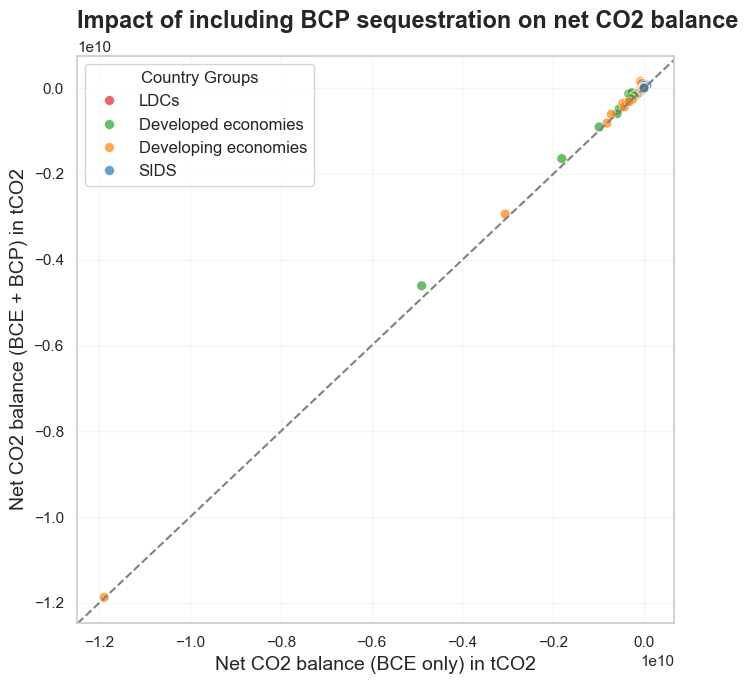

In [125]:
# paper7
# Plot : scatter NetCO2_BCE (x) vs NetCO2_BCP (y) avec ligne y=x.
plt.figure(figsize=(7, 7))
sns.scatterplot(
    data=df, x='NetCO2_BCE', y='NetCO2_ALL', hue='Groups', 
    palette=color_mapping, s=50, alpha=0.7
)
plt.axline((0, 0), slope=1, color='gray', linestyle='--')
plt.xlabel('Net CO2 balance (BCE only) in tCO2', fontsize=14)
plt.ylabel('Net CO2 balance (BCE + BCP) in tCO2', fontsize=14)
plt.title(
    'Impact of including BCP sequestration on net CO2 balance', 
    fontsize=17, fontweight='bold', pad=20, loc='left'
)
plt.legend(title='Country Groups', fontsize=12)
plt.grid(alpha=0.2)
plt.tight_layout()

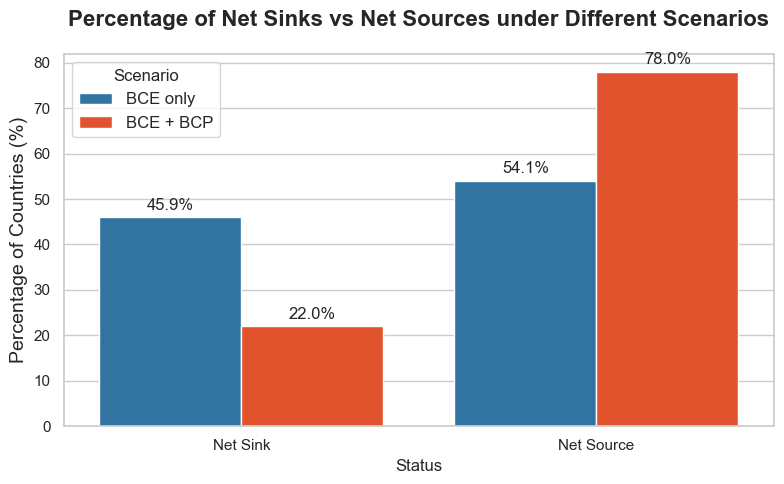

In [126]:
# paper7
# Plot : bar chart : % “net sink” en BCE vs % “net sink” en BCE+BCP + % switchers.
summary = pd.DataFrame({
    'Status': ['Net Sink', 'Net Source'],
    'BCE only': [
        df['is_net_sink_BCE'].mean() * 100, 
        (1 - df['is_net_sink_BCE'].mean()) * 100
    ],
    'BCE + BCP': [
        df['is_net_sink_ALL'].mean() * 100, 
        (1 - df['is_net_sink_ALL'].mean()) * 100
    ]
})

summary_melted = summary.melt(id_vars='Status', var_name='Scenario', value_name='Percentage')
plt.figure(figsize=(8, 5))
sns.barplot(
    data=summary_melted, x='Status', y='Percentage', 
    hue='Scenario', palette=['#1f77b4', "#ff420e"]
)
plt.ylabel('Percentage of Countries (%)', fontsize=14)
plt.title(
    'Percentage of Net Sinks vs Net Sources under Different Scenarios', 
    fontsize=16, fontweight='bold', pad=20
)
for index, row in summary_melted.iterrows():
    plt.text(
        index % 2 + (index // 2) * 0.4 - 0.2, 
        row['Percentage'] + 1, 
        f"{row['Percentage']:.1f}%", 
        ha='center', va='bottom', fontsize=12
    )
plt.legend(title='Scenario', fontsize=12)
plt.tight_layout()
plt.show()

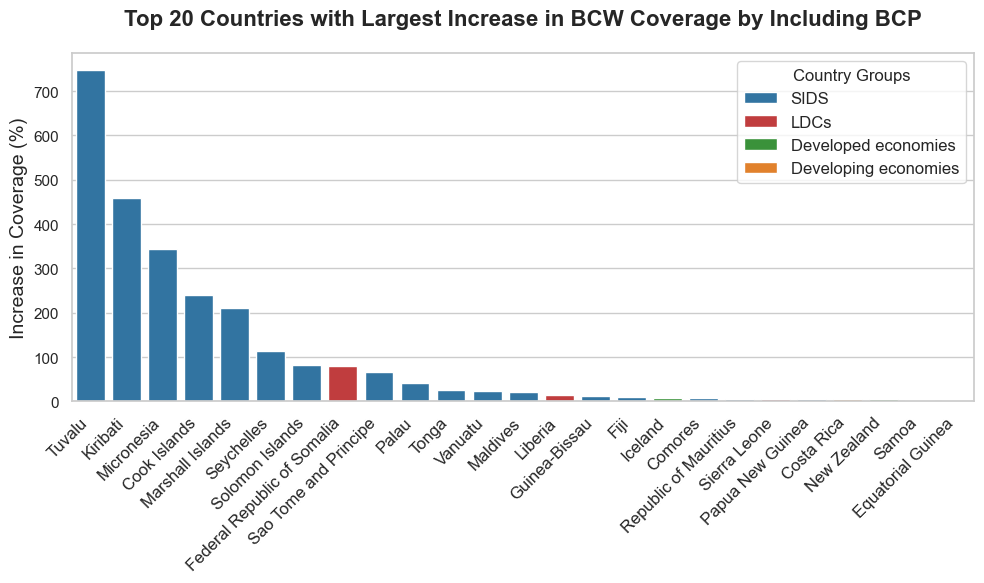

In [127]:
# paper7
# Plot : bar chart des 20 plus grands Delta_Coverage
# top_delta_cov
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_delta_cov, x='country_name', y='Delta_Coverage', 
    palette=color_mapping, hue='Groups'
)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ylabel('Increase in Coverage (%)', fontsize=14)
plt.xlabel('')
plt.title(
    'Top 20 Countries with Largest Increase in BCW Coverage by Including BCP', 
    fontsize=16, fontweight='bold', pad=20
)
plt.legend(title='Country Groups', fontsize=12)
plt.tight_layout()
plt.show()

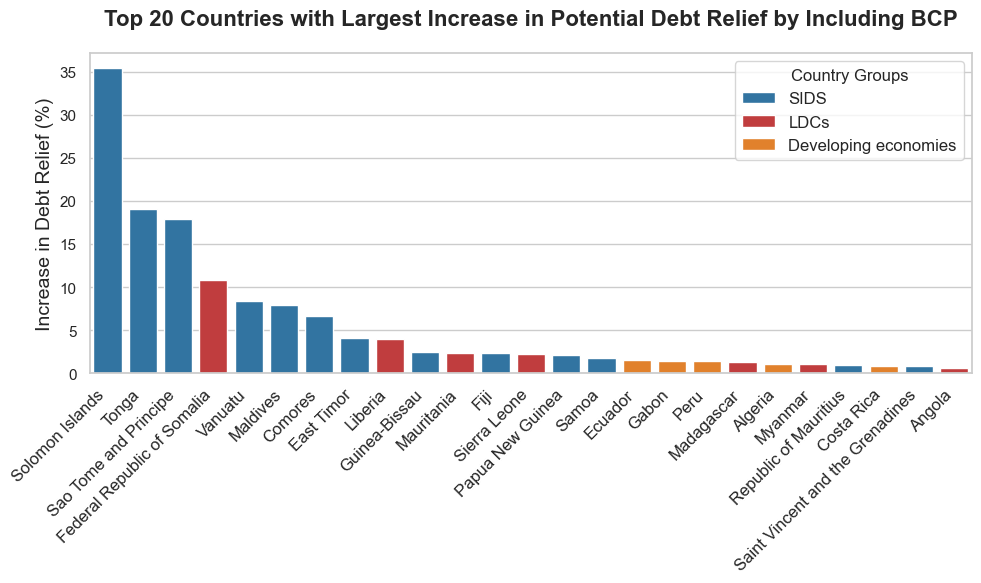

In [128]:
# paper7
# Plot : bar chart top 20 Delta_Relief
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_delta_relief, x='country_name', y='Delta_Relief', 
    palette=color_mapping, hue='Groups'
)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ylabel('Increase in Debt Relief (%)', fontsize=14)
plt.xlabel('')
plt.title(
    'Top 20 Countries with Largest Increase in Potential Debt Relief by Including BCP', 
    fontsize=16, fontweight='bold', pad=20
)
plt.legend(title='Country Groups', fontsize=12)
plt.tight_layout()
plt.show()

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


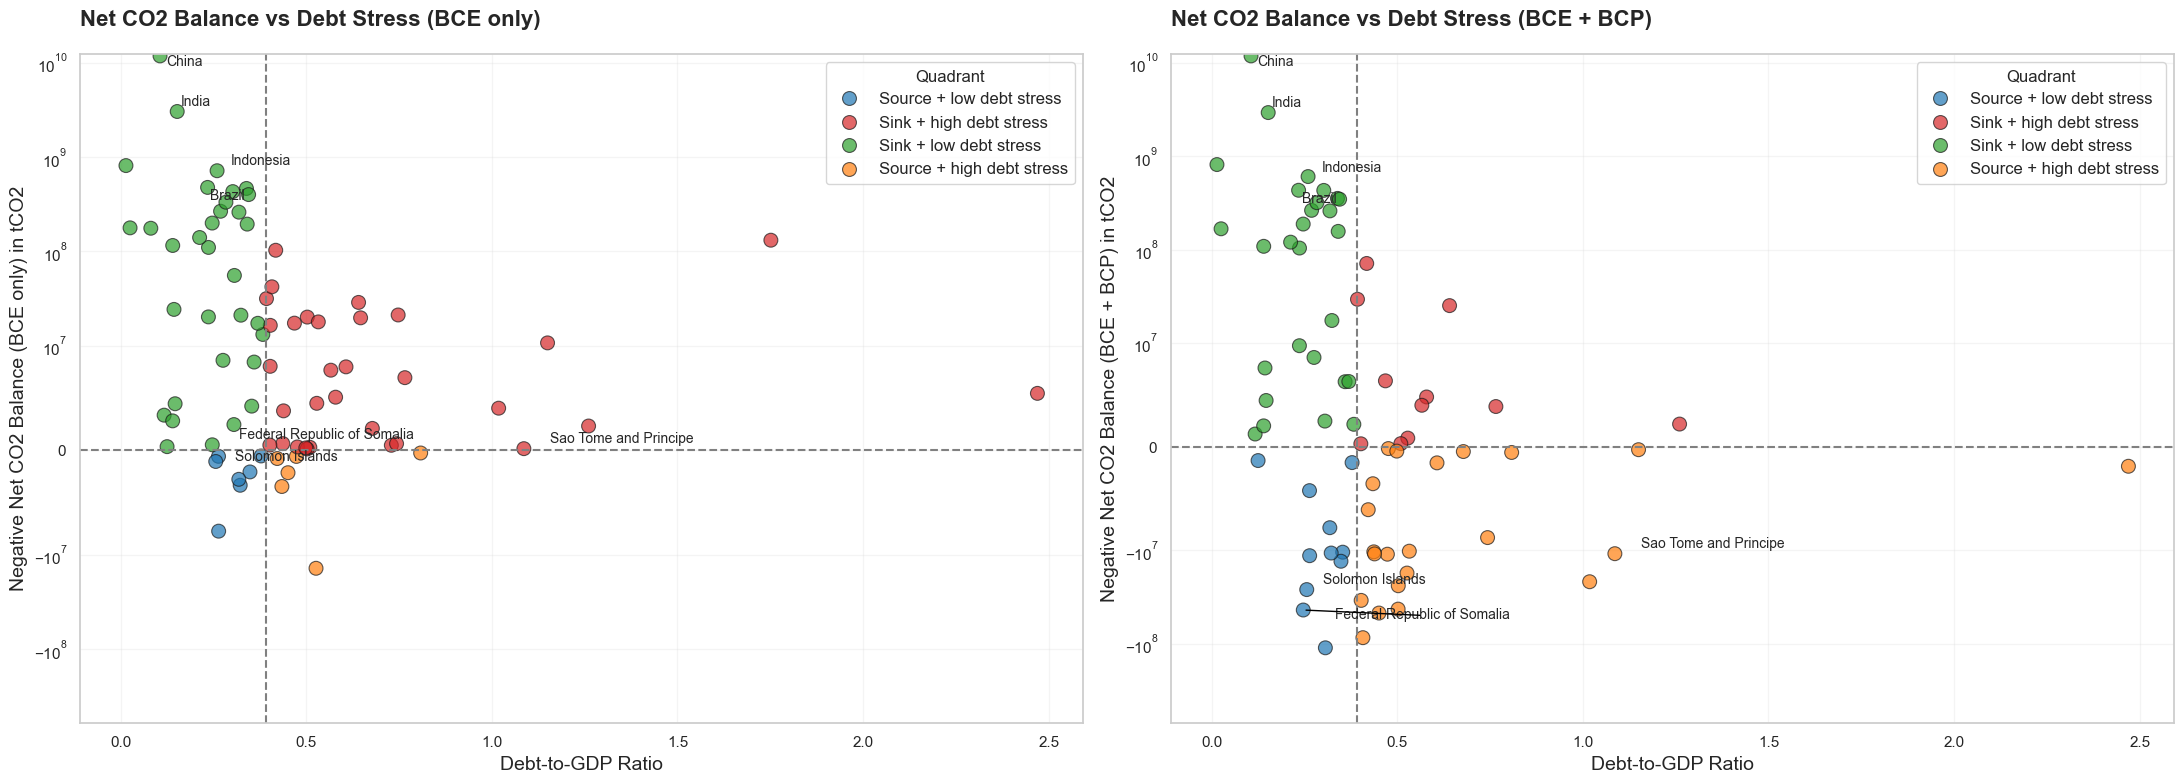

In [129]:
# paper7
countries_to_label = top_delta_cov["country_name"].head(10).to_list() + ["China", "United States", "India", "Indonesia", "Brazil"]

fig, axes = plt.subplots(1, 2, figsize=(22, 8), sharex=True)

# ---------- Plot 1: BCE ----------
ax = axes[0]
sns.scatterplot(
    data=df, x="Debt_to_GDP", y=-df["NetCO2_BCE"],
    hue="Quadrant_BCE", palette=MAP_FIN, s=100, alpha=0.7, edgecolor="k",
    ax=ax
)
ax.axhline(0, color="gray", linestyle="--")
ax.axvline(df["Debt_to_GDP"].median(), color="gray", linestyle="--")
ax.set_xlabel("Debt-to-GDP Ratio", fontsize=14)
ax.set_ylabel("Negative Net CO2 Balance (BCE only) in tCO2", fontsize=14)
ax.set_title(
    "Net CO2 Balance vs Debt Stress (BCE only)",
    fontsize=16, fontweight="bold", pad=20, loc="left"
)
# ax.set_xscale("log")
ax.set_yscale("symlog", linthresh=1e7)
ax.grid(alpha=0.2)

# Annotations BCE
texts = []
subset = df[df["country_name"].isin(countries_to_label)].dropna(subset=["Debt_to_GDP", "NetCO2_BCE"])
for _, r in subset.iterrows():
    x, y = r["Debt_to_GDP"], -r["NetCO2_BCE"]
    texts.append(ax.text(x, y, r["country_name"], fontsize=10))

adjust_text(
    texts,
    ax=ax,
    lim=500,                       # plus d'itérations = meilleur placement (un peu plus lent)
    expand_text=(1.15, 1.25),       # “zone tampon” autour du texte
    expand_points=(1.10, 1.20),     # “zone tampon” autour des points
    force_text=(0.3, 0.8),          # force de répulsion entre textes (x, y)
    force_points=(0.2, 0.7),        # force de répulsion vis-à-vis des points
    force_objects=(0.2, 0.7),       # idem si tu ajoutes d’autres objets
    only_move={"points": "y", "text": "xy"},  # points restent, texte bouge (x+y)
    arrowprops=dict(arrowstyle="-", lw=1, color="black"),
)

ax.legend(title="Quadrant", fontsize=12)

# ---------- Plot 2: ALL ----------
ax = axes[1]
sns.scatterplot(
    data=df, x="Debt_to_GDP", y=-df["NetCO2_ALL"],
    hue="Quadrant_ALL", palette=MAP_FIN, s=100, alpha=0.7, edgecolor="k",
    ax=ax
)
ax.axhline(0, color="gray", linestyle="--")
ax.axvline(df["Debt_to_GDP"].median(), color="gray", linestyle="--")
ax.set_xlabel("Debt-to-GDP Ratio", fontsize=14)
ax.set_ylabel("Negative Net CO2 Balance (BCE + BCP) in tCO2", fontsize=14)
ax.set_title(
    "Net CO2 Balance vs Debt Stress (BCE + BCP)",
    fontsize=16, fontweight="bold", pad=20, loc="left"
)
# ax.set_xscale("log")
ax.set_yscale("symlog", linthresh=1e7)
ax.grid(alpha=0.2)

# Annotations ALL
texts = []
subset = df[df["country_name"].isin(countries_to_label)].dropna(subset=["Debt_to_GDP", "NetCO2_ALL"])
for _, r in subset.iterrows():
    x, y = r["Debt_to_GDP"], -r["NetCO2_ALL"]
    texts.append(ax.text(x, y, r["country_name"], fontsize=10))

adjust_text(
    texts,
    ax=ax,
    lim=500,                       # plus d'itérations = meilleur placement (un peu plus lent)
    expand_text=(1.15, 1.25),       # “zone tampon” autour du texte
    expand_points=(1.10, 1.20),     # “zone tampon” autour des points
    force_text=(0.3, 0.8),          # force de répulsion entre textes (x, y)
    force_points=(0.2, 0.7),        # force de répulsion vis-à-vis des points
    force_objects=(0.2, 0.7),       # idem si tu ajoutes d’autres objets
    only_move={"points": "y", "text": "xy"},  # points restent, texte bouge (x+y)
    arrowprops=dict(arrowstyle="-", lw=1, color="black"),
)

ax.legend(title="Quadrant", fontsize=12)

plt.tight_layout()
plt.show()

In [130]:
data['cBCW'].describe()

count              180.0000
mean     1,270,124,772.1342
std      3,740,790,052.0192
min                557.4694
25%         18,959,916.0000
50%        225,697,232.0000
75%        774,377,424.0000
max     36,404,948,992.0000
Name: cBCW, dtype: float64

## Summary Table

Country-level summary statistics grouped by economic classification.

In [131]:
# paper6
# Select relevant columns
tbl = data[[
    'ISO', 'country_name', 'Groups', 'Continent', 'Area_EEZ_KM2',
    'Area_EEZ_KM2_per_capita', 'Total BCW', 'Total BCW_per_capita', 'GDP', 'GDP_per_capita',
    'Debt (2015 US$)', 'Debt (2015 US$)_per_capita'
]].copy()

# Numerical columns to summarise
num_cols = ['Area_EEZ_KM2', 'Area_EEZ_KM2_per_capita', 'Total BCW', 'Total BCW_per_capita',
            'GDP', 'GDP_per_capita', 'Debt (2015 US$)', 'Debt (2015 US$)_per_capita']

# Conversion factors for units
conversion_factors = {
    'Area_EEZ_KM2':               1 / 1_000,
    'Total BCW':                  1 / 1_000_000_000,
    'Total BCW_per_capita':       1,
    'GDP':                        1 / 1_000_000_000,
    'GDP_per_capita':             1,
    'Debt (2015 US$)':            1 / 1_000_000_000,
    'Debt (2015 US$)_per_capita': 1,
}

# Stats for all countries
results = [stats_for_group(tbl, 'All-Countries', num_cols, conversion_factors)]

# Stats for each group
for g in sorted(tbl['Groups'].dropna().unique()):
    sub_df = tbl[tbl['Groups'] == g]
    results.append(stats_for_group(sub_df, g, num_cols, conversion_factors))

# Fusion and formatting
summary_final = pd.concat(results, ignore_index=True)
summary_final.columns = [
    "Groups", "No.", "Stat",
    "EEZ Area (1,000 km²)", "EEZ per capita",
    "Total BCW (billion US$)", "Total BCW per capita",
    "GDP (billion US$)", "GDP per capita",
    "TED (billion US$)", "TED per capita",
]

summary_final.to_csv(SUMMARY_DIR / 'data_summary.csv', index=False, float_format='%.2f')
summary_final


,Groups,No.,Stat,"EEZ Area (1,000 km²)",EEZ per capita,Total BCW (billion US$),Total BCW per capita,GDP (billion US$),GDP per capita,TED (billion US$),TED per capita
0,All-Countries,294,sum,"287,789.8930","1,069.0280","2,315.5800","4,113,229.1600","91,611.8270","3,516,706.3390","6,670.5890","230,036.8900"
1,All-Countries,294,mean,972.2630,4.5110,12.1870,"23,238.5830",449.0780,"17,238.7570",56.0550,"1,933.0830"
2,All-Countries,294,median,342.1180,0.0450,2.0860,480.9250,27.9940,"6,539.9530",9.6800,"1,079.6420"
3,All-Countries,294,std,"2,411.7710",20.2010,25.0290,"94,682.6520","2,013.8570","25,400.8860",185.9780,"2,169.4110"
4,Developed economies,69,sum,"96,031.2010",92.1370,881.1520,"94,089.7360","53,827.4480","2,082,556.7560",241.2930,"36,495.2720"
5,Developed economies,69,mean,"1,391.7570",1.5890,22.5940,"2,542.9660","1,015.6120","39,293.5240",30.1620,"4,561.9090"
6,Developed economies,69,median,266.7420,0.0220,1.2090,130.1120,215.3020,"34,097.2050",10.0510,"3,427.7690"
7,Developed economies,69,std,"4,036.4540",10.4170,40.2440,"7,936.1500","3,076.4600","35,046.2700",43.1420,"2,528.3110"
8,Developing economies,94,sum,"100,776.8190",332.4900,910.0750,"63,233.0280","35,758.2680","577,255.7810","5,892.5830","104,677.2580"
9,Developing economies,94,mean,"1,072.0940",4.0060,14.4460,"1,019.8880",525.8570,"8,489.0560",113.3190,"2,013.0240"


## Supplementary Figures

Additional bar charts and combined plots for publication appendix.

### Coastal BCW Country-Level

In [132]:
df = data.copy()
df['BCW_Debt_ratio'] = df['cBCW'] / df['Debt (2015 US$)']

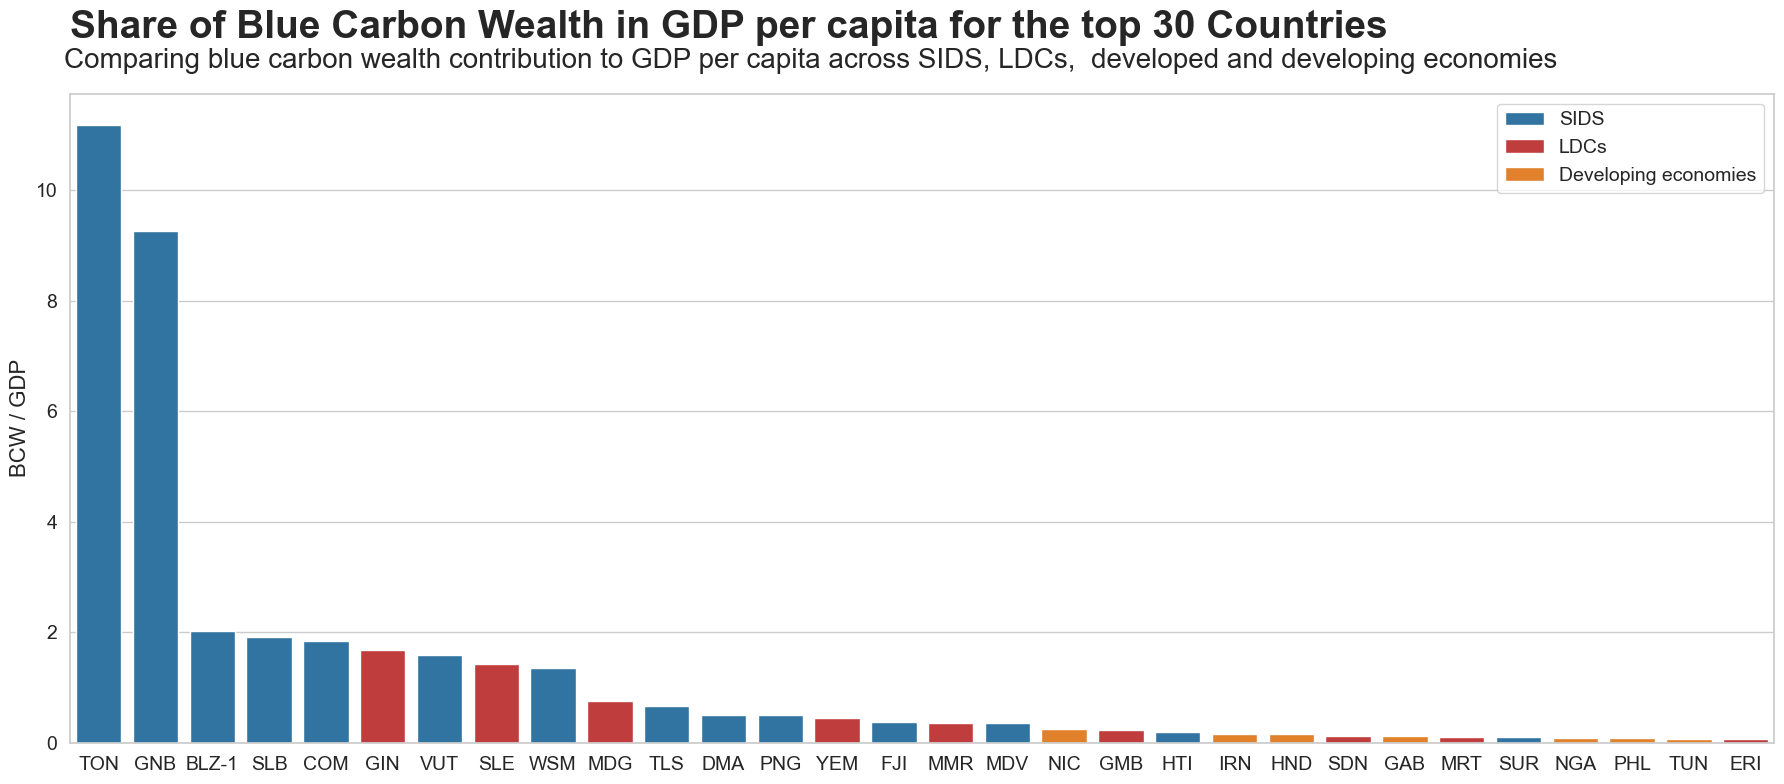

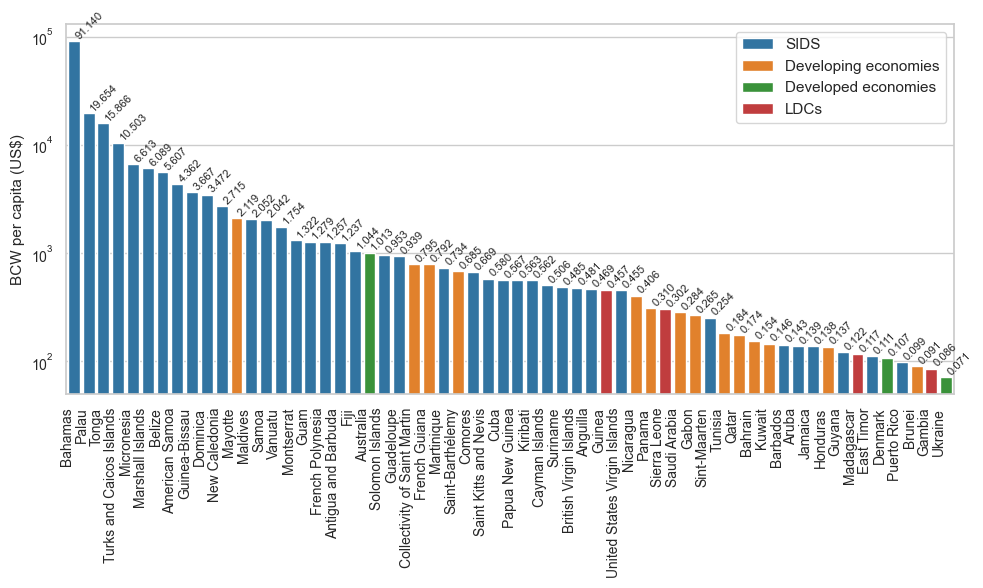

In [133]:
by_bg = df[['ISO', 'Groups', 'BCW_Debt_ratio']]
by_bg = by_bg.sort_values(by='BCW_Debt_ratio', ascending=False)

fig, ax = plt.subplots(figsize=(18, 8))
sns.set_theme(style='whitegrid')
sns.barplot(by_bg.iloc[:30, :], x='ISO', y='BCW_Debt_ratio', palette= color_mapping,
 hue='Groups',ax=ax)
plt.title('Share of Blue Carbon Wealth in GDP per capita for the top 30 Countries', 
         fontsize=28, fontweight='bold', loc='left', pad=40)
fig.text(0.04, 0.93, 'Comparing blue carbon wealth contribution to GDP per capita across SIDS, LDCs,  developed and developing economies', 
         fontsize=20, va='top', ha='left')
plt.ylabel('BCW / GDP', fontsize=16)
plt.xlabel('')
plt.tick_params(axis='both', which='major', labelsize=14)
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(fontsize=14)
plt.show()

# ============================================================================================================
by_country = df[['country_name', 'cBCW_per_capita', 'Groups']]
by_country = by_country.dropna(subset='Groups')
by_country = by_country.sort_values(by='cBCW_per_capita', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style='whitegrid')
sns.barplot(by_country.head(60), y='cBCW_per_capita', x='country_name', palette= color_mapping,
 hue='Groups',ax=ax)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width() / 2, height + 0.05, f'{height/1e3:,.3f}',
                ha='left', va='bottom', rotation=45, fontsize=8)

plt.ylabel('BCW per capita (US$)', fontsize=11)
plt.xlabel('', fontsize=14)
plt.xticks(rotation=90, ha='right')
ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend()
plt.show()

# ============================================================================================================
# by_bg = df[['country_name', 'Groups', 'cBCW', 'Debt (2015 US$)']]
# by_bg['BCW_Dept_Ratio'] = by_bg['cBCW'] / by_bg['Debt (2015 US$)']
# by_bg = by_bg.sort_values(by='BCW_Dept_Ratio', ascending=False)

# fig, ax = plt.subplots(figsize=(9, 10))
# sns.set_theme(style='whitegrid')
# sns.barplot(by_bg.head(60), x='BCW_Dept_Ratio', y='country_name', ci=False, palette= color_mapping,
#  hue='Groups',ax=ax)
# plt.xlabel('Coastal BCW / Dept', fontsize=11)
# plt.ylabel('', fontsize=14)
# plt.tick_params(axis='both', which='major', labelsize=10)
# ax.set_xscale("log")
# format_log_axis_plain('x')
# plt.tight_layout()
# plt.legend()
# plt.show()

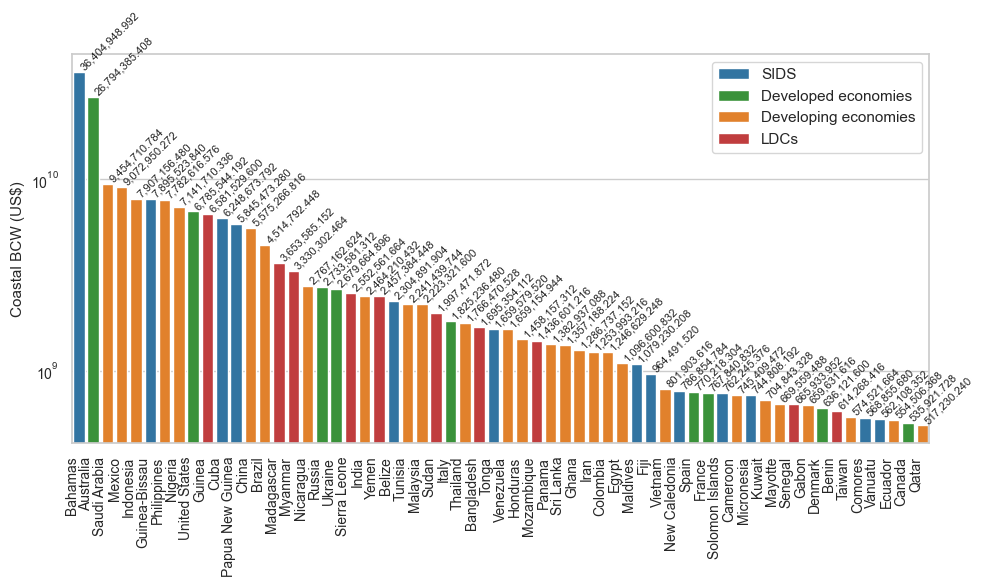

In [134]:
by_country = df[['country_name', 'cBCW', 'Groups']]
by_country = by_country.dropna(subset='Groups')
by_country = by_country.sort_values(by='cBCW', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style='whitegrid')
sns.barplot(by_country.head(60), y='cBCW', x='country_name', palette= color_mapping,
 hue='Groups',ax=ax)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width() / 2, height + 0.05, f'{height/1e3:,.3f}',
                ha='left', va='bottom', rotation=45, fontsize=8)

plt.ylabel('Coastal BCW (US$)', fontsize=11)
plt.xlabel('', fontsize=14)
plt.xticks(rotation=90, ha='right')
ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend()
plt.show()

### Total BCW Country-Level

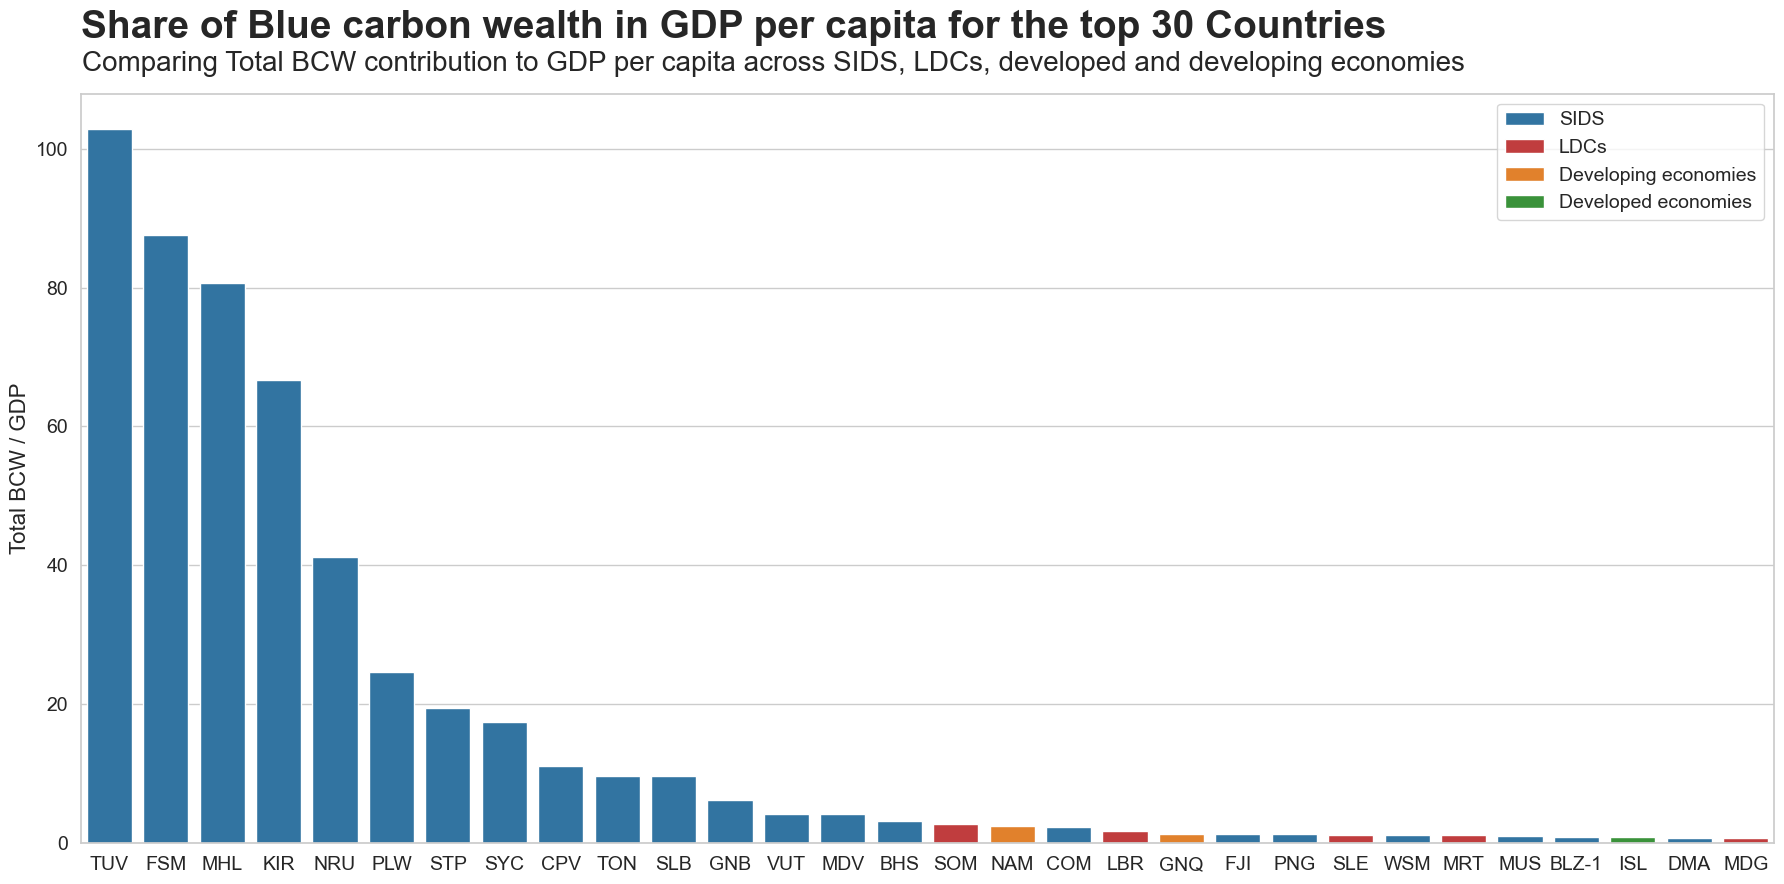

In [135]:
# 1. Total BCW per capita / GDP per capita
df['Total BCW_GDP_per_capita_ratio'] = df['Total BCW_per_capita'] / df['GDP_per_capita']
df['Total BCW_GDP_per_capita_ratio'] = df['Total BCW_GDP_per_capita_ratio'].replace([np.inf, -np.inf], np.nan)

by_bg = df[['ISO', 'Groups', 'Total BCW_GDP_per_capita_ratio']].sort_values(by='Total BCW_GDP_per_capita_ratio', ascending=False)
fig, ax = plt.subplots(figsize=(18, 9))
sns.barplot(data=by_bg.head(30), x='ISO', y='Total BCW_GDP_per_capita_ratio', palette=color_mapping, hue='Groups', ax=ax)
plt.title('Share of Blue carbon wealth in GDP per capita for the top 30 Countries', 
         fontsize=28, fontweight='bold', loc='left', pad=40)
fig.text(0.05, 0.935, 'Comparing Total BCW contribution to GDP per capita across SIDS, LDCs, developed and developing economies', 
         fontsize=20, va='top', ha='left')
plt.ylabel('Total BCW / GDP', fontsize=16)
plt.xlabel('')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.legend(fontsize=14)
plt.show()

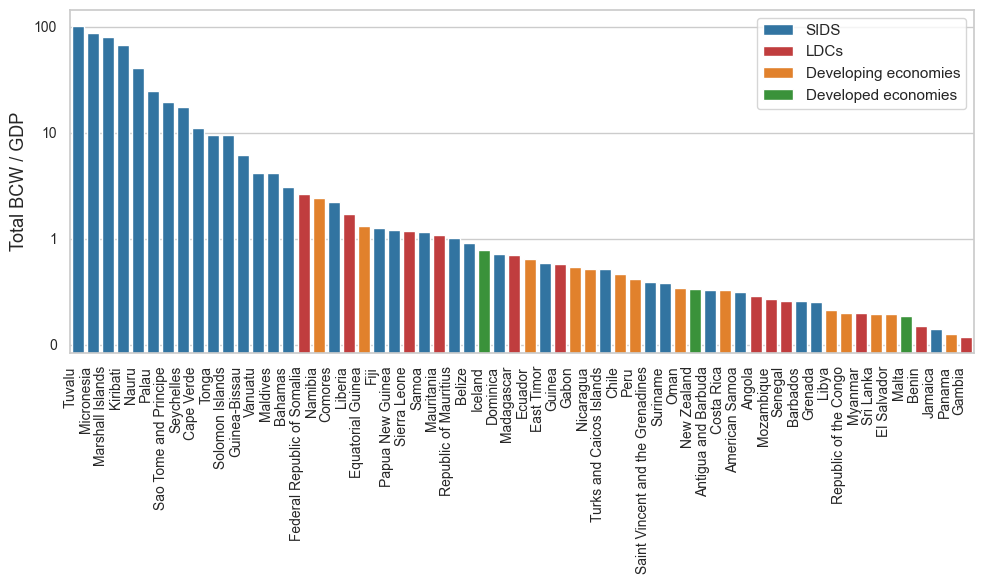

In [136]:
# 1. Total BCW per capita / GDP per capita
df['Total BCW_GDP_per_capita_ratio'] = df['Total BCW_per_capita'] / df['GDP_per_capita']
df['Total BCW_GDP_per_capita_ratio'] = df['Total BCW_GDP_per_capita_ratio'].replace([np.inf, -np.inf], np.nan)

by_bg = df[['country_name', 'Groups', 'Total BCW_GDP_per_capita_ratio']].sort_values(by='Total BCW_GDP_per_capita_ratio', ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=by_bg.head(60), x='country_name', y='Total BCW_GDP_per_capita_ratio', palette=color_mapping, hue='Groups', ax=ax)
plt.ylabel('Total BCW / GDP', fontsize=13)
plt.yscale("log")
format_log_axis_plain('y')
plt.xlabel('')
plt.xticks(rotation=90, ha='right')
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend(fontsize=11)
plt.show()

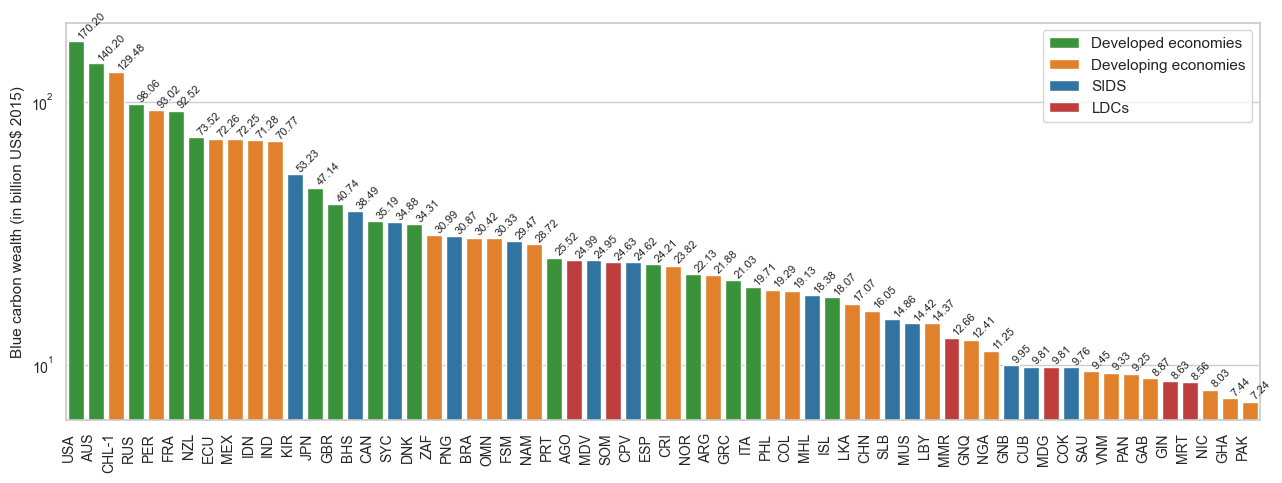

In [137]:
# supl22
# 2. Total BCW absolute value by country
by_countryx = df[['ISO', 'Total BCW', 'cBCW', 'Groups']].dropna(subset=['Groups']).sort_values(by='Total BCW', ascending=False)
by_countryx['Total BCW'] = by_countryx['Total BCW'] / 1e9
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=by_countryx.head(60), y='Total BCW', x='ISO', palette=color_mapping, hue='Groups', ax=ax)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height + 0.05, f'{height:,.2f}',
                ha='left', va='bottom', rotation=45, fontsize=8)
plt.ylabel('Blue carbon wealth (in billion US$ 2015)', fontsize=11)
plt.xlabel('')
plt.xticks(rotation=90, ha='right', fontsize=14)
ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend()
plt.show()

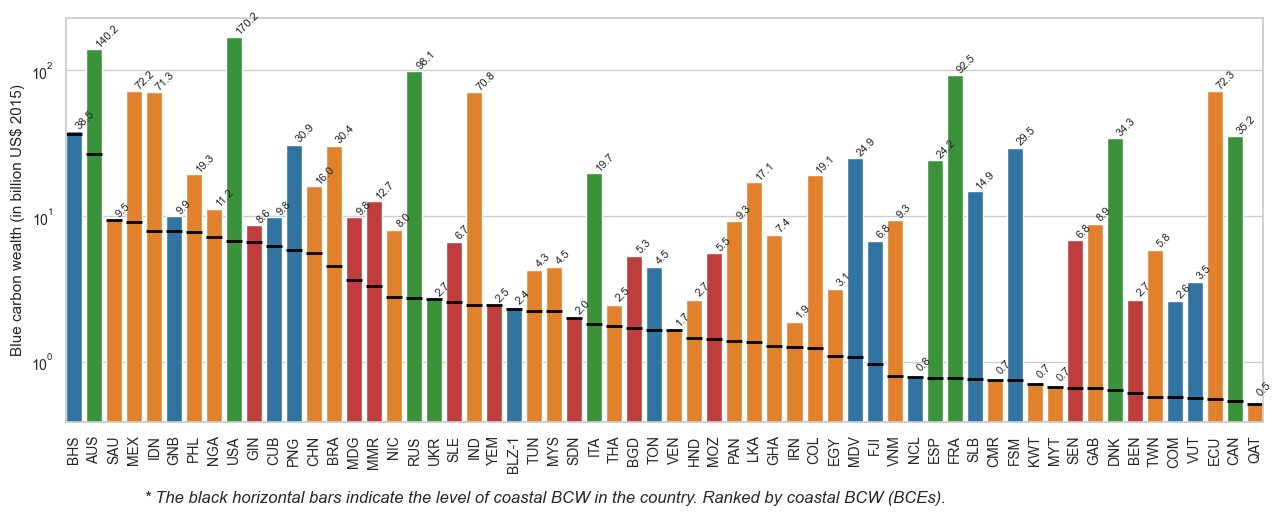

In [138]:
# supl22
# 2. Total BCW absolute value by country
by_country = df[['ISO', 'Total BCW', 'cBCW', 'Groups']].dropna(subset=['Groups']).sort_values(by='cBCW', ascending=False)
by_country['Total BCW'] = by_country['Total BCW']/1e9
by_country['cBCW'] = by_country['cBCW']/1e9
top = by_country.head(60)

fig, ax = plt.subplots(figsize=(13, 5))

# 1) Barres Total BCW
sns.barplot(
    data=top,
    y='Total BCW', x='ISO',
    palette=color_mapping, hue='Groups', ax=ax
)
ax.margins(x=0)

for i, row in by_country.head(60).reset_index().iterrows():
    bcw = 0 if pd.isna(row['cBCW']) else row['cBCW']
    ax.hlines(
        y=bcw,
        xmin=i - 0.4, xmax=i + 0.4,
        colors="black", linewidth=2
    )
 
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height + 0.05, f'{height:,.1f}',
                ha='left', va='bottom', rotation=45, fontsize=8)
plt.ylabel('Blue carbon wealth (in billion US$ 2015)', fontsize=11)
plt.xlabel('')
plt.xticks(rotation=90, ha='center', fontsize=14)
ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend().remove()
plt.figtext(
    0.425, 0, 
    "* The black horizontal bars indicate the level of coastal BCW in the country. Ranked by coastal BCW (BCEs).",
    ha="center", va="top", fontsize=12, style="italic"
)
plt.show()

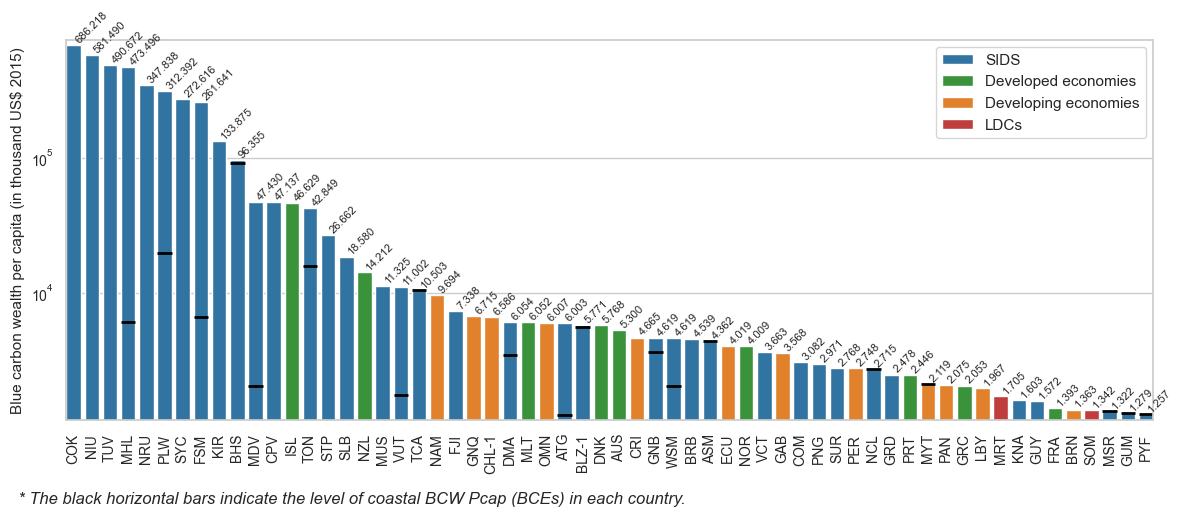

In [139]:
# supl22
# Total BCW_per_capita absolute value by country
by_country = df[['ISO', 'Total BCW_per_capita', 'cBCW_per_capita', 'Groups']].dropna(subset=['Groups']).sort_values(by='Total BCW_per_capita', ascending=False)
top = by_country.head(60)

fig, ax = plt.subplots(figsize=(12, 5))

# Bars for Total BCW_per_capita
sns.barplot(
    data=top,
    y='Total BCW_per_capita', x='ISO',
    palette=color_mapping, hue='Groups', ax=ax
)
ax.margins(x=0)

ymin = top['Total BCW_per_capita'].replace(0, np.nan).min()          
ymax = top['Total BCW_per_capita'].max()
ax.set_yscale('log')
ax.set_ylim(ymin*0.9, ymax*1.1)                     
ax.autoscale(enable=False, axis='y')                 

for i, row in by_country.head(60).reset_index().iterrows():
    bcw = 0 if pd.isna(row['cBCW_per_capita']) else row['cBCW_per_capita']
    ax.hlines(
        y=bcw,
        xmin=i - 0.4, xmax=i + 0.4,   
        colors="black", linewidth=2
    )
 
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height + 0.05, f'{height/1e3:,.3f}',
                ha='left', va='bottom', rotation=45, fontsize=8)
plt.ylabel('Blue carbon wealth per capita (in thousand US$ 2015)', fontsize=11)
plt.xlabel('')
plt.xticks(rotation=90, ha='center')
# ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend()
plt.figtext(
    0.3, 0, 
    "* The black horizontal bars indicate the level of coastal BCW Pcap (BCEs) in each country.",
    ha="center", va="top", fontsize=12, style="italic"
)
plt.show()

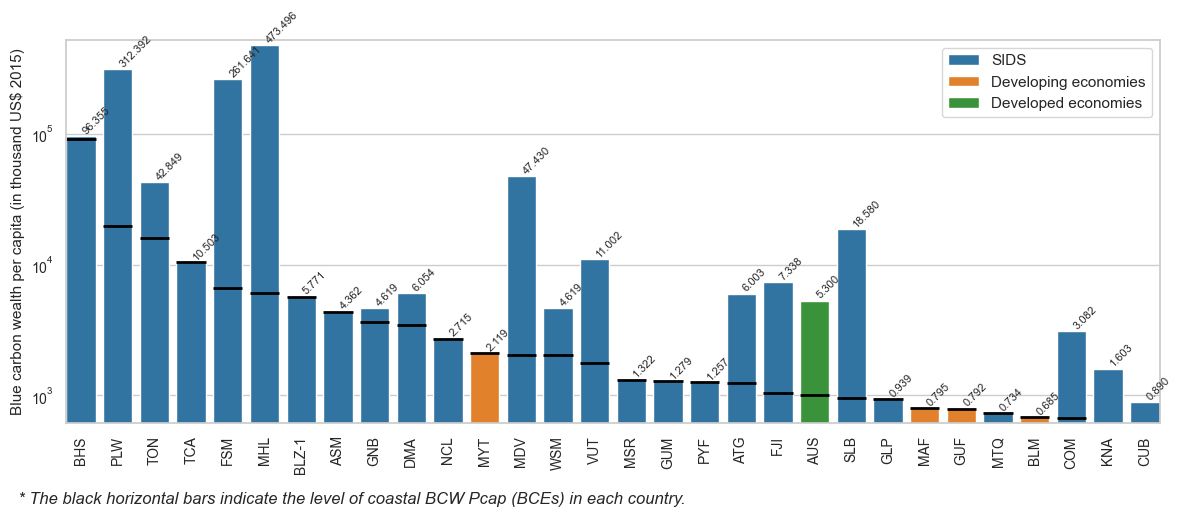

In [140]:
by_country = df[['ISO', 'Total BCW_per_capita', 'cBCW_per_capita', 'Groups']].dropna(subset=['Groups']).sort_values(by='cBCW_per_capita', ascending=False)
top = by_country.head(30)

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=top,
    y='Total BCW_per_capita', x='ISO',
    palette=color_mapping, hue='Groups', ax=ax
)
ax.margins(x=0)
ymin = top['Total BCW_per_capita'].replace(0, np.nan).min()          
ymax = top['Total BCW_per_capita'].max()
ax.set_yscale('log')
ax.set_ylim(ymin*0.9, ymax*1.1)                    
ax.autoscale(enable=False, axis='y')                

for i, row in by_country.head(30).reset_index().iterrows():
    bcw = 0 if pd.isna(row['cBCW_per_capita']) else row['cBCW_per_capita']
    ax.hlines(
        y=bcw,
        xmin=i - 0.4, xmax=i + 0.4,   
        colors="black", linewidth=2
    )
 
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height + 0.05, f'{height/1e3:,.3f}',
                ha='left', va='bottom', rotation=45, fontsize=8)
plt.ylabel('Blue carbon wealth per capita (in thousand US$ 2015)', fontsize=11)
plt.xlabel('')
plt.xticks(rotation=90, ha='center')
# ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend()
plt.figtext(
    0.3, 0, 
    "* The black horizontal bars indicate the level of coastal BCW Pcap (BCEs) in each country.",
    ha="center", va="top", fontsize=12, style="italic"
)
plt.show()

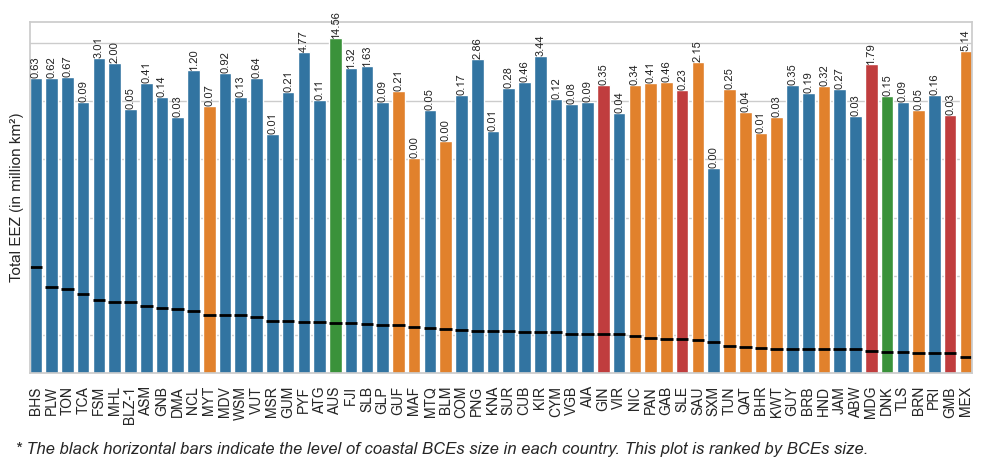

In [141]:
# supl4
by_eez = df.copy()
by_eez['EEZ'] = by_eez['Area_EEZ_KM2']
by_eez['BCEs_size'] = by_eez[['mangroves_area_km2', 'saltmarshes_area_km2', 'seagrasses_area_km2']].sum(axis=1)
by_eez['BCEs_size'] = by_eez['BCEs_size'] / by_eez['Population']
by_eez = by_eez[['ISO', 'Groups', 'EEZ', 'BCEs_size'
             ]].dropna(subset=['Groups']).sort_values(by='BCEs_size', ascending=False)
top = by_eez.head(60)

fig, ax = plt.subplots(figsize=(10, 4.5))

sns.barplot(
    data=top,
    y='EEZ', x='ISO',
    palette=color_mapping, hue='Groups', ax=ax
)
ax.margins(x=0)

for i, row in by_eez.head(60).reset_index().iterrows():
    bcw = 0 if pd.isna(row['BCEs_size']) else row['BCEs_size']
    ax.hlines(
        y=bcw,
        xmin=i - 0.4, xmax=i + 0.4,  
        colors="black", linewidth=2
    )
 
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height + 0.1, f'{height/1e6:,.2f}',
                ha='center', va='bottom', rotation=90, fontsize=8)
plt.ylabel('Total EEZ (in million km²)', fontsize=11)
plt.xlabel('')
# remove y tick labels
ax.set_yticklabels([], visible=False)
plt.xticks(rotation=90, ha='center')
ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend().remove()
plt.figtext(
    0.45, 0, 
    "* The black horizontal bars indicate the level of coastal BCEs size in each country. This plot is ranked by BCEs size.",
    ha="center", va="top", fontsize=12, style="italic"
)
plt.show()

In [142]:
print('end !')

end !
